In [1]:
import numpy as np
#this just changes things from mathematica form to python
from sympy.parsing.mathematica import mathematica  
from sympy import var
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from scipy import integrate
from numba import jit
import scipy

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
plt.rc('font', size=18) 

from scipy.interpolate import interp1d
from scipy.integrate import odeint

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', family='serif')
plt.rc('font', size='22')
#plt.rcParams['figure.dpi'] = 150
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1.5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1.5

In [3]:
from classy import Class

#Start by specifying the cosmology  - planck best fit
h = 0.6766
Omega_b = 0.02242/h**2
Omega_cdm = 0.11933/h**2
Omega_m = Omega_cdm+Omega_b
A_s = 2.105e-9 
n_s = 0.9665

#Create a params dictionary
#Need to specify the max wavenumber
k_max = 10 #UNITS: 1/Mpc # is also set to 10 later
params = {'output':'mPk,mTk',
             'non linear':'halofit',
             'Omega_b':Omega_b,
             'Omega_cdm':Omega_cdm,#Omega_m-Omega_b,#
             'h':h,
             'n_s':n_s,
             'A_s':A_s,#'n_s':n_s,'sigma8':0.828,#
             'P_k_max_1/Mpc':k_max,
             'z_max_pk':10. #Default value is 10
}

#Initialize the cosmology and compute everything
cosmo = Class()
cosmo.set(params)
cosmo.compute()

In [4]:
#eline de weerd
h = 0.6766#0.695#0.676611#0.7 #H0/100
Omega_m = 0.3111
Omega_cdm = 0.11933/h**2
Omega_b = 0.02242/h**2#0.157*Omega_m
A_s = 2.20193e-9 
n_s = 0.9665#0.9632#
#a = 1/(1+z)
#H  = 100.0*np.sqrt(Omega_m*(1.0+z)**3+Omega_l)*a #Value of H(z) in km/s/(Mpc/h)

#Create a params dictionary
#Need to specify the max wavenumber
k_max = 10 #UNITS: 1/Mpc # is also set to 10 later
params = {'output':'mPk,mTk',
             'non linear':'halofit',
             'Omega_b':Omega_b,
             'Omega_cdm':Omega_m-Omega_b,#Omega_cdm,#
             'h':h,
             'n_s':n_s,
             'A_s':A_s,#'n_s':n_s,'sigma8':0.828,#
             'P_k_max_1/Mpc':k_max,
             'z_max_pk':10. #Default value is 10
}

#Initialize the cosmology and compute everything
cosmo_eline = Class()
cosmo_eline.set(params)
cosmo_eline.compute()

In [5]:
def get_avg_dist(obs_pos):
    """create x_c to integrate over - lets say it's a 1000 MPc/h (128x128x128) grid situated at (x,y,z)"""
    Nside_theory= 128
    conf_space = np.linspace(0,1000,Nside_theory)
    x_unorm , y_unorm , z_unorm = np.meshgrid(conf_space-obs_pos[0], conf_space-obs_pos[1], conf_space-obs_pos[2],indexing='ij') 
    conf_norm = np.sqrt(x_unorm**2 + y_unorm**2 + z_unorm**2) # make a unit vector - normalise
    ds = np.where(conf_norm==0,1,conf_norm)
    return 1/np.mean(1/ds**3)

print(get_avg_dist((500,500,200))**(1/3))

255.01426105201142


## define all derivatives wrt to comoving distance

$\frac{df}{d ln(d)}=\frac{d d}{d ln(d)}\frac{dz}{dd}\frac{df}{dz}=d \times(1/\frac{dd}{dz})\frac{df}{dz}$

In [6]:
cosmo.get_current_derived_parameters(['n_s'])['n_s']

0.9665

In [7]:
class CosmologicalFunctions:
    def __init__(self,cosmo,survey='EUCLID'):
        """
            take in Class and spit out stuff and create all my functions
        """
        self.cosmo = cosmo
        baLCDM = cosmo.get_background()
        #print(baLCDM.keys())
        f_cl = baLCDM['gr.fac. f']
        D_cl = baLCDM['gr.fac. D']
        z_cl = baLCDM['z']
        H_cl = baLCDM['H [1/Mpc]']
        xi_cl = baLCDM['comov. dist.']
        t_cl = baLCDM['conf. time [Mpc]']
        
        self.z_cl = z_cl#save for later
        self.Om_0 = cosmo.get_current_derived_parameters(['Omega_m'])['Omega_m']
        self.h = cosmo.get_current_derived_parameters(['h'])['h']
        
        #define functions and add in h
        self.H_c = interp1d(z_cl,H_cl*(1/(1+z_cl))/self.h,kind='cubic') # now in h/Mpc!
        self.dH_c = interp1d(z_cl,np.gradient(H_cl*(1/(1+z_cl))/self.h,z_cl),kind='cubic') # derivative wrt z
        self.ddH_c = interp1d(z_cl,np.gradient(self.dH_c(z_cl),z_cl),kind='cubic') # second derivative wrt z
        self.comoving_dist = interp1d(z_cl,xi_cl*self.h,kind='cubic') # just use class background as quick
        self.f_intp = interp1d(z_cl,f_cl,kind='cubic')#get f #omega_mz = Omega_m *(1+zt)**3 /(Omega_m *(1+zt)**3 + Omega_l)
        self.D_intp = interp1d(z_cl,D_cl,kind='cubic')
        self.dD_dz = interp1d(z_cl,np.gradient(D_cl,z_cl),kind='cubic')
        self.conf_time = interp1d(z_cl,self.h*t_cl,kind='cubic')#convert between the two
        #misc
        self.c = 2.99792*10**5 #km/s
        self.H0 = 100/self.c #[h/Mpc]
        self.Om = lambda xx: self.Om_0 * (self.H0**2 / self.H_c(xx)**2) * (1+xx)
        
        #define bias stuff
        """
        if False:
            self.b_1 = lambda xx: 1.46 +0*xx
        else:
            self.b_1 = lambda xx: np.sqrt(1+xx)"""
            
        if survey=='EUCLID':
            self.b_1  =  lambda xx: 0.9 + 0.4*xx
        elif survey=='DESI':
            self.b_1 =  lambda xx: 1.34/self.D_intp(xx)
            
        self.g_2 = lambda xx: -(2/7)*(self.b_1(xx)-1)# 0.524-0.547*self.b_1(xx)+0.046*self.b_1(xx)**2#
        self.b_2 = lambda xx: 0.412 - 2.143*self.b_1(xx) +0.929*self.b_1(xx)**2 + 0.008*self.b_1(xx)**3 + 4/3 * self.g_2(xx)#-0.1*np.sqrt(1+xx)#
        
        self.z_samps = np.linspace(0.05, 10, 10000)#defined over appropiate range for numerical derivs
        
        #get derivs of these redshift dependent functions
        func_deriv_list = self.lnd_derivatives([self.b_1,self.b_2,self.g_2,self.f_intp,self.D_intp])
        self.b1_d,self.b2_d,self.g2_d,self.f_d,self.D_d = func_deriv_list
        func_second_deriv_list = self.lnd_derivatives(func_deriv_list)
        self.b1_dd,self.b2_dd,self.g2_dd,self.f_dd,self.D_dd = func_second_deriv_list
        
        if survey=='EUCLID':
            self.z_survey = np.linspace(0.8,1.9) 
            self.be_euclid= lambda xx: -7.29 + 0.470*xx + 1.17*xx**2 - 0.290*xx**3
            self.Q_euclid = lambda xx:0.583 + 2.02*xx - 0.568*xx**2 + 0.0411*xx**3
        elif survey=='DESI':
            self.z_survey = np.linspace(0.05,0.6) 
            self.be_euclid= lambda xx: -2.25 - 4.02*xx + 0.318*xx**2 - 14.6*xx**3
            self.Q_euclid = lambda xx: 0.282 + 2.36*xx + 2.27*xx**2 + 11.1*xx**3
        else:
            self.z_survey = np.linspace(0.8,1.9) 
            self.be_euclid = lambda xx: 0*xx
            self.Q_euclid = lambda xx:  0*xx + 2/5
            
        if True: # for comparison with eline - euclid like
            euclid_data = np.loadtxt('snr_surveyparams.txt')
            z_euclid = euclid_data[:,0]
            self.be_euclid = interp1d(z_euclid, euclid_data[:,1])
            self.Q_euclid = interp1d(z_euclid,  euclid_data[:,2])
            self.b_1 = lambda xx: 0.9 + 0.4*xx
            self.b_2 = lambda xx: -0.741-0.125*xx+0.123*xx**2+0.00637*xx**3
            self.g_2 = lambda xx: (0.0409-0.199*xx-0.0166* xx**2 +0.00268* xx**3)/2
            
        if False: # clarkson 2019
            self.b_1 = lambda xx: 1.3 +0*xx
            self.b_2 = lambda xx: -0.74 +0*xx
            self.g_2 = lambda xx: 0.524-0.547*self.b_1(xx)+0.046*self.b_1(xx)**2#-(2/7)*(self.b_1(xx)-1)#
            self.z_euclid = self.z_samps
            self.be_euclid = lambda xx: -4 +0*xx
            self.Q_euclid = lambda xx:  0*xx - 2.5# 0.95#/5
        
    def get_class_powerspectrum(self,kk,zz): #h are needed to convert to 1/Mpc for k then convert pk back to (Mpc/h)^3
        return np.array([self.cosmo.pk_lin(ki, zz) for ki in kk*self.h])*h**3

    def get_pkinfo_z(self,k,z):
        Plin = self.get_class_powerspectrum(k,0)#just always get present day power spectrum
        Pk = interp1d(k,Plin)#get linear power spectrum
        self.Pk = Pk
        Pk_d = interp1d(k,np.gradient(Plin,k))
        Pk_dd = interp1d(k,np.gradient(Pk_d(k),k))
        return Pk,Pk_d,Pk_dd
    
    def Pk_phi(self,k,cosmo=cosmo, k0=0.05, units=True):
        """Power spectrum of the Bardeen potential Phi in the matter-dominated era - k in units of h/Mpc.
        """
        k_pivot = k0/h
        resp = (9.0/25.0) * cosmo.get_current_derived_parameters(['A_s'])['A_s'] * (k/k_pivot)**(cosmo.get_current_derived_parameters(['n_s'])['n_s'] - 1.0)

        if units:
            resp *= 2*np.pi**2.0/k**3.0    #[Mpc/h]^3

        return resp

    def M(self,k, z):
        """The scaling factor between the primordial scalar power spectrum and the late-time matter power spectrum
        """
        return np.sqrt(self.D_intp(z)**2 *self.Pk(k) / self.Pk_phi(k) )

    def solve_second_order_KC(self):
        c = 2.99792*10**5 #km/s
        def F_func(u,zz): # so variables are F and H and D
            f,fd = u # unpack u vector
            D_zz = self.D_intp(zz)
            return [fd,(-self.H_c(zz)*self.dH_c(zz)*(1+zz)**2 *fd + ((3*(self.H0)**2 * self.Om_0 *(1+zz))/(2))*(f+D_zz**2))/(self.H_c(zz)**2 *(1+zz)**2)]
        
        odeint_zz = np.linspace(20,0.05,int(1e+5))# so z=20 should be pretty much matter dominated

        #set initial params for F
        F0 = [(3/7)*self.D_intp(odeint_zz[0])**2,(3/7)*2*self.D_intp(odeint_zz[0])*self.dD_dz(odeint_zz[0])]
        sol1 = odeint(F_func,F0,odeint_zz)
        K = (sol1[:,0]/self.D_intp(odeint_zz)**2)
        C = sol1[:,1]/(2*self.D_intp(odeint_zz)*self.dD_dz(odeint_zz))
        self.K_intp = interp1d(odeint_zz,K,kind='cubic')
        self.C_intp = interp1d(odeint_zz,C,kind='cubic')
    
    def lnd_derivatives(self,functions_to_differentiate,z_range= [0]):
        """
            calculates derivatives of a list of functions wrt log comoving dist numerically
        """
        if len(z_range) == 1:
            z_range= self.z_samps

        # Store first derivatives in a list
        function_derivatives = []

        for func in functions_to_differentiate:
            # Calculate numerical derivatives of the function with respect to ln(d)
            derivative_func = interp1d(z_range, np.gradient(func(z_range), np.log(self.comoving_dist(z_range))))
            function_derivatives.append(derivative_func)

        return function_derivatives
    
    def get_params(self,k1,k2,theta,zz):
        """
            return arrays of redshift and k dependent parameters
        """
        self.solve_second_order_KC()#get K and C
        
        k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))#get k3 from triangle condition
        k3 = np.where(k3==0,1e-3,k3)
        
        k = np.logspace(-5, np.log10(k_max), num=1000)
        Pk,Pk_d,Pk_dd = self.get_pkinfo_z(k,0)
        Pk1 = Pk(k1)
        Pk2 = Pk(k2)
        Pk3 = Pk(k3)

        Pkd1 = Pk_d(k1)
        Pkd2 = Pk_d(k2)
        Pkd3 = Pk_d(k3)

        Pkdd1= Pk_dd(k1)
        Pkdd2 = Pk_dd(k2)
        Pkdd3 = Pk_dd(k3)

        #redshift dependendent terms
        d = self.comoving_dist(zz)
        
        K = 3/7
        C = 3/7
        if True:
            K = self.K_intp(zz)
            C = self.C_intp(zz)

        f = self.f_intp(zz)
        D1 = self.D_intp(zz)
        b1 = self.b_1(zz)
        b2 = self.b_2(zz)
        g2 = self.g_2(zz)
        return k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2

    def get_derivs(self,zz):
        #1st deriv
        fd = self.f_d(zz)
        Dd = self.D_d(zz)
        gd2 = self.g2_d(zz)
        bd2 = self.b2_d(zz)
        bd1 = self.b1_d(zz)
        #2nd deriv
        fdd = self.f_dd(zz)
        Ddd = self.D_dd(zz)
        gdd2 = self.g2_dd(zz)
        bdd2 = self.b2_dd(zz)
        bdd1 = self.b1_dd(zz)
        return fd,Dd,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1
    
    def get_PNGparams(self,fNL,zz,k1,k2,k3):
        delta_c = 1.686
        bL10 = lambda xx: self.b_1(xx) - 1
        bL20 = lambda xx: self.b_2(xx) - (8/21)*bL10(xx)

        bL01 = lambda xx: 2*delta_c*fNL*bL10(xx)
        bL11 = lambda xx: 2*fNL*(delta_c*bL20(xx)-bL10(xx))
        bL02 = lambda xx: 4*fNL**2 * delta_c*(delta_c*bL20(xx)-2*bL10(xx))

        bE01 = bL01
        bE11 = lambda xx: bL01(xx) + bL11(xx)
        bE02 = bL02

        alphak1 = self.M(k1, 0)
        alphak2 = self.M(k2, 0)
        alphak3 = self.M(k3, 0)
        return fNL,1*bE01(zz),1*bE11(zz),1*bE02(zz),alphak1,alphak2,alphak3
    
    def get_beta_funcs(self,zz):
        """
            Function that relies on biases and functions defined above to return beta coefficients
            from paper 1711.01812v4
        """
        #these derivs here are wrt to conformal time so we convert to derivs wrt to z
        #d/dt = d a/dt d/da = a H dz/da d/dz =  -(1+z) H d/dz # everything here is conformal both t and H
        #d^2/d^2 t = (1+z)^2 H^2 d^2/d z^2 + H(1+z)(H+(1+z)H')d/dz
        
        dQ_euclid_dz = interp1d(self.z_survey,np.gradient(self.Q_euclid(self.z_survey),self.z_survey))
        dbe_dz = interp1d(self.z_survey,np.gradient(self.be_euclid(self.z_survey),self.z_survey))
        db1_dz = interp1d(self.z_samps,np.gradient(self.b_1(self.z_samps),self.z_samps))
        
        dH_dt = lambda xx: -(1+xx)*self.H_c(xx)*self.dH_c(xx)
        dH_dt2 = lambda xx: (1+xx)**2 *self.H_c(xx)**2 *self.ddH_c(xx)+self.H_c(xx)*(1+xx)*(self.H_c(xx)+(1+xx)*self.dH_c(xx))*self.dH_c(xx)#should just check with doing it numerically as is easier
        #self.dH22 = interp1d(self.z_cl,np.gradient(dH_dt(self.z_cl),self.conf_time(self.z_cl)))
        self.dH_dt = dH_dt                   
        dQ_dt = lambda xx: -(1+xx)*self.H_c(xx)*dQ_euclid_dz(xx)
        dbe_dt = lambda xx: -(1+xx)*self.H_c(xx)*dbe_dz(xx)#0*xx-1.6*1e-4
        db1_dt = lambda xx: -(1+xx)*self.H_c(xx)*db1_dz(xx)
        self.Q = self.Q_euclid
        self.b_e = self.be_euclid

        partdQ=0
        partdb1=0
        
        #from 1st order petrubation theory
        self.gr1 = lambda xx: self.H_c(xx)*self.f_intp(xx)*(self.b_e(xx)-2*self.Q(xx)-2*(1-self.Q(xx))/(self.comoving_dist(xx)*self.H_c(xx))-dH_dt(xx)/self.H_c(xx)**2)
        self.gr2 = lambda xx: self.H_c(xx)**2 *(self.f_intp(xx)*(3-self.b_e(xx))+ (3/2)*self.Om(xx)*(2+self.b_e(xx)-self.f_intp(xx)-4*self.Q(xx)-2*self.Q(xx)-2*(1-self.Q(xx))/(self.comoving_dist(xx)*self.H_c(xx))-dH_dt(xx)/self.H_c(xx)**2))
        self.grd1 = self.lnd_derivatives([self.gr1],self.z_survey)[0]#get derivative for 1st order coef
        
        beta = np.empty(20,dtype=object)
        beta[6] = lambda xx: self.H_c(xx)**2 * ((3 / 2) * self.Om(xx) * (2 - 2 * self.f_intp(xx)+ self.b_e(xx) - 4 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))
        beta[7] = lambda xx: self.H_c(xx)**2 * (self.f_intp(xx)* (3 - self.b_e(xx)))
        beta[8] = lambda xx: self.H_c(xx)**2 * (3 * self.Om(xx) * self.f_intp(xx) * (2 - self.f_intp(xx) - 2 * self.Q(xx)) + self.f_intp(xx)**2 * (4 + self.b_e(xx) - self.b_e(xx)**2 + 4 * self.b_e(xx) * self.Q(xx) - 6 * self.Q(xx) - 4 * self.Q(xx)**2 + 4 * partdQ + 4 * (dQ_dt(xx) / self.H_c(xx)) -(dbe_dt(xx) / self.H_c(xx)) - (2 / (self.comoving_dist(xx)**2 * self.H_c(xx)**2)) * (1 - self.Q(xx) + 2 * self.Q(xx)**2 - 2 * partdQ) - (2 / (self.comoving_dist(xx) * self.H_c(xx))) * (3 - 2 * self.b_e(xx) + 2 * self.b_e(xx) * self.Q(xx) - self.Q(xx) - 4 * self.Q(xx)**2 + ((3 * dH_dt(xx)) / (self.H_c(xx)**2)) * (1 - self.Q(xx)) + 4 * partdQ + 2 * (dQ_dt(xx) / self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2) * (3 - 2 * self.b_e(xx) + 4 * self.Q(xx) + ((3 * dH_dt(xx)) / (self.H_c(xx)**2))) + (dH_dt2(xx) / self.H_c(xx)**3)))
        beta[9] = lambda xx: self.H_c(xx)**2 * ( -(9 / 2) * self.Om(xx) * self.f_intp(xx))
        beta[10] = lambda xx: self.H_c(xx)**2 * (3 * self.Om(xx) * self.f_intp(xx))
        beta[11] = lambda xx: self.H_c(xx)**2 * ( (3/2 ) * self.Om(xx) * (1 + 2 * self.f_intp(xx)/ (3 * self.Om(xx))) + 3 * self.Om(xx) * self.f_intp(xx)- self.f_intp(xx)**2 * (-1 + self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 + self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))
        beta[12] = lambda xx: self.H_c(xx)**2 * ( -3 * self.Om(xx) * (1 + 2 * self.f_intp(xx)/ (3 * self.Om(xx))) - self.f_intp(xx)* ( self.b_1(xx) * (self.f_intp(xx)- 3 + self.b_e(xx)) + (db1_dt(xx) / self.H_c(xx)) ) + (3 / 2) * self.Om(xx) * (self.b_1(xx) * (2 + self.b_e(xx) - 4 * self.Q(xx) - 2 * ((1 - self.Q(xx))/(self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2) ) + db1_dt(xx) /self.H_c(xx) + 2 * (2 - (1 / (self.comoving_dist(xx) * self.H_c(xx))) ) * partdb1 ) )    
        beta[13] = lambda xx: self.H_c(xx)**2 * (( (9 / 4) * self.Om(xx)**2 + (3 / 2) * self.Om(xx) * self.f_intp(xx)* (1 - (2 * self.f_intp(xx)) + 2 * self.b_e(xx) - 6 * self.Q(xx) - ((4 * (1 - self.Q(xx)))/(self.comoving_dist(xx) * self.H_c(xx))) - ((3 * dH_dt(xx)) / self.H_c(xx)**2) ) ) + ( self.f_intp(xx)**2 * (3 - self.b_e(xx)) ) )
        beta[14] = lambda xx: self.H_c(xx) * ( - (3 / 2) * self.Om(xx) * self.b_1(xx))
        beta[15] = lambda xx: self.H_c(xx) * 2 * self.f_intp(xx)**2
        beta[16] = lambda xx: self.H_c(xx) * (self.f_intp(xx)* (self.b_1(xx) * (self.f_intp(xx)+ self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)) + (db1_dt(xx) / self.H_c(xx)) + 2 * (1 - (1 / (self.comoving_dist(xx) * self.H_c(xx)))) * partdb1 ))
        beta[17] = lambda xx: self.H_c(xx) * (- (3 / 2) * self.Om(xx) * self.f_intp(xx))
        beta[18] = lambda xx: self.H_c(xx) * ( (3 / 2) * self.Om(xx) * self.f_intp(xx) - self.f_intp(xx)**2 * (3 - 2 * self.b_e(xx) + 4 * self.Q(xx) + ((4 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) + (3 * dH_dt(xx)/ self.H_c(xx)**2)) )
        beta[19] = lambda xx: self.H_c(xx) * (self.f_intp(xx)* (self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))

        self.beta = beta
        
        #get betad - derivatives wrt to ln(d)        # these are limited in range to euclid currently
        betad = np.empty(20,dtype=object)
        betad[14:20] = np.array(self.lnd_derivatives(beta[14:20],self.z_survey),dtype=object)#14-19

        self.betad = betad
        all_betas = np.concatenate((np.array([self.gr1,self.gr2,self.grd1]),beta[6:],betad[14:20]))
        return [all_betas[i](zz) for i in range(len(all_betas))]


In [8]:
zz=0.8
k1=0.04#np.linspace(0.01,0.1)#
k2=k1/2
theta = 2*np.pi/3#np.pi#np.linspace(0,np.pi,200)#

In [9]:
cosmo_functions = CosmologicalFunctions(cosmo)
params = cosmo_functions.get_params(k1,k2,theta,zz)
k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
derivs = cosmo_functions.get_derivs(zz)

PNGparams = cosmo_functions.get_PNGparams(1,zz,k1,k2,k3)
betas = cosmo_functions.get_beta_funcs(zz)
gr1,gr2,grd1,beta6,beta7,beta8,beta9,beta10,beta11,beta12,beta13,beta14,beta15,beta16,beta17,beta18,beta19,betad14,betad15,betad16,betad17,betad18,betad19 = betas

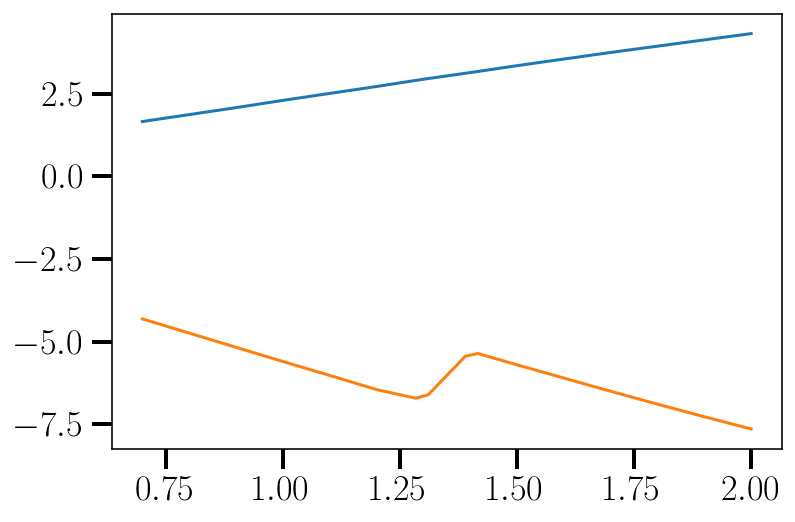

In [10]:
z_plot = np.linspace(0.7,2)
#plt.plot(z_plot,cosmo_functions.b_1(z_plot))
#plt.plot(z_plot,cosmo_functions.b_2(z_plot))
#plt.plot(z_plot,cosmo_functions.g_2(z_plot))
plt.plot(z_plot,cosmo_functions.Q_euclid(z_plot))
plt.plot(z_plot,cosmo_functions.be_euclid(z_plot))

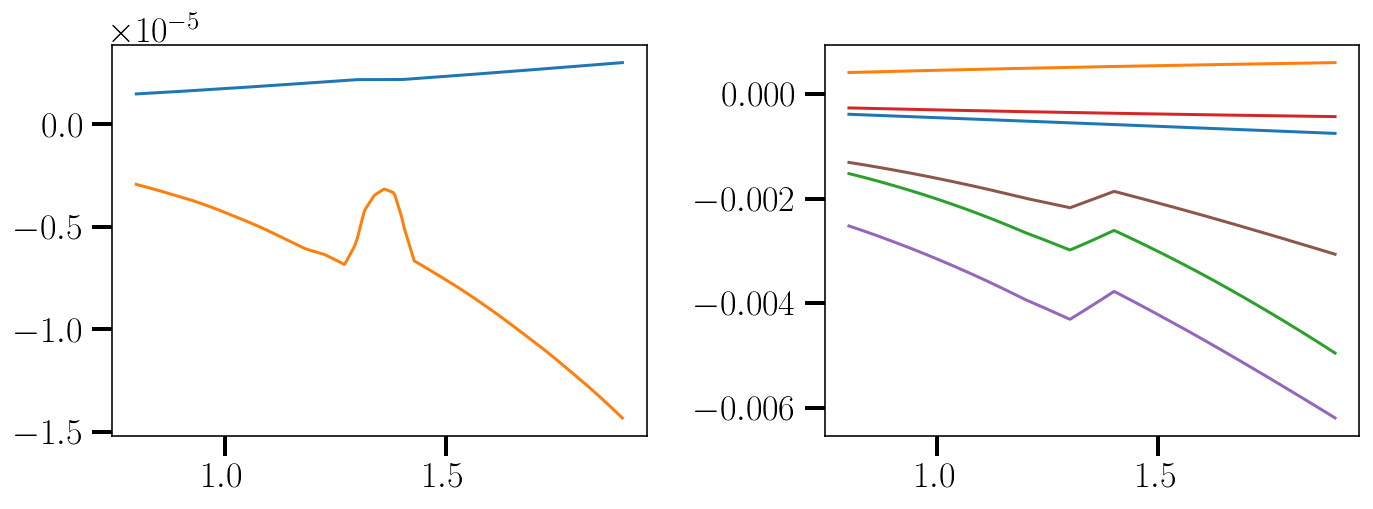

In [11]:
#plt.plot(z_euclid,gr1)
#plt.plot(z_euclid,cosmo_functions.grd1(z_euclid))
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
z_euclid = np.linspace(0.8,1.9,300)
#axs[0].plot(z_euclid,cosmo_functions.beta[13](z_euclid))
#axs[0].plot(z_euclid,cosmo_functions.beta[12](z_euclid))
axs[0].plot(z_euclid,cosmo_functions.beta[11](z_euclid))
#axs[0].plot(z_euclid,cosmo_functions.beta[10](z_euclid))
#axs[0].plot(z_euclid,cosmo_functions.beta[9](z_euclid))
axs[0].plot(z_euclid,cosmo_functions.beta[8](z_euclid))
#axs[0].plot(z_euclid,cosmo_functions.beta[7](z_euclid))
#axs[0].plot(z_euclid,cosmo_functions.beta[6](z_euclid))


axs[1].plot(z_euclid,cosmo_functions.beta[14](z_euclid))
axs[1].plot(z_euclid,cosmo_functions.beta[15](z_euclid))
axs[1].plot(z_euclid,cosmo_functions.beta[16](z_euclid))
axs[1].plot(z_euclid,cosmo_functions.beta[17](z_euclid))
axs[1].plot(z_euclid,cosmo_functions.beta[18](z_euclid))
axs[1].plot(z_euclid,cosmo_functions.beta[19](z_euclid))
#axs[1].plot(z_euclid,cosmo_functions.betad[16](z_euclid))

plt.tight_layout()
plt.show()

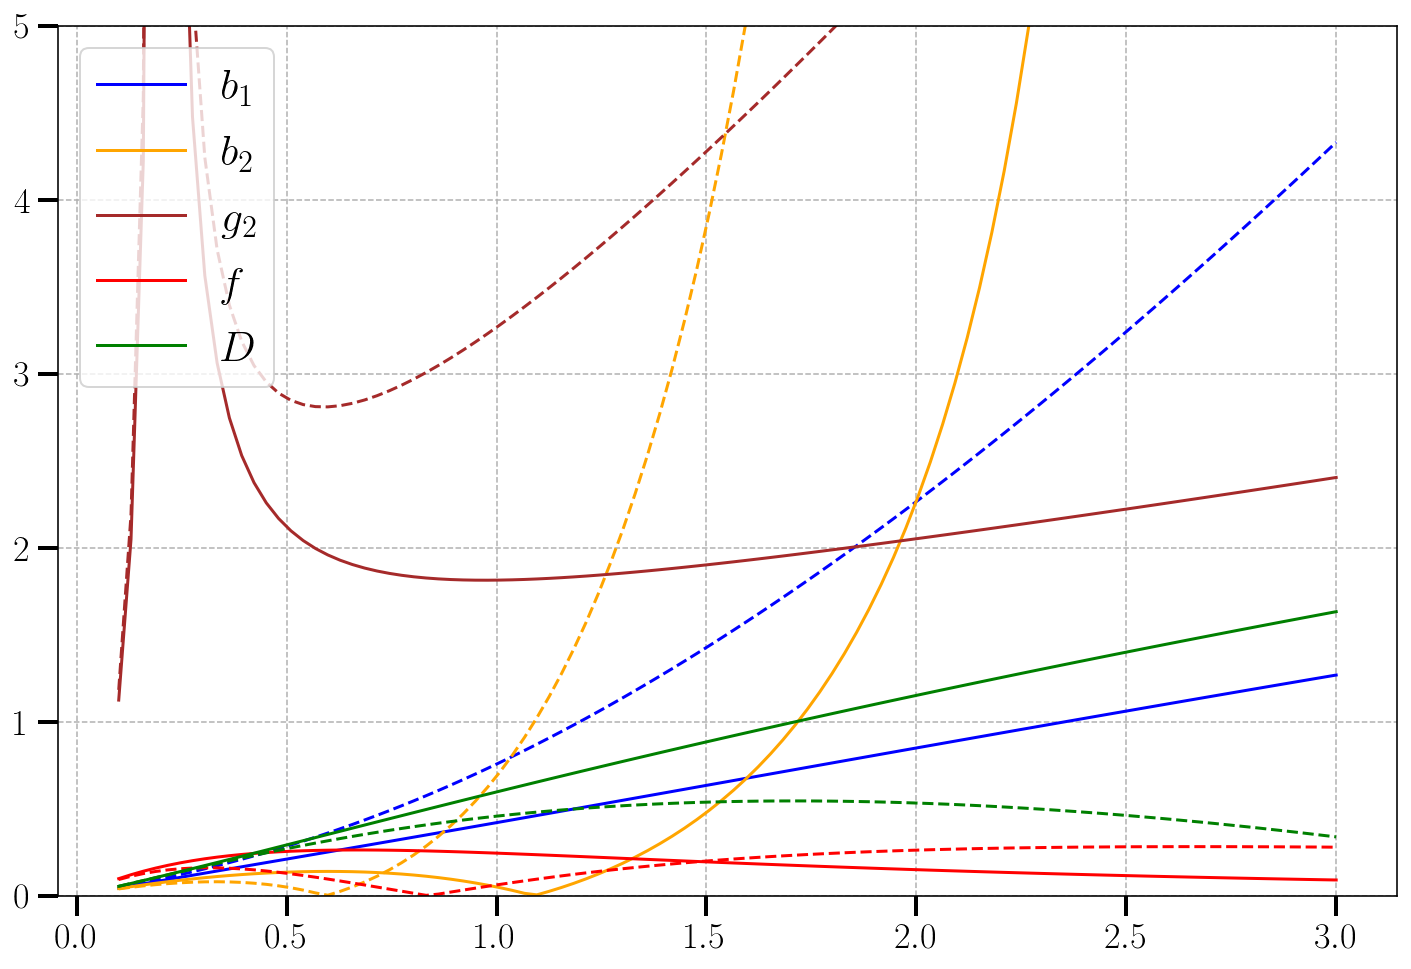

In [12]:
#plot ratio of derivates of biases to normal term which repersents the rough size of derivative terms to wide-angle terms
plt.figure(figsize=(12,8))
z_plot = np.linspace(0.1,3,100)

plt.plot(z_plot,np.abs(cosmo_functions.b1_d(z_plot)/cosmo_functions.b_1(z_plot)),color='blue',label='$b_1$')
plt.plot(z_plot,np.abs(cosmo_functions.b1_dd(z_plot)/cosmo_functions.b_1(z_plot)),'--',color='blue')

plt.plot(z_plot,np.abs(cosmo_functions.b2_d(z_plot)/cosmo_functions.b_2(z_plot)),color='orange',label='$b_2$')
plt.plot(z_plot,np.abs(cosmo_functions.b2_dd(z_plot)/cosmo_functions.b_2(z_plot)),'--',color='orange')

plt.plot(z_plot,np.abs(cosmo_functions.g2_d(z_plot)/cosmo_functions.g_2(z_plot)),color='brown',label='$g_2$')
plt.plot(z_plot,np.abs(cosmo_functions.g2_dd(z_plot)/cosmo_functions.g_2(z_plot)),'--',color='brown')

plt.plot(z_plot,np.abs(cosmo_functions.f_d(z_plot)/cosmo_functions.f_intp(z_plot)),color='red',label='$f$')
plt.plot(z_plot,np.abs(cosmo_functions.f_dd(z_plot)/cosmo_functions.f_intp(z_plot)),'--',color='red')

plt.plot(z_plot,np.abs(cosmo_functions.D_d(z_plot)/cosmo_functions.D_intp(z_plot)),color='green',label='$D$')
plt.plot(z_plot,np.abs(cosmo_functions.D_dd(z_plot)/cosmo_functions.D_intp(z_plot)),'--',color='green')

plt.grid(ls='--',lw=0.75)
plt.ylim(0,5)
plt.legend()

## Import expression for each contributions

In [13]:
import sys
sys.path.append('bk_terms/')
from zeroth_order import *
from first_order import *
from wa2_terms import *
from der2_terms import *
from mix_terms import *
from GR import *   
from GRmix import *   

In [46]:
import json
with open('mathematica_expr/P12GR1l3.json') as f:
    data = json.load(f)
tmpexp = str(mathematica(data)).replace('I*','1j*').replace('-I*','-1j*').replace('sqrt(','np.sqrt(').replace('pi','np.pi')
print(tmpexp)

1j*D1**4*Pk1*Pk2*(594*C*b1*beta19*f*k1**3*k2**2*cos(4*theta) - 1386*C*b1*beta19*f*k1**3*k2**2 + 99*C*b1*beta19*f*k1**2*k2**3*cos(3*theta) + 495*C*b1*beta19*f*k1**2*k2**3*cos(5*theta) - 792*C*b1*f*gr1*k1**4*k2*cos(3*theta) - 1188*C*b1*f*gr1*k1**3*k2**2*cos(4*theta) + 1188*C*b1*f*gr1*k1**3*k2**2 - 891*C*b1*f*gr1*k1**2*k2**3*cos(3*theta) - 495*C*b1*f*gr1*k1**2*k2**3*cos(5*theta) - 594*C*b1*f*gr1*k1*k2**4*cos(4*theta) - 198*C*b1*f*gr1*k1*k2**4 + 462*C*beta19*f**2*k1**3*k2**2*cos(4*theta) - 374*C*beta19*f**2*k1**3*k2**2 + 121*C*beta19*f**2*k1**2*k2**3*cos(3*theta) + 253*C*beta19*f**2*k1**2*k2**3*cos(5*theta) - 880*C*f**2*gr1*k1**4*k2*cos(3*theta) - 1386*C*f**2*gr1*k1**3*k2**2*cos(4*theta) + 1122*C*f**2*gr1*k1**3*k2**2 - 363*C*f**2*gr1*k1**2*k2**3*cos(3*theta) - 759*C*f**2*gr1*k1**2*k2**3*cos(5*theta) - 352*C*f**2*gr1*k1*k2**4*cos(4*theta) - 110*C*f**2*gr1*k1*k2**4*cos(6*theta) - 176*C*f**2*gr1*k1*k2**4 - 396*K*b1*f*gr1*k1**2*k2*k3**2*cos(3*theta) - 297*K*b1*f*gr1*k1*k2**2*k3**2*cos(4*theta)

In [148]:
with open("tmp.txt", "w") as file:
    file.write(str(tmpexp))

In [47]:
class GR1_test:
    def l3(params,betas):
        k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
        gr1,gr2,grd1,beta6,beta7,beta8,beta9,beta10,beta11,beta12,beta13,beta14,beta15,beta16,beta17,beta18,beta19,betad14,betad15,betad16,betad17,betad18,betad19 = betas

        cos = lambda x: np.cos(x)
        sin = lambda x: np.sin(x)

        perm12 = 1j*D1**4*Pk1*Pk2*(594*C*b1*beta19*f*k1**3*k2**2*cos(4*theta) - 1386*C*b1*beta19*f*k1**3*k2**2 + 99*C*b1*beta19*f*k1**2*k2**3*cos(3*theta) + 495*C*b1*beta19*f*k1**2*k2**3*cos(5*theta) - 792*C*b1*f*gr1*k1**4*k2*cos(3*theta) - 1188*C*b1*f*gr1*k1**3*k2**2*cos(4*theta) + 1188*C*b1*f*gr1*k1**3*k2**2 - 891*C*b1*f*gr1*k1**2*k2**3*cos(3*theta) - 495*C*b1*f*gr1*k1**2*k2**3*cos(5*theta) - 594*C*b1*f*gr1*k1*k2**4*cos(4*theta) - 198*C*b1*f*gr1*k1*k2**4 + 462*C*beta19*f**2*k1**3*k2**2*cos(4*theta) - 374*C*beta19*f**2*k1**3*k2**2 + 121*C*beta19*f**2*k1**2*k2**3*cos(3*theta) + 253*C*beta19*f**2*k1**2*k2**3*cos(5*theta) - 880*C*f**2*gr1*k1**4*k2*cos(3*theta) - 1386*C*f**2*gr1*k1**3*k2**2*cos(4*theta) + 1122*C*f**2*gr1*k1**3*k2**2 - 363*C*f**2*gr1*k1**2*k2**3*cos(3*theta) - 759*C*f**2*gr1*k1**2*k2**3*cos(5*theta) - 352*C*f**2*gr1*k1*k2**4*cos(4*theta) - 110*C*f**2*gr1*k1*k2**4*cos(6*theta) - 176*C*f**2*gr1*k1*k2**4 - 396*K*b1*f*gr1*k1**2*k2*k3**2*cos(3*theta) - 297*K*b1*f*gr1*k1*k2**2*k3**2*cos(4*theta) - 99*K*b1*f*gr1*k1*k2**2*k3**2 + 1584*b1**2*beta17*k1**3*k3**2 + 990*b1**2*beta17*k2**3*k3**2*cos(3*theta) + 396*b1**2*beta18*k1*k2**2*k3**2 + 396*b1**2*f*gr1*k1**3*k3**2 + 990*b1**2*f*gr1*k1**2*k2*k3**2*cos(3*theta) + 2376*b1**2*f*gr1*k1*k2**2*k3**2 + 1980*b1*beta14*f*k1**3*k3**2 + 990*b1*beta14*f*k2**3*k3**2*cos(3*theta) + 594*b1*beta15*f*k1**2*k2*k3**2*cos(3*theta) + 495*b1*beta15*f*k1*k2**2*k3**2*cos(4*theta) + 1089*b1*beta15*f*k1*k2**2*k3**2 + 990*b1*beta16*f*k1**2*k2*k3**2*cos(3*theta) + 1980*b1*beta16*f*k1*k2**2*k3**2 + 2596*b1*beta17*f*k1**3*k3**2 + 1606*b1*beta17*f*k2**3*k3**2*cos(3*theta) + 506*b1*beta18*f*k1**2*k2*k3**2*cos(3*theta) + 220*b1*beta18*f*k1*k2**2*k3**2*cos(4*theta) + 1232*b1*beta18*f*k1*k2**2*k3**2 - 594*b1*beta19*f*k1**4*k2*cos(3*theta) - 1089*b1*beta19*f*k1**3*k2**2*cos(4*theta) - 3663*b1*beta19*f*k1**3*k2**2 - 2673*b1*beta19*f*k1**2*k2**3*cos(3*theta) - 495*b1*beta19*f*k1**2*k2**3*cos(5*theta) - 495*b1*beta19*f*k1*k2**4*cos(4*theta) - 1089*b1*beta19*f*k1*k2**4 + 1672*b1*f**2*gr1*k1**3*k3**2 + 2024*b1*f**2*gr1*k1**2*k2*k3**2*cos(3*theta) + 440*b1*f**2*gr1*k1*k2**2*k3**2*cos(4*theta) + 4136*b1*f**2*gr1*k1*k2**2*k3**2 + 1012*b1*f**2*gr1*k2**3*k3**2*cos(3*theta) + 792*b1*f*gr1*k1**5 + 1980*b1*f*gr1*k1**4*k2*cos(3*theta) + 1683*b1*f*gr1*k1**3*k2**2*cos(4*theta) + 6237*b1*f*gr1*k1**3*k2**2 + 792*b1*f*gr1*k1**3*k3**2 + 4653*b1*f*gr1*k1**2*k2**3*cos(3*theta) + 495*b1*f*gr1*k1**2*k2**3*cos(5*theta) + 990*b1*f*gr1*k1**2*k2*k3**2*cos(3*theta) + 1089*b1*f*gr1*k1*k2**4*cos(4*theta) + 2871*b1*f*gr1*k1*k2**4 + 297*b1*f*gr1*k1*k2**2*k3**2*cos(4*theta) + 1683*b1*f*gr1*k1*k2**2*k3**2 + 594*b1*f*gr1*k2**5*cos(3*theta) + 594*b1*f*gr1*k2**3*k3**2*cos(3*theta) + 396*b2*f*gr1*k1*k2**2*k3**2 + 836*beta14*f**2*k1**3*k3**2 + 506*beta14*f**2*k2**3*k3**2*cos(3*theta) + 462*beta15*f**2*k1**2*k2*k3**2*cos(3*theta) + 253*beta15*f**2*k1*k2**2*k3**2*cos(4*theta) + 627*beta15*f**2*k1*k2**2*k3**2 + 506*beta16*f**2*k1**2*k2*k3**2*cos(3*theta) + 836*beta16*f**2*k1*k2**2*k3**2 + 860*beta17*f**2*k1**3*k3**2 + 590*beta17*f**2*k2**3*k3**2*cos(3*theta) + 50*beta17*f**2*k2**3*k3**2*cos(5*theta) + 390*beta18*f**2*k1**2*k2*k3**2*cos(3*theta) + 168*beta18*f**2*k1*k2**2*k3**2*cos(4*theta) + 624*beta18*f**2*k1*k2**2*k3**2 - 462*beta19*f**2*k1**4*k2*cos(3*theta) - 715*beta19*f**2*k1**3*k2**2*cos(4*theta) - 1925*beta19*f**2*k1**3*k2**2 - 1595*beta19*f**2*k1**2*k2**3*cos(3*theta) - 253*beta19*f**2*k1**2*k2**3*cos(5*theta) - 253*beta19*f**2*k1*k2**4*cos(4*theta) - 627*beta19*f**2*k1*k2**4 + 860*f**3*gr1*k1**3*k3**2 + 1170*f**3*gr1*k1**2*k2*k3**2*cos(3*theta) + 504*f**3*gr1*k1*k2**2*k3**2*cos(4*theta) + 1872*f**3*gr1*k1*k2**2*k3**2 + 590*f**3*gr1*k2**3*k3**2*cos(3*theta) + 50*f**3*gr1*k2**3*k3**2*cos(5*theta) + 880*f**2*gr1*k1**5 + 2266*f**2*gr1*k1**4*k2*cos(3*theta) + 2145*f**2*gr1*k1**3*k2**2*cos(4*theta) + 6655*f**2*gr1*k1**3*k2**2 + 5467*f**2*gr1*k1**2*k2**3*cos(3*theta) + 869*f**2*gr1*k1**2*k2**3*cos(5*theta) + 1551*f**2*gr1*k1*k2**4*cos(4*theta) + 110*f**2*gr1*k1*k2**4*cos(6*theta) + 2849*f**2*gr1*k1*k2**4 + 682*f**2*gr1*k2**5*cos(3*theta) + 110*f**2*gr1*k2**5*cos(5*theta) + 792*f*g2*gr1*k1**2*k2*k3**2*cos(3*theta) + 594*f*g2*gr1*k1*k2**2*k3**2*cos(4*theta) + 198*f*g2*gr1*k1*k2**2*k3**2 + 2*k1*(594*b1**2*k3**2*(beta18*k2**2 + f*gr1*(k1**2 + 2*k2**2)) + 22*b1*f*(18*beta19*k2**2*(k1**2*(C - 6) - 2*k2**2) + gr1*(18*k1**4 + 6*k1**2*(30*k2**2 + k3**2*(7*f + 3)) + k2**4*(18*C + 90) + k2**2*k3**2*(9*K + 136*f + 63)) + k3**2*(27*beta14*k1**2 + 21*beta17*k1**2 + k2**2*(36*beta15 + 27*beta16 + 47*beta18))) + f*(2*f**2*gr1*k3**2*(205*k1**2 + 666*k2**2) + f*(-44*beta19*k2**2*(k1**2*(C + 30) + 10*k2**2) + 11*gr1*(40*k1**4 + k1**2*k2**2*(12*C + 400) + k2**4*(29*C + 195)) + k3**2*(462*beta14*k1**2 + 410*beta17*k1**2 + 2*k2**2*(220*beta15 + 231*beta16 + 222*beta18))) + gr1*k2**2*k3**2*(594*b2 - 396*g2)))*cos(2*theta) + 2*k2*(99*b1**2*k3**2*(3*beta17*k2**2 + 8*beta18*k1**2 + f*gr1*(19*k1**2 + 8*k2**2)) + 11*b1*f*(-9*beta19*(13*k1**4 + k1**2*k2**2*(3*C + 32)) + gr1*(k1**4*(36*C + 270) + k1**2*(k2**2*(63*C + 486) + k3**2*(18*K + 388*f + 171)) + 45*k2**4 + k2**2*k3**2*(114*f + 45)) + k3**2*(99*beta14*k2**2 + 117*beta15*k1**2 + 99*beta16*k1**2 + 87*beta17*k2**2 + 137*beta18*k1**2)) + f*(-11*beta19*f*k1**2*(59*k1**2 + k2**2*(17*C + 156)) + 5*f**2*gr1*k3**2*(387*k1**2 + 104*k2**2) + 11*f*gr1*(k1**4*(40*C + 297) + k1**2*k2**2*(51*C + 512) + 44*k2**4) + f*k3**2*(627*beta14*k2**2 + 649*beta15*k1**2 + 627*beta16*k1**2 + 520*beta17*k2**2 + 645*beta18*k1**2) + gr1*k1**2*k3**2*(792*b2 - 396*g2)))*cos(theta))/(3960*k1**2*k2**2*k3**2)
        perm13 = -1j*D1**4*Pk1*Pk3*(k2*(4752*C*b1*beta19*f*k1**5 + 3168*C*b1*beta19*f*k1**3*k2**2*cos(4*theta) + 3168*C*b1*beta19*f*k1**3*k2**2 + 1584*C*b1*beta19*f*k1**3*k3**2 + 495*C*b1*beta19*f*k1**2*k2**3*cos(5*theta) - 792*C*b1*f*gr1*k1**5 - 2574*C*b1*f*gr1*k1**3*k2**2*cos(4*theta) - 2178*C*b1*f*gr1*k1**3*k2**2 + 1584*C*b1*f*gr1*k1**3*k3**2 - 495*C*b1*f*gr1*k1**2*k2**3*cos(5*theta) + 594*C*b1*f*gr1*k1*k2**2*k3**2*cos(4*theta) + 990*C*b1*f*gr1*k1*k2**2*k3**2 - 792*C*b1*f*gr1*k1*k3**4 + 6864*C*beta19*f**2*k1**5 + 1936*C*beta19*f**2*k1**3*k2**2*cos(4*theta) + 5104*C*beta19*f**2*k1**3*k2**2 - 3344*C*beta19*f**2*k1**3*k3**2 + 253*C*beta19*f**2*k1**2*k2**3*cos(5*theta) + 1452*C*f**2*gr1*k1**3*k2**2*cos(4*theta) + 3300*C*f**2*gr1*k1**3*k2**2 + 693*C*f**2*gr1*k1**2*k2**3*cos(5*theta) + 792*C*f**2*gr1*k1*k2**4*cos(4*theta) + 110*C*f**2*gr1*k1*k2**4*cos(6*theta) + 968*C*f**2*gr1*k1*k2**4 - 440*C*f**2*gr1*k1*k2**2*k3**2*cos(4*theta) - 792*C*f**2*gr1*k1*k2**2*k3**2 + 1980*K*b1*f*gr1*k1**3*k2**2 + 297*K*b1*f*gr1*k1*k2**4*cos(4*theta) + 495*K*b1*f*gr1*k1*k2**4 - 396*K*b1*f*gr1*k1*k2**2*k3**2 + 1188*b1**2*beta17*k1*k2**2*k3**2 - 396*b1**2*beta18*k1*k2**2*k3**2 + 792*b1**2*f*gr1*k1**3*k2**2 - 792*b1**2*f*gr1*k1*k2**2*k3**2 - 1584*b1*beta14*f*k1**5 - 396*b1*beta14*f*k1**3*k2**2 + 1188*b1*beta14*f*k1*k2**2*k3**2 + 1584*b1*beta14*f*k1*k3**4 - 1584*b1*beta15*f*k1**3*k2**2 - 495*b1*beta15*f*k1*k2**4*cos(4*theta) - 297*b1*beta15*f*k1*k2**4 - 792*b1*beta15*f*k1*k2**2*k3**2 + 1584*b1*beta16*f*k1**5 + 1188*b1*beta16*f*k1**3*k2**2 - 396*b1*beta16*f*k1*k2**2*k3**2 - 1584*b1*beta16*f*k1*k3**4 + 7524*b1*beta17*f*k1**3*k2**2 + 1100*b1*beta17*f*k1*k2**4*cos(4*theta) + 1980*b1*beta17*f*k1*k2**4 + 2508*b1*beta17*f*k1*k2**2*k3**2 - 2508*b1*beta18*f*k1**3*k2**2 - 220*b1*beta18*f*k1*k2**4*cos(4*theta) - 396*b1*beta18*f*k1*k2**4 - 836*b1*beta18*f*k1*k2**2*k3**2 - 3168*b1*beta19*f*k1**5 - 2673*b1*beta19*f*k1**3*k2**2*cos(4*theta) - 2871*b1*beta19*f*k1**3*k2**2 - 792*b1*beta19*f*k1**3*k3**2 - 495*b1*beta19*f*k1**2*k2**3*cos(5*theta) + 495*b1*beta19*f*k1*k2**2*k3**2*cos(4*theta) + 297*b1*beta19*f*k1*k2**2*k3**2 + 792*b1*beta19*f*k1*k3**4 - 1672*b1*f**2*gr1*k1**3*k2**2 - 440*b1*f**2*gr1*k1*k2**4*cos(4*theta) - 792*b1*f**2*gr1*k1*k2**4 + 1672*b1*f**2*gr1*k1*k2**2*k3**2 + 396*b1*f*gr1*k1**5 + 2079*b1*f*gr1*k1**3*k2**2*cos(4*theta) + 1089*b1*f*gr1*k1**3*k2**2 - 792*b1*f*gr1*k1**3*k3**2 + 495*b1*f*gr1*k1**2*k2**3*cos(5*theta) - 297*b1*f*gr1*k1*k2**4*cos(4*theta) - 495*b1*f*gr1*k1*k2**4 - 1089*b1*f*gr1*k1*k2**2*k3**2*cos(4*theta) - 495*b1*f*gr1*k1*k2**2*k3**2 + 396*b1*f*gr1*k1*k3**4 - 396*b2*f*gr1*k1*k2**2*k3**2 - 1760*beta14*f**2*k1**5 - 836*beta14*f**2*k1**3*k2**2 + 1760*beta14*f**2*k1**3*k3**2 + 2508*beta14*f**2*k1*k2**2*k3**2 - 2552*beta15*f**2*k1**3*k2**2 - 253*beta15*f**2*k1*k2**4*cos(4*theta) - 627*beta15*f**2*k1*k2**4 + 1760*beta16*f**2*k1**5 + 2508*beta16*f**2*k1**3*k2**2 - 1760*beta16*f**2*k1**3*k3**2 - 836*beta16*f**2*k1*k2**2*k3**2 + 7740*beta17*f**2*k1**3*k2**2 + 840*beta17*f**2*k1*k2**4*cos(4*theta) + 3120*beta17*f**2*k1*k2**4 + 50*beta17*f**2*k2**5*cos(5*theta) - 2580*beta18*f**2*k1**3*k2**2 - 168*beta18*f**2*k1*k2**4*cos(4*theta) - 624*beta18*f**2*k1*k2**4 - 4312*beta19*f**2*k1**5 - 1683*beta19*f**2*k1**3*k2**2*cos(4*theta) - 4477*beta19*f**2*k1**3*k2**2 + 2552*beta19*f**2*k1**3*k3**2 - 253*beta19*f**2*k1**2*k2**3*cos(5*theta) + 253*beta19*f**2*k1*k2**2*k3**2*cos(4*theta) + 627*beta19*f**2*k1*k2**2*k3**2 + 336*f**3*gr1*k1*k2**4*cos(4*theta) + 1248*f**3*gr1*k1*k2**4 + 50*f**3*gr1*k2**5*cos(5*theta) - 979*f**2*gr1*k1**3*k2**2*cos(4*theta) - 2277*f**2*gr1*k1**3*k2**2 - 583*f**2*gr1*k1**2*k2**3*cos(5*theta) - 792*f**2*gr1*k1*k2**4*cos(4*theta) - 110*f**2*gr1*k1*k2**4*cos(6*theta) - 968*f**2*gr1*k1*k2**4 + 473*f**2*gr1*k1*k2**2*k3**2*cos(4*theta) + 1023*f**2*gr1*k1*k2**2*k3**2 + 110*f**2*gr1*k2**3*k3**2*cos(5*theta) - 3960*f*g2*gr1*k1**3*k2**2 - 594*f*g2*gr1*k1*k2**4*cos(4*theta) - 990*f*g2*gr1*k1*k2**4 + 792*f*g2*gr1*k1*k2**2*k3**2 + 2*k1*(594*b1**2*k2**2*(2*f*gr1*(k1**2 - k3**2) + k3**2*(3*beta17 - beta18)) - 22*b1*f*(-18*beta19*(k1**4*(10*C - 6) + k1**2*(k2**2*(8*C - 7) + k3**2*(1 - 2*C)) + k3**2*(k2**2 + k3**2)) + gr1*(k1**4*(54*C - 27) + 3*k1**2*(k2**2*(36*C - 21*K + 14*f - 24) + k3**2*(18 - 36*C)) + k2**4*(-18*K + 52*f + 18) + k2**2*k3**2*(-36*C + 27*K - 42*f + 36) + k3**4*(54*C - 27)) + k2**2*(27*beta14*(k1**2 - 3*k3**2) + 18*beta15*(4*k1**2 + k2**2 + k3**2) - 81*beta16*k1**2 + 27*beta16*k3**2 - 189*beta17*k1**2 - 130*beta17*k2**2 - 63*beta17*k3**2 + 63*beta18*k1**2 + 26*beta18*k2**2 + 21*beta18*k3**2)) + f*(44*beta19*f*(k1**4*(82*C - 51) + k1**2*(k2**2*(80*C - 70) + k3**2*(31 - 42*C)) + 10*k2**2*k3**2) + k2**2*(2904*C*f*gr1*k1**2 + 825*C*f*gr1*k2**2 - 1144*C*f*gr1*k3**2 - 594*b2*gr1*k3**2 - 462*beta14*f*(k1**2 - 3*k3**2) - 44*beta15*f*(31*k1**2 + 10*k2**2) + 1386*beta16*f*k1**2 - 462*beta16*f*k3**2 + 3690*beta17*f*k1**2 + 2220*beta17*f*k2**2 - 1230*beta18*f*k1**2 - 444*beta18*f*k2**2 + 888*f**2*gr1*k2**2 - 1892*f*gr1*k1**2 - 825*f*gr1*k2**2 + 1012*f*gr1*k3**2 - 2772*g2*gr1*k1**2 - 792*g2*gr1*k2**2 + 1188*g2*gr1*k3**2)))*cos(2*theta) + k2*(990*b1**2*k2**2*(beta17*k3**2 + f*gr1*k1**2) + 11*b1*f*(9*beta19*k1**2*(k1**2*(76*C - 54) + k2**2*(13*C - 13) + k3**2*(14 - 12*C)) + gr1*(k1**4*(252 - 396*C) + k1**2*(k2**2*(-117*C + 144*K - 184*f + 27) + k3**2*(396*C - 306)) + k2**2*k3**2*(92*f + 54) + 54*k3**4) + 2*k2**2*(45*beta14*k3**2 - 99*beta15*k1**2 + 45*beta16*k1**2 + 230*beta17*k1**2 + 50*beta17*k2**2 + 23*beta17*k3**2 - 69*beta18*k1**2)) + f*(11*beta19*f*k1**2*(k1**2*(508*C - 378) + k2**2*(103*C - 103) + k3**2*(130 - 92*C)) + 10*f**2*gr1*k2**2*(39*k1**2 + 59*k2**2) + 11*f*gr1*(k1**4*(92*C - 46) + k1**2*(k2**2*(351*C - 289) + k3**2*(46 - 92*C)) + 62*k2**2*k3**2) + 2*f*k2**2*(253*beta14*k3**2 - 715*beta15*k1**2 + 253*beta16*k1**2 + 1950*beta17*k1**2 + 295*beta17*k2**2 - 585*beta18*k1**2) - 3168*g2*gr1*k1**2*k2**2))*cos(3*theta)) + (198*b1**2*k2**2*(f*gr1*(8*k1**4 + k1**2*(3*k2**2 - 16*k3**2) + 8*k3**4) + k3**2*(3*beta17*(8*k1**2 + k2**2) - 8*beta18*k1**2)) + 22*b1*f*(9*beta19*k1**2*(k1**4*(16*C - 8) + k1**2*k2**2*(58*C - 45) + (7*k2**2 - 8*k3**2)*(k2**2*(C - 1) + k3**2*(2*C - 1))) + k2**2*(-234*C*gr1*k1**4 - 63*C*gr1*k1**2*k2**2 + 234*C*gr1*k1**2*k3**2 + 72*K*gr1*k1**4 + 144*K*gr1*k1**2*k2**2 - 72*K*gr1*k1**2*k3**2 - 9*beta14*(16*k1**4 - 24*k1**2*k3**2 - 3*k2**2*k3**2 - 8*k3**4) - 9*beta15*k1**2*(8*k1**2 + 13*k2**2 + 8*k3**2) + 216*beta16*k1**4 + 27*beta16*k1**2*k2**2 - 72*beta16*k1**2*k3**2 + 240*beta17*k1**4 + 570*beta17*k1**2*k2**2 + 240*beta17*k1**2*k3**2 + 30*beta17*k2**4 + 57*beta17*k2**2*k3**2 - 80*beta18*k1**4 - 171*beta18*k1**2*k2**2 - 80*beta18*k1**2*k3**2 - 228*f*gr1*k1**2*k2**2 + 114*f*gr1*k2**2*k3**2 + 162*gr1*k1**4 - 36*gr1*k1**2*k2**2 - 207*gr1*k1**2*k3**2 + 45*gr1*k2**2*k3**2 + 45*gr1*k3**4)) + 2*f*(11*beta19*f*k1**2*(k1**4*(160*C - 80) + k1**2*(k2**2*(706*C - 531) + k3**2*(80 - 160*C)) + k2**4*(97*C - 97) + k2**2*k3**2*(175 - 114*C)) + k2**2*(1254*C*f*gr1*k1**4 + 3003*C*f*gr1*k1**2*k2**2 - 1254*C*f*gr1*k1**2*k3**2 - 792*b2*gr1*k1**2*k3**2 + 11*beta14*f*(-160*k1**4 + 240*k1**2*k3**2 + 57*k2**2*k3**2) - 55*beta15*f*k1**2*(16*k1**2 + 35*k2**2) + 2640*beta16*f*k1**4 + 627*beta16*f*k1**2*k2**2 - 1760*beta16*f*k1**2*k3**2 + 2520*beta17*f*k1**4 + 6450*beta17*f*k1**2*k2**2 + 520*beta17*f*k2**4 - 840*beta18*f*k1**4 - 1935*beta18*f*k1**2*k2**2 + 645*f**2*gr1*k1**2*k2**2 + 520*f**2*gr1*k2**4 - 627*f*gr1*k1**4 - 2519*f*gr1*k1**2*k2**2 + 627*f*gr1*k1**2*k3**2 + 484*f*gr1*k2**2*k3**2 - 1584*g2*gr1*k1**4 - 3168*g2*gr1*k1**2*k2**2 + 1584*g2*gr1*k1**2*k3**2)))*cos(theta))/(3960*k1**2*k2*k3**4)
        perm23 = -1j*D1**4*Pk2*Pk3*(1584*C*b1*beta19*f*k1**4*k2**2 + 1584*C*b1*beta19*f*k1**3*k2**3*cos(3*theta) + 594*C*b1*beta19*f*k1**2*k2**4*cos(4*theta) + 10494*C*b1*beta19*f*k1**2*k2**4 + 594*C*b1*beta19*f*k1**2*k2**2*k3**2*cos(4*theta) - 2178*C*b1*beta19*f*k1**2*k2**2*k3**2 + 2376*C*b1*beta19*f*k1*k2**5*cos(3*theta) + 2376*C*b1*beta19*f*k1*k2**3*k3**2*cos(3*theta) + 792*C*b1*beta19*f*k2**6 - 792*C*b1*beta19*f*k2**2*k3**4 - 1584*C*b1*f*gr1*k1**4*k2**2 - 792*C*b1*f*gr1*k1**3*k2**3*cos(3*theta) + 792*C*b1*f*gr1*k1**3*k2*k3**2*cos(3*theta) - 6336*C*b1*f*gr1*k1**2*k2**4 + 6336*C*b1*f*gr1*k1**2*k2**2*k3**2 + 462*C*beta19*f**2*k1**4*k2**2*cos(4*theta) + 1298*C*beta19*f**2*k1**4*k2**2 + 4114*C*beta19*f**2*k1**3*k2**3*cos(3*theta) + 506*C*beta19*f**2*k1**3*k2**3*cos(5*theta) + 2816*C*beta19*f**2*k1**2*k2**4*cos(4*theta) + 110*C*beta19*f**2*k1**2*k2**4*cos(6*theta) + 7656*C*beta19*f**2*k1**2*k2**4 - 1672*C*beta19*f**2*k1**2*k2**2*k3**2 + 4752*C*beta19*f**2*k1*k2**5*cos(3*theta) + 440*C*beta19*f**2*k1*k2**5*cos(5*theta) - 2024*C*beta19*f**2*k1*k2**3*k3**2*cos(3*theta) + 440*C*beta19*f**2*k2**6*cos(4*theta) + 792*C*beta19*f**2*k2**6 - 440*C*beta19*f**2*k2**4*k3**2*cos(4*theta) - 792*C*beta19*f**2*k2**4*k3**2 + 880*C*f**2*gr1*k1**5*k2*cos(3*theta) + 462*C*f**2*gr1*k1**4*k2**2*cos(4*theta) + 4818*C*f**2*gr1*k1**4*k2**2 + 1848*C*f**2*gr1*k1**3*k2**3*cos(3*theta) + 1672*C*f**2*gr1*k1**2*k2**4 - 1672*C*f**2*gr1*k1**2*k2**2*k3**2 + 396*K*b1*f*gr1*k1**5*k2*cos(3*theta) + 297*K*b1*f*gr1*k1**4*k2**2*cos(4*theta) + 2079*K*b1*f*gr1*k1**4*k2**2 + 1188*K*b1*f*gr1*k1**3*k2**3*cos(3*theta) + 396*K*b1*f*gr1*k1**2*k2**4 - 396*K*b1*f*gr1*k1**2*k2**2*k3**2 + 1584*b1**2*beta17*k1**4*k3**2 + 1188*b1**2*beta17*k1**2*k2**2*k3**2 - 396*b1**2*beta18*k1**2*k2**2*k3**2 + 1584*b1**2*f*gr1*k1**4*k2**2 + 396*b1**2*f*gr1*k1**2*k2**4 - 792*b1**2*f*gr1*k1**2*k2**2*k3**2 + 396*b1**2*f*gr1*k1**2*k3**4 + 1584*b1*beta14*f*k1**4*k3**2 - 792*b1*beta14*f*k1**2*k2**4 + 1188*b1*beta14*f*k1**2*k2**2*k3**2 + 396*b1*beta14*f*k1**2*k3**4 - 990*b1*beta14*f*k1*k2**5*cos(3*theta) + 990*b1*beta14*f*k1*k2*k3**4*cos(3*theta) - 3168*b1*beta15*f*k1**4*k2**2 - 594*b1*beta15*f*k1**3*k2**3*cos(3*theta) - 594*b1*beta15*f*k1**3*k2*k3**2*cos(3*theta) - 396*b1*beta15*f*k1**2*k2**4 - 396*b1*beta15*f*k1**2*k2**2*k3**2 + 1584*b1*beta16*f*k1**4*k2**2 + 1188*b1*beta16*f*k1**2*k2**4 - 396*b1*beta16*f*k1**2*k2**2*k3**2 + 990*b1*beta16*f*k1*k2**5*cos(3*theta) - 990*b1*beta16*f*k1*k2*k3**4*cos(3*theta) + 1760*b1*beta17*f*k1**6 + 8360*b1*beta17*f*k1**4*k2**2 + 836*b1*beta17*f*k1**4*k3**2 + 4554*b1*beta17*f*k1**3*k2**3*cos(3*theta) + 1518*b1*beta17*f*k1**3*k2*k3**2*cos(3*theta) + 660*b1*beta17*f*k1**2*k2**4*cos(4*theta) + 1188*b1*beta17*f*k1**2*k2**4 + 660*b1*beta17*f*k1**2*k2**2*k3**2*cos(4*theta) + 1188*b1*beta17*f*k1**2*k2**2*k3**2 - 2508*b1*beta18*f*k1**4*k2**2 - 1518*b1*beta18*f*k1**3*k2**3*cos(3*theta) - 506*b1*beta18*f*k1**3*k2*k3**2*cos(3*theta) - 220*b1*beta18*f*k1**2*k2**4*cos(4*theta) - 396*b1*beta18*f*k1**2*k2**4 - 220*b1*beta18*f*k1**2*k2**2*k3**2*cos(4*theta) - 396*b1*beta18*f*k1**2*k2**2*k3**2 - 1584*b1*beta19*f*k1**4*k2**2 - 1584*b1*beta19*f*k1**3*k2**3*cos(3*theta) - 594*b1*beta19*f*k1**2*k2**4*cos(4*theta) - 7326*b1*beta19*f*k1**2*k2**4 - 594*b1*beta19*f*k1**2*k2**2*k3**2*cos(4*theta) + 2178*b1*beta19*f*k1**2*k2**2*k3**2 - 1782*b1*beta19*f*k1*k2**5*cos(3*theta) - 1188*b1*beta19*f*k1*k2**3*k3**2*cos(3*theta) + 594*b1*beta19*f*k1*k2*k3**4*cos(3*theta) - 396*b1*beta19*f*k2**6 + 396*b1*beta19*f*k2**2*k3**4 - 3344*b1*f**2*gr1*k1**4*k2**2 + 1672*b1*f**2*gr1*k1**4*k3**2 - 1012*b1*f**2*gr1*k1**3*k2**3*cos(3*theta) + 1012*b1*f**2*gr1*k1**3*k2*k3**2*cos(3*theta) - 396*b1*f*gr1*k1**5*k2*cos(3*theta) - 297*b1*f*gr1*k1**4*k2**2*cos(4*theta) + 297*b1*f*gr1*k1**4*k2**2 + 792*b1*f*gr1*k1**4*k3**2 + 198*b1*f*gr1*k1**3*k2**3*cos(3*theta) - 198*b1*f*gr1*k1**3*k2*k3**2*cos(3*theta) + 3960*b1*f*gr1*k1**2*k2**4 - 4752*b1*f*gr1*k1**2*k2**2*k3**2 + 792*b1*f*gr1*k1**2*k3**4 - 396*b2*f*gr1*k1**2*k2**2*k3**2 + 836*beta14*f**2*k1**4*k3**2 - 506*beta14*f**2*k1**3*k2**3*cos(3*theta) + 1518*beta14*f**2*k1**3*k2*k3**2*cos(3*theta) - 440*beta14*f**2*k1**2*k2**4*cos(4*theta) - 792*beta14*f**2*k1**2*k2**4 + 660*beta14*f**2*k1**2*k2**2*k3**2*cos(4*theta) + 1188*beta14*f**2*k1**2*k2**2*k3**2 - 1100*beta14*f**2*k1*k2**5*cos(3*theta) + 1100*beta14*f**2*k1*k2**3*k3**2*cos(3*theta) - 462*beta15*f**2*k1**5*k2*cos(3*theta) - 506*beta15*f**2*k1**4*k2**2*cos(4*theta) - 2090*beta15*f**2*k1**4*k2**2 - 1694*beta15*f**2*k1**3*k2**3*cos(3*theta) - 110*beta15*f**2*k1**3*k2**3*cos(5*theta) - 220*beta15*f**2*k1**2*k2**4*cos(4*theta) - 396*beta15*f**2*k1**2*k2**4 + 836*beta16*f**2*k1**4*k2**2 + 1518*beta16*f**2*k1**3*k2**3*cos(3*theta) - 506*beta16*f**2*k1**3*k2*k3**2*cos(3*theta) + 660*beta16*f**2*k1**2*k2**4*cos(4*theta) + 1188*beta16*f**2*k1**2*k2**4 - 440*beta16*f**2*k1**2*k2**2*k3**2*cos(4*theta) - 792*beta16*f**2*k1**2*k2**2*k3**2 + 1100*beta16*f**2*k1*k2**5*cos(3*theta) - 1100*beta16*f**2*k1*k2**3*k3**2*cos(3*theta) + 860*beta17*f**2*k1**6 + 1950*beta17*f**2*k1**5*k2*cos(3*theta) + 1680*beta17*f**2*k1**4*k2**2*cos(4*theta) + 6240*beta17*f**2*k1**4*k2**2 + 5310*beta17*f**2*k1**3*k2**3*cos(3*theta) + 450*beta17*f**2*k1**3*k2**3*cos(5*theta) + 900*beta17*f**2*k1**2*k2**4*cos(4*theta) + 1080*beta17*f**2*k1**2*k2**4 - 390*beta18*f**2*k1**5*k2*cos(3*theta) - 504*beta18*f**2*k1**4*k2**2*cos(4*theta) - 1872*beta18*f**2*k1**4*k2**2 - 1770*beta18*f**2*k1**3*k2**3*cos(3*theta) - 150*beta18*f**2*k1**3*k2**3*cos(5*theta) - 300*beta18*f**2*k1**2*k2**4*cos(4*theta) - 360*beta18*f**2*k1**2*k2**4 - 462*beta19*f**2*k1**4*k2**2*cos(4*theta) - 1298*beta19*f**2*k1**4*k2**2 - 3652*beta19*f**2*k1**3*k2**3*cos(3*theta) - 506*beta19*f**2*k1**3*k2**3*cos(5*theta) + 462*beta19*f**2*k1**3*k2*k3**2*cos(3*theta) - 2310*beta19*f**2*k1**2*k2**4*cos(4*theta) - 110*beta19*f**2*k1**2*k2**4*cos(6*theta) - 5566*beta19*f**2*k1**2*k2**4 + 506*beta19*f**2*k1**2*k2**2*k3**2*cos(4*theta) + 2090*beta19*f**2*k1**2*k2**2*k3**2 - 3058*beta19*f**2*k1*k2**5*cos(3*theta) - 330*beta19*f**2*k1*k2**5*cos(5*theta) + 1694*beta19*f**2*k1*k2**3*k3**2*cos(3*theta) + 110*beta19*f**2*k1*k2**3*k3**2*cos(5*theta) - 220*beta19*f**2*k2**6*cos(4*theta) - 396*beta19*f**2*k2**6 + 220*beta19*f**2*k2**4*k3**2*cos(4*theta) + 396*beta19*f**2*k2**4*k3**2 + 860*f**3*gr1*k1**6 + 780*f**3*gr1*k1**5*k2*cos(3*theta) + 168*f**3*gr1*k1**4*k2**2*cos(4*theta) + 624*f**3*gr1*k1**4*k2**2 - 880*f**2*gr1*k1**5*k2*cos(3*theta) - 462*f**2*gr1*k1**4*k2**2*cos(4*theta) - 3938*f**2*gr1*k1**4*k2**2 + 880*f**2*gr1*k1**4*k3**2 - 1386*f**2*gr1*k1**3*k2**3*cos(3*theta) + 462*f**2*gr1*k1**3*k2*k3**2*cos(3*theta) - 836*f**2*gr1*k1**2*k2**4 + 836*f**2*gr1*k1**2*k2**2*k3**2 - 792*f*g2*gr1*k1**5*k2*cos(3*theta) - 594*f*g2*gr1*k1**4*k2**2*cos(4*theta) - 4158*f*g2*gr1*k1**4*k2**2 - 2376*f*g2*gr1*k1**3*k2**3*cos(3*theta) - 792*f*g2*gr1*k1**2*k2**4 + 792*f*g2*gr1*k1**2*k2**2*k3**2 - 2*k1*k2*(-792*b1**2*k1**2*(2*f*gr1*(k2**2 - k3**2) + k3**2*(3*beta17 - beta18)) + 11*b1*f*(-504*C*beta19*k1**2*k2**2 - 468*C*beta19*k2**4 + 108*C*beta19*k2**2*k3**2 + 396*C*gr1*k1**2*k2**2 - 108*C*gr1*k1**2*k3**2 + 144*C*gr1*k2**4 - 288*C*gr1*k2**2*k3**2 + 144*C*gr1*k3**4 - 54*K*gr1*k1**4 - 162*K*gr1*k1**2*k2**2 + 72*K*gr1*k1**2*k3**2 + 72*beta14*k1**2*k2**2 - 216*beta14*k1**2*k3**2 + 27*beta14*k2**4 - 27*beta14*k3**4 + 9*beta15*k1**2*(8*k1**2 + 21*k2**2 + 5*k3**2) - 216*beta16*k1**2*k2**2 + 72*beta16*k1**2*k3**2 - 27*beta16*k2**4 + 27*beta16*k3**4 - 400*beta17*k1**4 - 171*beta17*k1**2*(3*k2**2 + k3**2) + 80*beta18*k1**4 + 171*beta18*k1**2*k2**2 + 57*beta18*k1**2*k3**2 + 432*beta19*k1**2*k2**2 - 72*beta19*k1**2*k3**2 + 279*beta19*k2**4 - 54*beta19*k2**2*k3**2 - 45*beta19*k3**4 + 160*f*gr1*k1**4 + 114*f*gr1*k1**2*k2**2 - 114*f*gr1*k1**2*k3**2 + 54*gr1*k1**4 - 279*gr1*k1**2*k2**2 + 135*gr1*k1**2*k3**2 - 72*gr1*k2**4 + 144*gr1*k2**2*k3**2 - 72*gr1*k3**4) + f*(-4730*C*beta19*f*k1**2*k2**2 - 4444*C*beta19*f*k2**4 + 2508*C*beta19*f*k2**2*k3**2 - 1320*C*f*gr1*k1**4 - 4356*C*f*gr1*k1**2*k2**2 + 1760*C*f*gr1*k1**2*k3**2 + 792*b2*gr1*k1**2*k3**2 + 627*beta14*f*k1**2*k2**2 - 1881*beta14*f*k1**2*k3**2 + 330*beta14*f*k2**4 - 330*beta14*f*k2**2*k3**2 + 11*beta15*f*k1**2*(59*k1**2 + 158*k2**2) - 1881*beta16*f*k1**2*k2**2 + 627*beta16*f*k1**2*k3**2 - 330*beta16*f*k2**4 + 330*beta16*f*k2**2*k3**2 - 15*beta17*f*k1**2*(215*k1**2 + 312*k2**2) + 645*beta18*f*k1**4 + 1560*beta18*f*k1**2*k2**2 + 4081*beta19*f*k1**2*k2**2 - 649*beta19*f*k1**2*k3**2 + 2706*beta19*f*k2**4 - 1738*beta19*f*k2**2*k3**2 - 1290*f**2*gr1*k1**4 + 1320*f*gr1*k1**4 + 2827*f*gr1*k1**2*k2**2 - 1529*f*gr1*k1**2*k3**2 + 1188*g2*gr1*k1**4 + 3564*g2*gr1*k1**2*k2**2 - 1584*g2*gr1*k1**2*k3**2))*cos(theta) + (-1188*b1**2*beta18*k1**2*k2**2*k3**2 + 4*beta17*k1**2*(891*b1**2*k2**2*k3**2 + 33*b1*f*(7*k1**2*(10*k2**2 + k3**2) + 26*k2**2*(k2**2 + k3**2)) + 5*f**2*(41*k1**4 + 444*k1**2*k2**2 + 153*k2**4)) + 2*f**3*gr1*(410*k1**6 + 444*k1**4*k2**2) + 2*f**2*(880*C*beta19*k1**4*k2**2 + 5269*C*beta19*k1**2*k2**4 - 924*C*beta19*k1**2*k2**2*k3**2 + 1144*C*beta19*k2**6 - 1144*C*beta19*k2**4*k3**2 + 2640*C*gr1*k1**4*k2**2 + 924*C*gr1*k1**2*k2**4 - 924*C*gr1*k1**2*k2**2*k3**2 - 1848*b1*gr1*k1**4*k2**2 + 924*b1*gr1*k1**4*k3**2 + 462*beta14*k1**4*k3**2 - 1144*beta14*k1**2*k2**4 + 1716*beta14*k1**2*k2**2*k3**2 - 22*beta15*(61*k1**4*k2**2 + 26*k1**2*k2**4) + 22*beta16*k1**2*k2**2*(21*k1**2 + 78*k2**2 - 52*k3**2) - 1332*beta18*k1**4*k2**2 - 510*beta18*k1**2*k2**4 - 880*beta19*k1**4*k2**2 - 3927*beta19*k1**2*k2**4 + 1342*beta19*k1**2*k2**2*k3**2 - 572*beta19*k2**6 + 572*beta19*k2**4*k3**2 - 2200*gr1*k1**4*k2**2 + 440*gr1*k1**4*k3**2 - 462*gr1*k1**2*k2**4 + 462*gr1*k1**2*k2**2*k3**2) + 44*f*(27*b1**2*gr1*k1**2*(k2**2 - k3**2)**2 - b1*(9*beta15*k1**2*k2**2*(4*k1**2 + 3*k2**2 + 3*k3**2) + beta18*k1**2*k2**2*(63*k1**2 + 26*k2**2 + 26*k3**2) - 9*beta19*k2**2*(k1**4*(4*C - 4) + 4*k1**2*(C*k3**2 + k2**2*(5*C - 4)) + (6*C - 3)*(k2**4 - k3**4)) - 9*k1**2*(-4*C*gr1*k2**2*(k1**2 + 2*k2**2 - 2*k3**2) + 3*K*gr1*k2**2*(2*k1**2 + k2**2 - k3**2) - 6*beta14*k2**4 + 9*beta14*k2**2*k3**2 + 3*beta14*k3**4 + 9*beta16*k2**4 - 3*beta16*k2**2*k3**2 + 2*gr1*(k1**2*k3**2 + 3*k2**4 - 4*k2**2*k3**2 + k3**4))) - 27*gr1*k1**2*k2**2*(b2*k3**2 + 2*g2*(2*k1**2 + k2**2 - k3**2))))*cos(2*theta))/(3960*k1*k2**2*k3**4)
        return perm12+perm13+perm23

In [20]:
class GR0PNG:
    def l0(params,paramsPNG):
        k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
        fNL,bE01,bE11,bE02,alphak1,alphak2,alphak3 = paramsPNG

        cos = lambda x: np.cos(x)
        sin = lambda x: np.sin(x)
        
        perm12 = D1**4*Pk1*Pk2*(420*C*alphak1**2*alphak2**2*b1**2*f*k1**3*k2 - 420*C*alphak1**2*alphak2**2*b1**2*f*k1**2*k2**2*cos(3*theta) + 420*C*alphak1**2*alphak2**2*b1**2*f*k1*k2**3 - 42*C*alphak1**2*alphak2**2*b1*f**2*k1**3*k2*cos(4*theta) + 378*C*alphak1**2*alphak2**2*b1*f**2*k1**3*k2 - 504*C*alphak1**2*alphak2**2*b1*f**2*k1**2*k2**2*cos(3*theta) - 42*C*alphak1**2*alphak2**2*b1*f**2*k1*k2**3*cos(4*theta) + 378*C*alphak1**2*alphak2**2*b1*f**2*k1*k2**3 - 36*C*alphak1**2*alphak2**2*f**3*k1**3*k2*cos(4*theta) + 72*C*alphak1**2*alphak2**2*f**3*k1**3*k2 - 126*C*alphak1**2*alphak2**2*f**3*k1**2*k2**2*cos(3*theta) - 18*C*alphak1**2*alphak2**2*f**3*k1**2*k2**2*cos(5*theta) - 36*C*alphak1**2*alphak2**2*f**3*k1*k2**3*cos(4*theta) + 72*C*alphak1**2*alphak2**2*f**3*k1*k2**3 + 420*C*alphak1**2*alphak2*b1*bE01*f*k1**3*k2 - 420*C*alphak1**2*alphak2*b1*bE01*f*k1**2*k2**2*cos(3*theta) + 420*C*alphak1**2*alphak2*b1*bE01*f*k1*k2**3 + 252*C*alphak1**2*alphak2*bE01*f**2*k1**3*k2 - 252*C*alphak1**2*alphak2*bE01*f**2*k1**2*k2**2*cos(3*theta) - 42*C*alphak1**2*alphak2*bE01*f**2*k1*k2**3*cos(4*theta) + 126*C*alphak1**2*alphak2*bE01*f**2*k1*k2**3 + 420*C*alphak1*alphak2**2*b1*bE01*f*k1**3*k2 - 420*C*alphak1*alphak2**2*b1*bE01*f*k1**2*k2**2*cos(3*theta) + 420*C*alphak1*alphak2**2*b1*bE01*f*k1*k2**3 - 42*C*alphak1*alphak2**2*bE01*f**2*k1**3*k2*cos(4*theta) + 126*C*alphak1*alphak2**2*bE01*f**2*k1**3*k2 - 252*C*alphak1*alphak2**2*bE01*f**2*k1**2*k2**2*cos(3*theta) + 252*C*alphak1*alphak2**2*bE01*f**2*k1*k2**3 + 420*C*alphak1*alphak2*bE01**2*f*k1**3*k2 - 420*C*alphak1*alphak2*bE01**2*f*k1**2*k2**2*cos(3*theta) + 420*C*alphak1*alphak2*bE01**2*f*k1*k2**3 + 630*K*alphak1**2*alphak2**2*b1**3*k1*k2*k3**2 + 420*K*alphak1**2*alphak2**2*b1**2*f*k1*k2*k3**2 - 21*K*alphak1**2*alphak2**2*b1*f**2*k1*k2*k3**2*cos(4*theta) + 63*K*alphak1**2*alphak2**2*b1*f**2*k1*k2*k3**2 + 630*K*alphak1**2*alphak2*b1**2*bE01*k1*k2*k3**2 + 210*K*alphak1**2*alphak2*b1*bE01*f*k1*k2*k3**2 + 630*K*alphak1*alphak2**2*b1**2*bE01*k1*k2*k3**2 + 210*K*alphak1*alphak2**2*b1*bE01*f*k1*k2*k3**2 + 630*K*alphak1*alphak2*b1*bE01**2*k1*k2*k3**2 + 840*alphak1**2*alphak2**2*b1**3*f*k1*k2*k3**2 + 1890*alphak1**2*alphak2**2*b1**3*k1*k2*k3**2 + 1260*alphak1**2*alphak2**2*b1**2*b2*k1*k2*k3**2 + 1176*alphak1**2*alphak2**2*b1**2*f**2*k1*k2*k3**2 + 840*alphak1**2*alphak2**2*b1**2*f*k1**3*k2 + 420*alphak1**2*alphak2**2*b1**2*f*k1**2*k2**2*cos(3*theta) + 840*alphak1**2*alphak2**2*b1**2*f*k1*k2**3 + 1260*alphak1**2*alphak2**2*b1**2*f*k1*k2*k3**2 - 1260*alphak1**2*alphak2**2*b1**2*g2*k1*k2*k3**2 + 840*alphak1**2*alphak2**2*b1*b2*f*k1*k2*k3**2 + 36*alphak1**2*alphak2**2*b1*f**3*k1**2*k3**2*cos(3*theta) + 648*alphak1**2*alphak2**2*b1*f**3*k1*k2*k3**2 + 36*alphak1**2*alphak2**2*b1*f**3*k2**2*k3**2*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k1**4*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k1**3*k2*cos(4*theta) + 966*alphak1**2*alphak2**2*b1*f**2*k1**3*k2 + 588*alphak1**2*alphak2**2*b1*f**2*k1**2*k2**2*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k1**2*k3**2*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k1*k2**3*cos(4*theta) + 966*alphak1**2*alphak2**2*b1*f**2*k1*k2**3 + 21*alphak1**2*alphak2**2*b1*f**2*k1*k2*k3**2*cos(4*theta) + 273*alphak1**2*alphak2**2*b1*f**2*k1*k2*k3**2 + 42*alphak1**2*alphak2**2*b1*f**2*k2**4*cos(3*theta) + 42*alphak1**2*alphak2**2*b1*f**2*k2**2*k3**2*cos(3*theta) - 840*alphak1**2*alphak2**2*b1*f*g2*k1*k2*k3**2 + 168*alphak1**2*alphak2**2*b2*f**2*k1*k2*k3**2 + 20*alphak1**2*alphak2**2*f**4*k1**2*k3**2*cos(3*theta) + 8*alphak1**2*alphak2**2*f**4*k1*k2*k3**2*cos(4*theta) + 144*alphak1**2*alphak2**2*f**4*k1*k2*k3**2 + 20*alphak1**2*alphak2**2*f**4*k2**2*k3**2*cos(3*theta) + 36*alphak1**2*alphak2**2*f**3*k1**4*cos(3*theta) + 54*alphak1**2*alphak2**2*f**3*k1**3*k2*cos(4*theta) + 306*alphak1**2*alphak2**2*f**3*k1**3*k2 + 270*alphak1**2*alphak2**2*f**3*k1**2*k2**2*cos(3*theta) + 18*alphak1**2*alphak2**2*f**3*k1**2*k2**2*cos(5*theta) + 54*alphak1**2*alphak2**2*f**3*k1*k2**3*cos(4*theta) + 306*alphak1**2*alphak2**2*f**3*k1*k2**3 + 36*alphak1**2*alphak2**2*f**3*k2**4*cos(3*theta) + 42*alphak1**2*alphak2**2*f**2*g2*k1*k2*k3**2*cos(4*theta) - 126*alphak1**2*alphak2**2*f**2*g2*k1*k2*k3**2 + 1260*alphak1**2*alphak2*b1**2*bE01*f*k1*k2*k3**2 + 1890*alphak1**2*alphak2*b1**2*bE01*k1*k2*k3**2 + 1260*alphak1**2*alphak2*b1**2*bE11*k1*k2*k3**2 + 1260*alphak1**2*alphak2*b1*b2*bE01*k1*k2*k3**2 + 1176*alphak1**2*alphak2*b1*bE01*f**2*k1*k2*k3**2 + 840*alphak1**2*alphak2*b1*bE01*f*k1**3*k2 + 420*alphak1**2*alphak2*b1*bE01*f*k1**2*k2**2*cos(3*theta) + 840*alphak1**2*alphak2*b1*bE01*f*k1*k2**3 + 630*alphak1**2*alphak2*b1*bE01*f*k1*k2*k3**2 - 1260*alphak1**2*alphak2*b1*bE01*g2*k1*k2*k3**2 + 840*alphak1**2*alphak2*b1*bE11*f*k1*k2*k3**2 + 420*alphak1**2*alphak2*b2*bE01*f*k1*k2*k3**2 + 324*alphak1**2*alphak2*bE01*f**3*k1*k2*k3**2 + 36*alphak1**2*alphak2*bE01*f**3*k2**2*k3**2*cos(3*theta) + 504*alphak1**2*alphak2*bE01*f**2*k1**3*k2 + 294*alphak1**2*alphak2*bE01*f**2*k1**2*k2**2*cos(3*theta) + 42*alphak1**2*alphak2*bE01*f**2*k1*k2**3*cos(4*theta) + 462*alphak1**2*alphak2*bE01*f**2*k1*k2**3 + 42*alphak1**2*alphak2*bE01*f**2*k2**4*cos(3*theta) - 42*alphak1**2*alphak2*bE01*f**2*k2**2*k3**2*cos(3*theta) - 420*alphak1**2*alphak2*bE01*f*g2*k1*k2*k3**2 + 168*alphak1**2*alphak2*bE11*f**2*k1*k2*k3**2 + 420*alphak1**2*b1*bE01**2*f*k1*k2*k3**2 + 1260*alphak1**2*b1*bE01*bE11*k1*k2*k3**2 + 252*alphak1**2*bE01**2*f**2*k1*k2*k3**2 + 420*alphak1**2*bE01*bE11*f*k1*k2*k3**2 + 1260*alphak1*alphak2**2*b1**2*bE01*f*k1*k2*k3**2 + 1890*alphak1*alphak2**2*b1**2*bE01*k1*k2*k3**2 + 1260*alphak1*alphak2**2*b1**2*bE11*k1*k2*k3**2 + 1260*alphak1*alphak2**2*b1*b2*bE01*k1*k2*k3**2 + 1176*alphak1*alphak2**2*b1*bE01*f**2*k1*k2*k3**2 + 840*alphak1*alphak2**2*b1*bE01*f*k1**3*k2 + 420*alphak1*alphak2**2*b1*bE01*f*k1**2*k2**2*cos(3*theta) + 840*alphak1*alphak2**2*b1*bE01*f*k1*k2**3 + 630*alphak1*alphak2**2*b1*bE01*f*k1*k2*k3**2 - 1260*alphak1*alphak2**2*b1*bE01*g2*k1*k2*k3**2 + 840*alphak1*alphak2**2*b1*bE11*f*k1*k2*k3**2 + 420*alphak1*alphak2**2*b2*bE01*f*k1*k2*k3**2 + 36*alphak1*alphak2**2*bE01*f**3*k1**2*k3**2*cos(3*theta) + 324*alphak1*alphak2**2*bE01*f**3*k1*k2*k3**2 + 42*alphak1*alphak2**2*bE01*f**2*k1**4*cos(3*theta) + 42*alphak1*alphak2**2*bE01*f**2*k1**3*k2*cos(4*theta) + 462*alphak1*alphak2**2*bE01*f**2*k1**3*k2 + 294*alphak1*alphak2**2*bE01*f**2*k1**2*k2**2*cos(3*theta) - 42*alphak1*alphak2**2*bE01*f**2*k1**2*k3**2*cos(3*theta) + 504*alphak1*alphak2**2*bE01*f**2*k1*k2**3 - 420*alphak1*alphak2**2*bE01*f*g2*k1*k2*k3**2 + 168*alphak1*alphak2**2*bE11*f**2*k1*k2*k3**2 + 2520*alphak1*alphak2*alphak3*b1**3*fNL*k1*k2*k3**2 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1**3*k2 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1*k2**3 + 1680*alphak1*alphak2*alphak3*b1**2*f*fNL*k1*k2*k3**2 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1**3*k2 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1*k2**3 + 336*alphak1*alphak2*alphak3*b1*f**2*fNL*k1*k2*k3**2 + 216*alphak1*alphak2*alphak3*f**3*fNL*k1**3*k2 + 72*alphak1*alphak2*alphak3*f**3*fNL*k1**2*k2**2*cos(3*theta) + 216*alphak1*alphak2*alphak3*f**3*fNL*k1*k2**3 + 2520*alphak1*alphak2*b1**2*bE02*k1*k2*k3**2 + 1680*alphak1*alphak2*b1*bE01**2*f*k1*k2*k3**2 + 1890*alphak1*alphak2*b1*bE01**2*k1*k2*k3**2 + 2520*alphak1*alphak2*b1*bE01*bE11*k1*k2*k3**2 + 1680*alphak1*alphak2*b1*bE02*f*k1*k2*k3**2 + 1260*alphak1*alphak2*b2*bE01**2*k1*k2*k3**2 + 672*alphak1*alphak2*bE01**2*f**2*k1*k2*k3**2 + 840*alphak1*alphak2*bE01**2*f*k1**3*k2 + 420*alphak1*alphak2*bE01**2*f*k1**2*k2**2*cos(3*theta) + 840*alphak1*alphak2*bE01**2*f*k1*k2**3 - 1260*alphak1*alphak2*bE01**2*g2*k1*k2*k3**2 + 840*alphak1*alphak2*bE01*bE11*f*k1*k2*k3**2 + 336*alphak1*alphak2*bE02*f**2*k1*k2*k3**2 + 2520*alphak1*alphak3*b1**2*bE01*fNL*k1*k2*k3**2 + 840*alphak1*alphak3*b1*bE01*f*fNL*k1**3*k2 + 840*alphak1*alphak3*b1*bE01*f*fNL*k1*k2**3 + 840*alphak1*alphak3*b1*bE01*f*fNL*k1*k2*k3**2 + 504*alphak1*alphak3*bE01*f**2*fNL*k1**3*k2 + 336*alphak1*alphak3*bE01*f**2*fNL*k1*k2**3 + 2520*alphak1*b1*bE01*bE02*k1*k2*k3**2 + 420*alphak1*bE01**3*f*k1*k2*k3**2 + 1260*alphak1*bE01**2*bE11*k1*k2*k3**2 + 840*alphak1*bE01*bE02*f*k1*k2*k3**2 + 420*alphak2**2*b1*bE01**2*f*k1*k2*k3**2 + 1260*alphak2**2*b1*bE01*bE11*k1*k2*k3**2 + 252*alphak2**2*bE01**2*f**2*k1*k2*k3**2 + 420*alphak2**2*bE01*bE11*f*k1*k2*k3**2 + 2520*alphak2*alphak3*b1**2*bE01*fNL*k1*k2*k3**2 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1**3*k2 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1*k2**3 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1*k2*k3**2 + 336*alphak2*alphak3*bE01*f**2*fNL*k1**3*k2 + 504*alphak2*alphak3*bE01*f**2*fNL*k1*k2**3 + 2520*alphak2*b1*bE01*bE02*k1*k2*k3**2 + 420*alphak2*bE01**3*f*k1*k2*k3**2 + 1260*alphak2*bE01**2*bE11*k1*k2*k3**2 + 840*alphak2*bE01*bE02*f*k1*k2*k3**2 + 2520*alphak3*b1*bE01**2*fNL*k1*k2*k3**2 + 840*alphak3*bE01**2*f*fNL*k1**3*k2 + 840*alphak3*bE01**2*f*fNL*k1*k2**3 + 2520*bE01**2*bE02*k1*k2*k3**2 - 2*k1*k2*(alphak1**2*alphak2*(alphak2*(315*b1**3*k3**2*(K - 1) - 42*b1**2*(4*f**2*k3**2 - 5*f*(k1**2*(C - 2) + k2**2*(C - 2) + k3**2*(K - 1)) + 15*g2*k3**2) - 3*b1*f*(72*f**2*k3**2 - 7*f*(k1**2*(8*C - 24) + k2**2*(8*C - 24) + k3**2*(K - 5)) + 140*g2*k3**2) - 2*f**2*(32*f**2*k3**2 + f*(90 - 9*C)*(k1**2 + k2**2) + k3**2*(21*b2 + 21*g2))) + 315*b1**2*bE01*k3**2*(K - 1) - 21*b1*bE01*(8*f**2*k3**2 - 5*f*(k1**2*(2*C - 4) + k2**2*(2*C - 4) + k3**2*(K - 1)) + 30*g2*k3**2) - 6*f*(bE01*(18*f**2*k3**2 - 7*f*(k1**2*(3*C - 6) + k2**2*(C - 6)) + 35*g2*k3**2) + 7*bE11*f*k3**2)) + 3*alphak1*(alphak2**2*(105*b1**2*bE01*k3**2*(K - 1) - 7*b1*bE01*(8*f**2*k3**2 - 5*f*(k1**2*(2*C - 4) + k2**2*(2*C - 4) + k3**2*(K - 1)) + 30*g2*k3**2) - 2*f*(bE01*(18*f**2*k3**2 - 7*f*(k1**2*(C - 6) + k2**2*(3*C - 6)) + 35*g2*k3**2) + 7*bE11*f*k3**2)) - alphak2*(7*bE01**2*(8*f**2*k3**2 + f*(20 - 10*C)*(k1**2 + k2**2) + k3**2*(-15*K*b1 + 15*b1 + 30*g2)) + 4*f**2*(alphak3*fNL*(7*b1*(k1**2 + k2**2 + k3**2) + 6*f*(k1**2 + k2**2)) + 7*bE02*k3**2)) - 28*alphak3*bE01*f**2*fNL*k2**2) - 84*alphak2*alphak3*bE01*f**2*fNL*k1**2)*cos(2*theta) + (6*alphak1**2*(alphak2**2*(70*b1**3*k3**2*(f + 3)*(k1**2 + k2**2) + 14*b1**2*f*(5*k1**4 + k1**2*(k2**2*(5*C + 25) + k3**2*(9*f + 10)) + 5*k2**4 + k2**2*k3**2*(9*f + 10)) + 7*b1*f**2*(11*k1**4 + k1**2*(k2**2*(12*C + 58) + k3**2*(12*f + 5)) + 11*k2**4 + k2**2*k3**2*(12*f + 5)) + 4*f**3*(5*f*k2**2*k3**2 + 6*k1**4 + k1**2*(5*f*k3**2 + k2**2*(6*C + 33)) + 6*k2**4)) + alphak2*bE01*(70*b1**2*k3**2*(2*f*k2**2 + k1**2*(f + 3)) + 14*b1*f*(5*k1**4 + k1**2*(k2**2*(5*C + 25) + k3**2*(6*f + 5)) + 5*k2**4 + k2**2*k3**2*(12*f - 5)) + f**2*(42*k1**4 + k1**2*(30*f*k3**2 + k2**2*(42*C + 203)) + 35*k2**4 + k2**2*k3**2*(54*f - 35))) + 14*bE01**2*k2**2*k3**2*(5*b1*(f - 3) + f*(3*f - 5))) + 6*alphak1*(alphak2**2*bE01*(70*b1**2*k3**2*(f*(2*k1**2 + k2**2) + 3*k2**2) + 14*b1*f*(5*k1**4 + k1**2*(k2**2*(5*C + 25) + k3**2*(12*f - 5)) + 5*k2**4 + k2**2*k3**2*(6*f + 5)) + f**2*(35*k1**4 + k1**2*(k2**2*(42*C + 203) + k3**2*(54*f - 35)) + 6*k2**2*(5*f*k3**2 + 7*k2**2))) + 2*alphak2*f*(2*alphak3*fNL*k1**2*k2**2*(70*b1**2 + 84*b1*f + 27*f**2) + 7*bE01**2*(5*k1**4 + k1**2*(k2**2*(5*C + 25) + k3**2*(10*b1 + 6*f - 5)) + 5*k2**4 + k2**2*k3**2*(10*b1 + 6*f - 5))) + 14*bE01*k2**2*(4*alphak3*f*fNL*k1**2*(5*b1 + 3*f) + 5*bE01**2*k3**2*(f - 3))) + 84*bE01*k1**2*(alphak2**2*bE01*k3**2*(5*b1*(f - 3) + f*(3*f - 5)) + alphak2*(4*alphak3*f*fNL*k2**2*(5*b1 + 3*f) + 5*bE01**2*k3**2*(f - 3)) + 20*alphak3*bE01*f*fNL*k2**2))*cos(theta))/(1260*alphak1**2*alphak2**2*k1*k2*k3**2)
        perm13 = D1**4*Pk1*Pk3*(-840*C*alphak1**2*alphak3**2*b1**2*f*k1**3*k3**2 - 420*C*alphak1**2*alphak3**2*b1**2*f*k1*k2**2*k3**2 + 840*C*alphak1**2*alphak3**2*b1**2*f*k1*k3**4 - 336*C*alphak1**2*alphak3**2*b1*f**2*k1**5 - 168*C*alphak1**2*alphak3**2*b1*f**2*k1**4*k2*cos(3*theta) - 42*C*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(4*theta) - 1722*C*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2 - 252*C*alphak1**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(3*theta) - 168*C*alphak1**2*alphak3**2*b1*f**2*k1**2*k2*k3**2*cos(3*theta) - 252*C*alphak1**2*alphak3**2*b1*f**2*k1*k2**4 - 42*C*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2*cos(4*theta) + 294*C*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2 + 336*C*alphak1**2*alphak3**2*b1*f**2*k1*k3**4 - 216*C*alphak1**2*alphak3**2*f**3*k1**5 - 216*C*alphak1**2*alphak3**2*f**3*k1**4*k2*cos(3*theta) - 108*C*alphak1**2*alphak3**2*f**3*k1**3*k2**2*cos(4*theta) - 1008*C*alphak1**2*alphak3**2*f**3*k1**3*k2**2 + 216*C*alphak1**2*alphak3**2*f**3*k1**3*k3**2 - 342*C*alphak1**2*alphak3**2*f**3*k1**2*k2**3*cos(3*theta) - 18*C*alphak1**2*alphak3**2*f**3*k1**2*k2**3*cos(5*theta) + 72*C*alphak1**2*alphak3**2*f**3*k1**2*k2*k3**2*cos(3*theta) - 36*C*alphak1**2*alphak3**2*f**3*k1*k2**4*cos(4*theta) - 144*C*alphak1**2*alphak3**2*f**3*k1*k2**4 + 216*C*alphak1**2*alphak3**2*f**3*k1*k2**2*k3**2 - 840*C*alphak1**2*alphak3*b1*bE01*f*k1**3*k3**2 - 420*C*alphak1**2*alphak3*b1*bE01*f*k1*k2**2*k3**2 + 840*C*alphak1**2*alphak3*b1*bE01*f*k1*k3**4 - 336*C*alphak1**2*alphak3*bE01*f**2*k1**3*k3**2 - 168*C*alphak1**2*alphak3*bE01*f**2*k1**2*k2*k3**2*cos(3*theta) - 42*C*alphak1**2*alphak3*bE01*f**2*k1*k2**2*k3**2*cos(4*theta) - 210*C*alphak1**2*alphak3*bE01*f**2*k1*k2**2*k3**2 + 336*C*alphak1**2*alphak3*bE01*f**2*k1*k3**4 - 840*C*alphak1*alphak3**2*b1*bE01*f*k1**3*k3**2 - 420*C*alphak1*alphak3**2*b1*bE01*f*k1*k2**2*k3**2 + 840*C*alphak1*alphak3**2*b1*bE01*f*k1*k3**4 - 336*C*alphak1*alphak3**2*bE01*f**2*k1**5 - 168*C*alphak1*alphak3**2*bE01*f**2*k1**4*k2*cos(3*theta) - 42*C*alphak1*alphak3**2*bE01*f**2*k1**3*k2**2*cos(4*theta) - 1722*C*alphak1*alphak3**2*bE01*f**2*k1**3*k2**2 + 336*C*alphak1*alphak3**2*bE01*f**2*k1**3*k3**2 - 252*C*alphak1*alphak3**2*bE01*f**2*k1**2*k2**3*cos(3*theta) - 252*C*alphak1*alphak3**2*bE01*f**2*k1*k2**4 + 504*C*alphak1*alphak3**2*bE01*f**2*k1*k2**2*k3**2 - 840*C*alphak1*alphak3*bE01**2*f*k1**3*k3**2 - 420*C*alphak1*alphak3*bE01**2*f*k1*k2**2*k3**2 + 840*C*alphak1*alphak3*bE01**2*f*k1*k3**4 - 1260*K*alphak1**2*alphak3**2*b1**3*k1**3*k3**2 - 630*K*alphak1**2*alphak3**2*b1**3*k1*k2**2*k3**2 + 1260*K*alphak1**2*alphak3**2*b1**3*k1*k3**4 - 420*K*alphak1**2*alphak3**2*b1**2*f*k1**5 - 1470*K*alphak1**2*alphak3**2*b1**2*f*k1**3*k2**2 - 210*K*alphak1**2*alphak3**2*b1**2*f*k1**2*k2**3*cos(3*theta) - 210*K*alphak1**2*alphak3**2*b1**2*f*k1*k2**4 + 210*K*alphak1**2*alphak3**2*b1**2*f*k1*k2**2*k3**2 + 420*K*alphak1**2*alphak3**2*b1**2*f*k1*k3**4 - 252*K*alphak1**2*alphak3**2*b1*f**2*k1**5 - 798*K*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2 + 252*K*alphak1**2*alphak3**2*b1*f**2*k1**3*k3**2 - 210*K*alphak1**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(3*theta) - 21*K*alphak1**2*alphak3**2*b1*f**2*k1*k2**4*cos(4*theta) - 105*K*alphak1**2*alphak3**2*b1*f**2*k1*k2**4 + 168*K*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2 - 1260*K*alphak1**2*alphak3*b1**2*bE01*k1**3*k3**2 - 630*K*alphak1**2*alphak3*b1**2*bE01*k1*k2**2*k3**2 + 1260*K*alphak1**2*alphak3*b1**2*bE01*k1*k3**4 - 420*K*alphak1**2*alphak3*b1*bE01*f*k1**3*k3**2 - 210*K*alphak1**2*alphak3*b1*bE01*f*k1*k2**2*k3**2 + 420*K*alphak1**2*alphak3*b1*bE01*f*k1*k3**4 - 1260*K*alphak1*alphak3**2*b1**2*bE01*k1**3*k3**2 - 630*K*alphak1*alphak3**2*b1**2*bE01*k1*k2**2*k3**2 + 1260*K*alphak1*alphak3**2*b1**2*bE01*k1*k3**4 - 420*K*alphak1*alphak3**2*b1*bE01*f*k1**5 - 1470*K*alphak1*alphak3**2*b1*bE01*f*k1**3*k2**2 + 420*K*alphak1*alphak3**2*b1*bE01*f*k1**3*k3**2 - 210*K*alphak1*alphak3**2*b1*bE01*f*k1**2*k2**3*cos(3*theta) - 210*K*alphak1*alphak3**2*b1*bE01*f*k1*k2**4 + 420*K*alphak1*alphak3**2*b1*bE01*f*k1*k2**2*k3**2 - 1260*K*alphak1*alphak3*b1*bE01**2*k1**3*k3**2 - 630*K*alphak1*alphak3*b1*bE01**2*k1*k2**2*k3**2 + 1260*K*alphak1*alphak3*b1*bE01**2*k1*k3**4 + 420*alphak1**2*alphak3**2*b1**3*f*k1*k2**2*k3**2 + 630*alphak1**2*alphak3**2*b1**3*k1*k2**2*k3**2 + 1260*alphak1**2*alphak3**2*b1**2*b2*k1*k3**4 + 504*alphak1**2*alphak3**2*b1**2*f**2*k1**3*k2**2 + 252*alphak1**2*alphak3**2*b1**2*f**2*k1*k2**4 - 336*alphak1**2*alphak3**2*b1**2*f**2*k1*k2**2*k3**2 + 630*alphak1**2*alphak3**2*b1**2*f*k1**3*k2**2 + 420*alphak1**2*alphak3**2*b1**2*f*k1**3*k3**2 + 210*alphak1**2*alphak3**2*b1**2*f*k1**2*k2**3*cos(3*theta) + 210*alphak1**2*alphak3**2*b1**2*f*k1*k2**4 + 210*alphak1**2*alphak3**2*b1**2*f*k1*k2**2*k3**2 - 420*alphak1**2*alphak3**2*b1**2*f*k1*k3**4 + 2520*alphak1**2*alphak3**2*b1**2*g2*k1**3*k3**2 + 1260*alphak1**2*alphak3**2*b1**2*g2*k1*k2**2*k3**2 - 2520*alphak1**2*alphak3**2*b1**2*g2*k1*k3**4 + 420*alphak1**2*alphak3**2*b1*b2*f*k1**3*k3**2 + 420*alphak1**2*alphak3**2*b1*b2*f*k1*k2**2*k3**2 + 420*alphak1**2*alphak3**2*b1*b2*f*k1*k3**4 + 216*alphak1**2*alphak3**2*b1*f**3*k1**3*k2**2 - 216*alphak1**2*alphak3**2*b1*f**3*k1*k2**4 - 324*alphak1**2*alphak3**2*b1*f**3*k1*k2**2*k3**2 - 36*alphak1**2*alphak3**2*b1*f**3*k2**3*k3**2*cos(3*theta) + 168*alphak1**2*alphak3**2*b1*f**2*k1**5 + 126*alphak1**2*alphak3**2*b1*f**2*k1**4*k2*cos(3*theta) + 42*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(4*theta) + 1596*alphak1**2*alphak3**2*b1*f**2*k1**3*k2**2 + 420*alphak1**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(3*theta) + 84*alphak1**2*alphak3**2*b1*f**2*k1**2*k2*k3**2*cos(3*theta) + 21*alphak1**2*alphak3**2*b1*f**2*k1*k2**4*cos(4*theta) + 357*alphak1**2*alphak3**2*b1*f**2*k1*k2**4 + 42*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2*cos(4*theta) - 546*alphak1**2*alphak3**2*b1*f**2*k1*k2**2*k3**2 - 168*alphak1**2*alphak3**2*b1*f**2*k1*k3**4 - 42*alphak1**2*alphak3**2*b1*f**2*k2**3*k3**2*cos(3*theta) - 42*alphak1**2*alphak3**2*b1*f**2*k2*k3**4*cos(3*theta) + 840*alphak1**2*alphak3**2*b1*f*g2*k1**5 + 2940*alphak1**2*alphak3**2*b1*f*g2*k1**3*k2**2 + 420*alphak1**2*alphak3**2*b1*f*g2*k1**2*k2**3*cos(3*theta) + 420*alphak1**2*alphak3**2*b1*f*g2*k1*k2**4 - 420*alphak1**2*alphak3**2*b1*f*g2*k1*k2**2*k3**2 - 840*alphak1**2*alphak3**2*b1*f*g2*k1*k3**4 + 252*alphak1**2*alphak3**2*b2*f**2*k1**3*k3**2 + 168*alphak1**2*alphak3**2*b2*f**2*k1*k2**2*k3**2 - 80*alphak1**2*alphak3**2*f**4*k1**3*k2**2 - 60*alphak1**2*alphak3**2*f**4*k1**2*k2**3*cos(3*theta) - 12*alphak1**2*alphak3**2*f**4*k1*k2**4*cos(4*theta) - 216*alphak1**2*alphak3**2*f**4*k1*k2**4 - 20*alphak1**2*alphak3**2*f**4*k2**5*cos(3*theta) + 108*alphak1**2*alphak3**2*f**3*k1**5 + 144*alphak1**2*alphak3**2*f**3*k1**4*k2*cos(3*theta) + 90*alphak1**2*alphak3**2*f**3*k1**3*k2**2*cos(4*theta) + 738*alphak1**2*alphak3**2*f**3*k1**3*k2**2 - 108*alphak1**2*alphak3**2*f**3*k1**3*k3**2 + 306*alphak1**2*alphak3**2*f**3*k1**2*k2**3*cos(3*theta) + 18*alphak1**2*alphak3**2*f**3*k1**2*k2**3*cos(5*theta) - 72*alphak1**2*alphak3**2*f**3*k1**2*k2*k3**2*cos(3*theta) + 36*alphak1**2*alphak3**2*f**3*k1*k2**4*cos(4*theta) + 144*alphak1**2*alphak3**2*f**3*k1*k2**4 - 18*alphak1**2*alphak3**2*f**3*k1*k2**2*k3**2*cos(4*theta) - 270*alphak1**2*alphak3**2*f**3*k1*k2**2*k3**2 - 36*alphak1**2*alphak3**2*f**3*k2**3*k3**2*cos(3*theta) + 504*alphak1**2*alphak3**2*f**2*g2*k1**5 + 1596*alphak1**2*alphak3**2*f**2*g2*k1**3*k2**2 - 504*alphak1**2*alphak3**2*f**2*g2*k1**3*k3**2 + 420*alphak1**2*alphak3**2*f**2*g2*k1**2*k2**3*cos(3*theta) + 42*alphak1**2*alphak3**2*f**2*g2*k1*k2**4*cos(4*theta) + 210*alphak1**2*alphak3**2*f**2*g2*k1*k2**4 - 336*alphak1**2*alphak3**2*f**2*g2*k1*k2**2*k3**2 + 420*alphak1**2*alphak3*b1**2*bE01*f*k1*k2**2*k3**2 + 630*alphak1**2*alphak3*b1**2*bE01*k1*k2**2*k3**2 + 1260*alphak1**2*alphak3*b1**2*bE01*k1*k3**4 + 1260*alphak1**2*alphak3*b1**2*bE11*k1*k3**4 + 1260*alphak1**2*alphak3*b1*b2*bE01*k1*k3**4 - 336*alphak1**2*alphak3*b1*bE01*f**2*k1*k2**2*k3**2 + 840*alphak1**2*alphak3*b1*bE01*f*k1**3*k3**2 + 1470*alphak1**2*alphak3*b1*bE01*f*k1*k2**2*k3**2 + 2520*alphak1**2*alphak3*b1*bE01*g2*k1**3*k3**2 + 1260*alphak1**2*alphak3*b1*bE01*g2*k1*k2**2*k3**2 - 2520*alphak1**2*alphak3*b1*bE01*g2*k1*k3**4 + 420*alphak1**2*alphak3*b1*bE11*f*k1**3*k3**2 + 420*alphak1**2*alphak3*b1*bE11*f*k1*k2**2*k3**2 + 420*alphak1**2*alphak3*b1*bE11*f*k1*k3**4 + 420*alphak1**2*alphak3*b2*bE01*f*k1*k3**4 - 324*alphak1**2*alphak3*bE01*f**3*k1*k2**2*k3**2 - 36*alphak1**2*alphak3*bE01*f**3*k2**3*k3**2*cos(3*theta) + 420*alphak1**2*alphak3*bE01*f**2*k1**3*k3**2 + 126*alphak1**2*alphak3*bE01*f**2*k1**2*k2*k3**2*cos(3*theta) + 42*alphak1**2*alphak3*bE01*f**2*k1*k2**2*k3**2*cos(4*theta) + 630*alphak1**2*alphak3*bE01*f**2*k1*k2**2*k3**2 - 168*alphak1**2*alphak3*bE01*f**2*k1*k3**4 + 42*alphak1**2*alphak3*bE01*f**2*k2**3*k3**2*cos(3*theta) - 42*alphak1**2*alphak3*bE01*f**2*k2*k3**4*cos(3*theta) + 840*alphak1**2*alphak3*bE01*f*g2*k1**3*k3**2 + 420*alphak1**2*alphak3*bE01*f*g2*k1*k2**2*k3**2 - 840*alphak1**2*alphak3*bE01*f*g2*k1*k3**4 + 252*alphak1**2*alphak3*bE11*f**2*k1**3*k3**2 + 168*alphak1**2*alphak3*bE11*f**2*k1*k2**2*k3**2 + 1260*alphak1**2*b1*bE01**2*k1*k3**4 + 1260*alphak1**2*b1*bE01*bE11*k1*k3**4 + 420*alphak1**2*bE01**2*f*k1*k3**4 + 420*alphak1**2*bE01*bE11*f*k1*k3**4 + 2520*alphak1*alphak2*alphak3*b1**3*fNL*k1*k3**4 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1**3*k3**2 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1*k2**2*k3**2 + 1680*alphak1*alphak2*alphak3*b1**2*f*fNL*k1*k3**4 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1**3*k3**2 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1*k2**2*k3**2 + 336*alphak1*alphak2*alphak3*b1*f**2*fNL*k1*k3**4 + 216*alphak1*alphak2*alphak3*f**3*fNL*k1**3*k3**2 + 72*alphak1*alphak2*alphak3*f**3*fNL*k1**2*k2*k3**2*cos(3*theta) + 216*alphak1*alphak2*alphak3*f**3*fNL*k1*k2**2*k3**2 + 2520*alphak1*alphak2*b1**2*bE01*fNL*k1*k3**4 + 1680*alphak1*alphak2*b1*bE01*f*fNL*k1*k3**4 + 336*alphak1*alphak2*bE01*f**2*fNL*k1*k3**4 + 840*alphak1*alphak3**2*b1**2*bE01*f*k1*k2**2*k3**2 + 1260*alphak1*alphak3**2*b1**2*bE01*k1**3*k3**2 + 630*alphak1*alphak3**2*b1**2*bE01*k1*k2**2*k3**2 + 1260*alphak1*alphak3**2*b1**2*bE11*k1*k3**4 + 1260*alphak1*alphak3**2*b1*b2*bE01*k1*k3**4 + 1008*alphak1*alphak3**2*b1*bE01*f**2*k1**3*k2**2 + 504*alphak1*alphak3**2*b1*bE01*f**2*k1*k2**4 - 336*alphak1*alphak3**2*b1*bE01*f**2*k1*k2**2*k3**2 + 420*alphak1*alphak3**2*b1*bE01*f*k1**5 + 1470*alphak1*alphak3**2*b1*bE01*f*k1**3*k2**2 + 840*alphak1*alphak3**2*b1*bE01*f*k1**3*k3**2 + 210*alphak1*alphak3**2*b1*bE01*f*k1**2*k2**3*cos(3*theta) + 210*alphak1*alphak3**2*b1*bE01*f*k1*k2**4 - 420*alphak1*alphak3**2*b1*bE01*f*k1*k3**4 + 2520*alphak1*alphak3**2*b1*bE01*g2*k1**3*k3**2 + 1260*alphak1*alphak3**2*b1*bE01*g2*k1*k2**2*k3**2 - 2520*alphak1*alphak3**2*b1*bE01*g2*k1*k3**4 + 420*alphak1*alphak3**2*b1*bE11*f*k1**3*k3**2 + 420*alphak1*alphak3**2*b1*bE11*f*k1*k2**2*k3**2 + 420*alphak1*alphak3**2*b1*bE11*f*k1*k3**4 + 420*alphak1*alphak3**2*b2*bE01*f*k1**3*k3**2 + 420*alphak1*alphak3**2*b2*bE01*f*k1*k2**2*k3**2 + 216*alphak1*alphak3**2*bE01*f**3*k1**3*k2**2 - 216*alphak1*alphak3**2*bE01*f**3*k1*k2**4 + 420*alphak1*alphak3**2*bE01*f**2*k1**5 + 126*alphak1*alphak3**2*bE01*f**2*k1**4*k2*cos(3*theta) + 42*alphak1*alphak3**2*bE01*f**2*k1**3*k2**2*cos(4*theta) + 1638*alphak1*alphak3**2*bE01*f**2*k1**3*k2**2 - 168*alphak1*alphak3**2*bE01*f**2*k1**3*k3**2 + 294*alphak1*alphak3**2*bE01*f**2*k1**2*k2**3*cos(3*theta) - 42*alphak1*alphak3**2*bE01*f**2*k1**2*k2*k3**2*cos(3*theta) + 252*alphak1*alphak3**2*bE01*f**2*k1*k2**4 - 504*alphak1*alphak3**2*bE01*f**2*k1*k2**2*k3**2 + 840*alphak1*alphak3**2*bE01*f*g2*k1**5 + 2940*alphak1*alphak3**2*bE01*f*g2*k1**3*k2**2 - 840*alphak1*alphak3**2*bE01*f*g2*k1**3*k3**2 + 420*alphak1*alphak3**2*bE01*f*g2*k1**2*k2**3*cos(3*theta) + 420*alphak1*alphak3**2*bE01*f*g2*k1*k2**4 - 840*alphak1*alphak3**2*bE01*f*g2*k1*k2**2*k3**2 + 252*alphak1*alphak3**2*bE11*f**2*k1**3*k3**2 + 168*alphak1*alphak3**2*bE11*f**2*k1*k2**2*k3**2 + 2520*alphak1*alphak3*b1**2*bE02*k1*k3**4 + 840*alphak1*alphak3*b1*bE01**2*f*k1*k2**2*k3**2 + 1260*alphak1*alphak3*b1*bE01**2*k1**3*k3**2 + 630*alphak1*alphak3*b1*bE01**2*k1*k2**2*k3**2 + 1260*alphak1*alphak3*b1*bE01**2*k1*k3**4 + 2520*alphak1*alphak3*b1*bE01*bE11*k1*k3**4 + 840*alphak1*alphak3*b1*bE02*f*k1**3*k3**2 + 840*alphak1*alphak3*b1*bE02*f*k1*k2**2*k3**2 + 840*alphak1*alphak3*b1*bE02*f*k1*k3**4 + 1260*alphak1*alphak3*b2*bE01**2*k1*k3**4 - 336*alphak1*alphak3*bE01**2*f**2*k1*k2**2*k3**2 + 1260*alphak1*alphak3*bE01**2*f*k1**3*k3**2 + 1260*alphak1*alphak3*bE01**2*f*k1*k2**2*k3**2 - 420*alphak1*alphak3*bE01**2*f*k1*k3**4 + 2520*alphak1*alphak3*bE01**2*g2*k1**3*k3**2 + 1260*alphak1*alphak3*bE01**2*g2*k1*k2**2*k3**2 - 2520*alphak1*alphak3*bE01**2*g2*k1*k3**4 + 420*alphak1*alphak3*bE01*bE11*f*k1**3*k3**2 + 420*alphak1*alphak3*bE01*bE11*f*k1*k2**2*k3**2 + 420*alphak1*alphak3*bE01*bE11*f*k1*k3**4 + 504*alphak1*alphak3*bE02*f**2*k1**3*k3**2 + 336*alphak1*alphak3*bE02*f**2*k1*k2**2*k3**2 + 2520*alphak1*b1*bE01*bE02*k1*k3**4 + 1260*alphak1*bE01**3*k1*k3**4 + 1260*alphak1*bE01**2*bE11*k1*k3**4 + 840*alphak1*bE01*bE02*f*k1*k3**4 + 2520*alphak2*alphak3*b1**2*bE01*fNL*k1*k3**4 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1**3*k3**2 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1*k2**2*k3**2 + 840*alphak2*alphak3*b1*bE01*f*fNL*k1*k3**4 + 336*alphak2*alphak3*bE01*f**2*fNL*k1**3*k3**2 + 504*alphak2*alphak3*bE01*f**2*fNL*k1*k2**2*k3**2 + 2520*alphak2*b1*bE01**2*fNL*k1*k3**4 + 840*alphak2*bE01**2*f*fNL*k1*k3**4 + 420*alphak3**2*b1*bE01**2*f*k1*k2**2*k3**2 + 1260*alphak3**2*b1*bE01**2*k1**3*k3**2 + 1260*alphak3**2*b1*bE01*bE11*k1*k3**4 + 504*alphak3**2*bE01**2*f**2*k1**3*k2**2 + 252*alphak3**2*bE01**2*f**2*k1*k2**4 + 420*alphak3**2*bE01**2*f*k1**5 + 840*alphak3**2*bE01**2*f*k1**3*k2**2 + 420*alphak3**2*bE01*bE11*f*k1**3*k3**2 + 420*alphak3**2*bE01*bE11*f*k1*k2**2*k3**2 + 2520*alphak3*b1*bE01*bE02*k1*k3**4 + 420*alphak3*bE01**3*f*k1*k2**2*k3**2 + 1260*alphak3*bE01**3*k1**3*k3**2 + 1260*alphak3*bE01**2*bE11*k1*k3**4 + 840*alphak3*bE01*bE02*f*k1**3*k3**2 + 840*alphak3*bE01*bE02*f*k1*k2**2*k3**2 + 2520*bE01**2*bE02*k1*k3**4 - 6*k1*(alphak1**2*alphak3*(alphak3*(105*b1**3*k2**2*k3**2*(K - 1) + 7*b1**2*k2**2*(f**2*(-6*k1**2 + 4*k3**2) + 5*f*(k1**2*(5*K - 3) + k2**2*(K - 1) + k3**2*(2*C + K - 1)) - 30*g2*k3**2) + b1*f*(12*f**2*k2**2*(-2*k1**2 + 2*k2**2 + 3*k3**2) + 7*f*(k1**4*(4*C - 2) + k1**2*k2**2*(30*C + 17*K - 33) + k2**4*(6*C + 3*K - 9) + k2**2*k3**2*(6*C - 2*K + 6) + k3**4*(2 - 4*C)) - 70*g2*k2**2*(5*k1**2 + k2**2 + k3**2)) + 2*f**2*(f**2*(5*k1**2*k2**2 + 16*k2**4) + 3*f*(k1**4*(4*C - 2) + k1**2*(k2**2*(29*C - 22) + k3**2*(2 - 4*C)) + k2**4*(5*C - 5) + k2**2*k3**2*(7 - 4*C)) - 7*k2**2*(b2*k3**2 + g2*(17*k1**2 + 3*k2**2 - 2*k3**2)))) + k3**2*(bE01*(105*b1*k2**2*(b1*(K - 1) - 2*g2) + 36*f**3*k2**2 + 14*f**2*(k1**2*(2*C - 1) + k2**2*(3*C + 2*b1 - 7) + k3**2*(1 - 2*C)) + 35*f*k2**2*(b1*(2*C + K - 5) - 2*g2)) - 14*bE11*f**2*k2**2)) - alphak1*(28*alphak2*bE01*f**2*fNL*k3**4 + alphak3**2*(bE01*(-105*b1*k2**2*k3**2*(b1*(K - 1) - 2*g2) + 24*f**3*k2**2*(k1**2 - k2**2) - 14*f**2*(k1**4*(2*C - 1) + k1**2*(k2**2*(15*C - 6*b1 - 16) + k3**2*(1 - 2*C)) + k2**4*(3*C - 3) + k2**2*k3**2*(2*b1 + 3)) - 35*f*k2**2*(b1*(2*C*k3**2 + k1**2*(5*K - 5) + k2**2*(K - 1)) - 2*g2*(5*k1**2 + k2**2))) + 14*bE11*f**2*k2**2*k3**2) + alphak3*k3**2*(4*alphak2*f**2*fNL*(7*b1*(k1**2 + k2**2 + k3**2) + 6*f*(k1**2 + k2**2)) + k2**2*(-105*b1*bE01**2*(K - 1) - 14*bE01**2*(2*f**2 + f*(5*C - 10) - 15*g2) + 28*bE02*f**2))) - 14*alphak3*bE01*f*k1**2*(2*alphak2*f*fNL*k3**2 + alphak3*bE01*k2**2*(3*f + 5)))*cos(2*theta) + 6*k2*(alphak1**2*(alphak3**2*(70*b1**3*(k1**2*k3**2*(-6*K + f + 3) - k3**4*(f + 3)) + 7*b1**2*(6*f**2*(k1**4 + 3*k1**2*k2**2 - k3**2*(2*k2**2 + k3**2)) - 5*f*(k1**4*(8*K - 2) + k1**2*(k2**2*(7*K - 5) + k3**2*(8*C - 6)) + 2*k3**2*(k2**2 + 2*k3**2)) + 120*g2*k1**2*k3**2) + b1*f*(6*f**2*(5*k1**4 - 5*k1**2*k3**2 - 5*k2**4 - 9*k2**2*k3**2) - 7*f*(k1**4*(44*C + 24*K - 33) + k1**2*(k2**2*(42*C + 19*K - 50) - k3**2*(4*C + 12*K - 8)) + 11*k2**2*k3**2 + 5*k3**4) + 70*k1**2*(2*b2*k3**2 + 8*g2*k1**2 + 7*g2*k2**2)) + 2*f**2*(-10*f**2*(3*k1**2*k2**2 + k2**4) - 3*f*(k1**4*(34*C - 21) + k1**2*(k2**2*(30*C - 26) + k3**2*(13 - 18*C)) + 4*k2**2*k3**2) + 7*k1**2*(6*b2*k3**2 + g2*(24*k1**2 + 19*k2**2 - 12*k3**2)))) + alphak3*k3**2*(70*b1**2*bE01*(-2*f*k3**2 + k1**2*(-6*K + f + 3)) - 14*b1*(bE01*(6*f**2*(k2**2 + k3**2) + 5*f*(k1**2*(4*C + 2*K - 7) - k2**2 + k3**2) - 60*g2*k1**2) - 10*bE11*f*k1**2) + f*(bE01*(-6*f**2*(5*k1**2 + 9*k2**2) - 7*f*(k1**2*(20*C - 33) - 5*k2**2 + 5*k3**2) + 280*g2*k1**2) + 84*bE11*f*k1**2)) + 14*bE01**2*k3**4*(-5*b1*(f - 3) + f*(5 - 3*f))) + alphak1*(alphak3**2*(-70*b1**2*bE01*k3**2*(k1**2*(6*K - 2*f - 6) + k3**2*(f + 3)) + 7*b1*(bE01*(12*f**2*(k1**4 + 3*k1**2*k2**2 - k2**2*k3**2) - 5*f*(k1**4*(8*K - 8) + k1**2*(k2**2*(7*K - 7) + k3**2*(8*C - 4*K - 6)) + 2*k3**2*(k2**2 + k3**2)) + 120*g2*k1**2*k3**2) + 20*bE11*f*k1**2*k3**2) + f*(bE01*(30*f**2*(k1**4 - k2**4) - 7*f*(k1**4*(44*C - 45) + k1**2*(k2**2*(42*C - 41) + k3**2*(17 - 24*C)) + 6*k2**2*k3**2) + 70*k1**2*(2*b2*k3**2 + g2*(8*k1**2 + 7*k2**2 - 4*k3**2))) + 84*bE11*f*k1**2*k3**2)) + 2*alphak3*k3**2*(140*alphak2*b1**2*f*fNL*k1**2 + 14*b1*(5*bE01**2*(-f*k3**2 + k1**2*(-3*K + f + 3)) + 2*f*k1**2*(6*alphak2*f*fNL + 5*bE02)) - 7*bE01**2*(6*f**2*k2**2 + 5*f*(k1**2*(4*C - 7) - k2**2 + k3**2) - 60*g2*k1**2) + 70*bE01*bE11*f*k1**2 + 6*f**2*k1**2*(9*alphak2*f*fNL + 14*bE02)) - 70*bE01**3*k3**4*(f - 3)) + 14*alphak3*bE01*k1**2*(alphak3*(bE01*(15*b1*k3**2 + 3*f**2*(k1**2 + 3*k2**2) + 5*f*(b1*k3**2 + 3*k1**2 + k2**2)) + 10*bE11*f*k3**2) + k3**2*(5*bE01**2*(f + 3) + 4*f*(5*alphak2*b1*fNL + 3*alphak2*f*fNL + 5*bE02))))*cos(theta))/(1260*alphak1**2*alphak3**2*k1*k3**4)
        perm23 = D1**4*Pk2*Pk3*(-420*C*alphak2**2*alphak3**2*b1**2*f*k1**2*k2*k3**2 - 840*C*alphak2**2*alphak3**2*b1**2*f*k2**3*k3**2 + 840*C*alphak2**2*alphak3**2*b1**2*f*k2*k3**4 - 252*C*alphak2**2*alphak3**2*b1*f**2*k1**4*k2 - 252*C*alphak2**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(3*theta) - 42*C*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(4*theta) - 1722*C*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3 - 42*C*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2*cos(4*theta) + 294*C*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2 - 168*C*alphak2**2*alphak3**2*b1*f**2*k1*k2**4*cos(3*theta) - 168*C*alphak2**2*alphak3**2*b1*f**2*k1*k2**2*k3**2*cos(3*theta) - 336*C*alphak2**2*alphak3**2*b1*f**2*k2**5 + 336*C*alphak2**2*alphak3**2*b1*f**2*k2*k3**4 - 36*C*alphak2**2*alphak3**2*f**3*k1**4*k2*cos(4*theta) - 144*C*alphak2**2*alphak3**2*f**3*k1**4*k2 - 342*C*alphak2**2*alphak3**2*f**3*k1**3*k2**2*cos(3*theta) - 18*C*alphak2**2*alphak3**2*f**3*k1**3*k2**2*cos(5*theta) - 108*C*alphak2**2*alphak3**2*f**3*k1**2*k2**3*cos(4*theta) - 1008*C*alphak2**2*alphak3**2*f**3*k1**2*k2**3 + 216*C*alphak2**2*alphak3**2*f**3*k1**2*k2*k3**2 - 216*C*alphak2**2*alphak3**2*f**3*k1*k2**4*cos(3*theta) + 72*C*alphak2**2*alphak3**2*f**3*k1*k2**2*k3**2*cos(3*theta) - 216*C*alphak2**2*alphak3**2*f**3*k2**5 + 216*C*alphak2**2*alphak3**2*f**3*k2**3*k3**2 - 420*C*alphak2**2*alphak3*b1*bE01*f*k1**2*k2*k3**2 - 840*C*alphak2**2*alphak3*b1*bE01*f*k2**3*k3**2 + 840*C*alphak2**2*alphak3*b1*bE01*f*k2*k3**4 - 42*C*alphak2**2*alphak3*bE01*f**2*k1**2*k2*k3**2*cos(4*theta) - 210*C*alphak2**2*alphak3*bE01*f**2*k1**2*k2*k3**2 - 168*C*alphak2**2*alphak3*bE01*f**2*k1*k2**2*k3**2*cos(3*theta) - 336*C*alphak2**2*alphak3*bE01*f**2*k2**3*k3**2 + 336*C*alphak2**2*alphak3*bE01*f**2*k2*k3**4 - 420*C*alphak2*alphak3**2*b1*bE01*f*k1**2*k2*k3**2 - 840*C*alphak2*alphak3**2*b1*bE01*f*k2**3*k3**2 + 840*C*alphak2*alphak3**2*b1*bE01*f*k2*k3**4 - 252*C*alphak2*alphak3**2*bE01*f**2*k1**4*k2 - 252*C*alphak2*alphak3**2*bE01*f**2*k1**3*k2**2*cos(3*theta) - 42*C*alphak2*alphak3**2*bE01*f**2*k1**2*k2**3*cos(4*theta) - 1722*C*alphak2*alphak3**2*bE01*f**2*k1**2*k2**3 + 504*C*alphak2*alphak3**2*bE01*f**2*k1**2*k2*k3**2 - 168*C*alphak2*alphak3**2*bE01*f**2*k1*k2**4*cos(3*theta) - 336*C*alphak2*alphak3**2*bE01*f**2*k2**5 + 336*C*alphak2*alphak3**2*bE01*f**2*k2**3*k3**2 - 420*C*alphak2*alphak3*bE01**2*f*k1**2*k2*k3**2 - 840*C*alphak2*alphak3*bE01**2*f*k2**3*k3**2 + 840*C*alphak2*alphak3*bE01**2*f*k2*k3**4 - 630*K*alphak2**2*alphak3**2*b1**3*k1**2*k2*k3**2 - 1260*K*alphak2**2*alphak3**2*b1**3*k2**3*k3**2 + 1260*K*alphak2**2*alphak3**2*b1**3*k2*k3**4 - 210*K*alphak2**2*alphak3**2*b1**2*f*k1**4*k2 - 210*K*alphak2**2*alphak3**2*b1**2*f*k1**3*k2**2*cos(3*theta) - 1470*K*alphak2**2*alphak3**2*b1**2*f*k1**2*k2**3 + 210*K*alphak2**2*alphak3**2*b1**2*f*k1**2*k2*k3**2 - 420*K*alphak2**2*alphak3**2*b1**2*f*k2**5 + 420*K*alphak2**2*alphak3**2*b1**2*f*k2*k3**4 - 21*K*alphak2**2*alphak3**2*b1*f**2*k1**4*k2*cos(4*theta) - 105*K*alphak2**2*alphak3**2*b1*f**2*k1**4*k2 - 210*K*alphak2**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(3*theta) - 798*K*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3 + 168*K*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2 - 252*K*alphak2**2*alphak3**2*b1*f**2*k2**5 + 252*K*alphak2**2*alphak3**2*b1*f**2*k2**3*k3**2 - 630*K*alphak2**2*alphak3*b1**2*bE01*k1**2*k2*k3**2 - 1260*K*alphak2**2*alphak3*b1**2*bE01*k2**3*k3**2 + 1260*K*alphak2**2*alphak3*b1**2*bE01*k2*k3**4 - 210*K*alphak2**2*alphak3*b1*bE01*f*k1**2*k2*k3**2 - 420*K*alphak2**2*alphak3*b1*bE01*f*k2**3*k3**2 + 420*K*alphak2**2*alphak3*b1*bE01*f*k2*k3**4 - 630*K*alphak2*alphak3**2*b1**2*bE01*k1**2*k2*k3**2 - 1260*K*alphak2*alphak3**2*b1**2*bE01*k2**3*k3**2 + 1260*K*alphak2*alphak3**2*b1**2*bE01*k2*k3**4 - 210*K*alphak2*alphak3**2*b1*bE01*f*k1**4*k2 - 210*K*alphak2*alphak3**2*b1*bE01*f*k1**3*k2**2*cos(3*theta) - 1470*K*alphak2*alphak3**2*b1*bE01*f*k1**2*k2**3 + 420*K*alphak2*alphak3**2*b1*bE01*f*k1**2*k2*k3**2 - 420*K*alphak2*alphak3**2*b1*bE01*f*k2**5 + 420*K*alphak2*alphak3**2*b1*bE01*f*k2**3*k3**2 - 630*K*alphak2*alphak3*b1*bE01**2*k1**2*k2*k3**2 - 1260*K*alphak2*alphak3*b1*bE01**2*k2**3*k3**2 + 1260*K*alphak2*alphak3*b1*bE01**2*k2*k3**4 + 2520*alphak1*alphak2*alphak3*b1**3*fNL*k2*k3**4 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k1**2*k2*k3**2 + 840*alphak1*alphak2*alphak3*b1**2*f*fNL*k2**3*k3**2 + 1680*alphak1*alphak2*alphak3*b1**2*f*fNL*k2*k3**4 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k1**2*k2*k3**2 + 840*alphak1*alphak2*alphak3*b1*f**2*fNL*k2**3*k3**2 + 336*alphak1*alphak2*alphak3*b1*f**2*fNL*k2*k3**4 + 216*alphak1*alphak2*alphak3*f**3*fNL*k1**2*k2*k3**2 + 72*alphak1*alphak2*alphak3*f**3*fNL*k1*k2**2*k3**2*cos(3*theta) + 216*alphak1*alphak2*alphak3*f**3*fNL*k2**3*k3**2 + 2520*alphak1*alphak2*b1**2*bE01*fNL*k2*k3**4 + 1680*alphak1*alphak2*b1*bE01*f*fNL*k2*k3**4 + 336*alphak1*alphak2*bE01*f**2*fNL*k2*k3**4 + 2520*alphak1*alphak3*b1**2*bE01*fNL*k2*k3**4 + 840*alphak1*alphak3*b1*bE01*f*fNL*k1**2*k2*k3**2 + 840*alphak1*alphak3*b1*bE01*f*fNL*k2**3*k3**2 + 840*alphak1*alphak3*b1*bE01*f*fNL*k2*k3**4 + 504*alphak1*alphak3*bE01*f**2*fNL*k1**2*k2*k3**2 + 336*alphak1*alphak3*bE01*f**2*fNL*k2**3*k3**2 + 2520*alphak1*b1*bE01**2*fNL*k2*k3**4 + 840*alphak1*bE01**2*f*fNL*k2*k3**4 + 420*alphak2**2*alphak3**2*b1**3*f*k1**2*k2*k3**2 + 630*alphak2**2*alphak3**2*b1**3*k1**2*k2*k3**2 + 1260*alphak2**2*alphak3**2*b1**2*b2*k2*k3**4 + 252*alphak2**2*alphak3**2*b1**2*f**2*k1**4*k2 + 504*alphak2**2*alphak3**2*b1**2*f**2*k1**2*k2**3 - 336*alphak2**2*alphak3**2*b1**2*f**2*k1**2*k2*k3**2 + 210*alphak2**2*alphak3**2*b1**2*f*k1**4*k2 + 210*alphak2**2*alphak3**2*b1**2*f*k1**3*k2**2*cos(3*theta) + 630*alphak2**2*alphak3**2*b1**2*f*k1**2*k2**3 + 210*alphak2**2*alphak3**2*b1**2*f*k1**2*k2*k3**2 + 420*alphak2**2*alphak3**2*b1**2*f*k2**3*k3**2 - 420*alphak2**2*alphak3**2*b1**2*f*k2*k3**4 + 1260*alphak2**2*alphak3**2*b1**2*g2*k1**2*k2*k3**2 + 2520*alphak2**2*alphak3**2*b1**2*g2*k2**3*k3**2 - 2520*alphak2**2*alphak3**2*b1**2*g2*k2*k3**4 + 420*alphak2**2*alphak3**2*b1*b2*f*k1**2*k2*k3**2 + 420*alphak2**2*alphak3**2*b1*b2*f*k2**3*k3**2 + 420*alphak2**2*alphak3**2*b1*b2*f*k2*k3**4 - 216*alphak2**2*alphak3**2*b1*f**3*k1**4*k2 - 36*alphak2**2*alphak3**2*b1*f**3*k1**3*k3**2*cos(3*theta) + 216*alphak2**2*alphak3**2*b1*f**3*k1**2*k2**3 - 324*alphak2**2*alphak3**2*b1*f**3*k1**2*k2*k3**2 + 21*alphak2**2*alphak3**2*b1*f**2*k1**4*k2*cos(4*theta) + 357*alphak2**2*alphak3**2*b1*f**2*k1**4*k2 + 420*alphak2**2*alphak3**2*b1*f**2*k1**3*k2**2*cos(3*theta) - 42*alphak2**2*alphak3**2*b1*f**2*k1**3*k3**2*cos(3*theta) + 42*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3*cos(4*theta) + 1596*alphak2**2*alphak3**2*b1*f**2*k1**2*k2**3 + 42*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2*cos(4*theta) - 546*alphak2**2*alphak3**2*b1*f**2*k1**2*k2*k3**2 + 126*alphak2**2*alphak3**2*b1*f**2*k1*k2**4*cos(3*theta) + 84*alphak2**2*alphak3**2*b1*f**2*k1*k2**2*k3**2*cos(3*theta) - 42*alphak2**2*alphak3**2*b1*f**2*k1*k3**4*cos(3*theta) + 168*alphak2**2*alphak3**2*b1*f**2*k2**5 - 168*alphak2**2*alphak3**2*b1*f**2*k2*k3**4 + 420*alphak2**2*alphak3**2*b1*f*g2*k1**4*k2 + 420*alphak2**2*alphak3**2*b1*f*g2*k1**3*k2**2*cos(3*theta) + 2940*alphak2**2*alphak3**2*b1*f*g2*k1**2*k2**3 - 420*alphak2**2*alphak3**2*b1*f*g2*k1**2*k2*k3**2 + 840*alphak2**2*alphak3**2*b1*f*g2*k2**5 - 840*alphak2**2*alphak3**2*b1*f*g2*k2*k3**4 + 168*alphak2**2*alphak3**2*b2*f**2*k1**2*k2*k3**2 + 252*alphak2**2*alphak3**2*b2*f**2*k2**3*k3**2 - 20*alphak2**2*alphak3**2*f**4*k1**5*cos(3*theta) - 12*alphak2**2*alphak3**2*f**4*k1**4*k2*cos(4*theta) - 216*alphak2**2*alphak3**2*f**4*k1**4*k2 - 60*alphak2**2*alphak3**2*f**4*k1**3*k2**2*cos(3*theta) - 80*alphak2**2*alphak3**2*f**4*k1**2*k2**3 + 36*alphak2**2*alphak3**2*f**3*k1**4*k2*cos(4*theta) + 144*alphak2**2*alphak3**2*f**3*k1**4*k2 + 306*alphak2**2*alphak3**2*f**3*k1**3*k2**2*cos(3*theta) + 18*alphak2**2*alphak3**2*f**3*k1**3*k2**2*cos(5*theta) - 36*alphak2**2*alphak3**2*f**3*k1**3*k3**2*cos(3*theta) + 90*alphak2**2*alphak3**2*f**3*k1**2*k2**3*cos(4*theta) + 738*alphak2**2*alphak3**2*f**3*k1**2*k2**3 - 18*alphak2**2*alphak3**2*f**3*k1**2*k2*k3**2*cos(4*theta) - 270*alphak2**2*alphak3**2*f**3*k1**2*k2*k3**2 + 144*alphak2**2*alphak3**2*f**3*k1*k2**4*cos(3*theta) - 72*alphak2**2*alphak3**2*f**3*k1*k2**2*k3**2*cos(3*theta) + 108*alphak2**2*alphak3**2*f**3*k2**5 - 108*alphak2**2*alphak3**2*f**3*k2**3*k3**2 + 42*alphak2**2*alphak3**2*f**2*g2*k1**4*k2*cos(4*theta) + 210*alphak2**2*alphak3**2*f**2*g2*k1**4*k2 + 420*alphak2**2*alphak3**2*f**2*g2*k1**3*k2**2*cos(3*theta) + 1596*alphak2**2*alphak3**2*f**2*g2*k1**2*k2**3 - 336*alphak2**2*alphak3**2*f**2*g2*k1**2*k2*k3**2 + 504*alphak2**2*alphak3**2*f**2*g2*k2**5 - 504*alphak2**2*alphak3**2*f**2*g2*k2**3*k3**2 + 420*alphak2**2*alphak3*b1**2*bE01*f*k1**2*k2*k3**2 + 630*alphak2**2*alphak3*b1**2*bE01*k1**2*k2*k3**2 + 1260*alphak2**2*alphak3*b1**2*bE01*k2*k3**4 + 1260*alphak2**2*alphak3*b1**2*bE11*k2*k3**4 + 1260*alphak2**2*alphak3*b1*b2*bE01*k2*k3**4 - 336*alphak2**2*alphak3*b1*bE01*f**2*k1**2*k2*k3**2 + 1470*alphak2**2*alphak3*b1*bE01*f*k1**2*k2*k3**2 + 840*alphak2**2*alphak3*b1*bE01*f*k2**3*k3**2 + 1260*alphak2**2*alphak3*b1*bE01*g2*k1**2*k2*k3**2 + 2520*alphak2**2*alphak3*b1*bE01*g2*k2**3*k3**2 - 2520*alphak2**2*alphak3*b1*bE01*g2*k2*k3**4 + 420*alphak2**2*alphak3*b1*bE11*f*k1**2*k2*k3**2 + 420*alphak2**2*alphak3*b1*bE11*f*k2**3*k3**2 + 420*alphak2**2*alphak3*b1*bE11*f*k2*k3**4 + 420*alphak2**2*alphak3*b2*bE01*f*k2*k3**4 - 36*alphak2**2*alphak3*bE01*f**3*k1**3*k3**2*cos(3*theta) - 324*alphak2**2*alphak3*bE01*f**3*k1**2*k2*k3**2 + 42*alphak2**2*alphak3*bE01*f**2*k1**3*k3**2*cos(3*theta) + 42*alphak2**2*alphak3*bE01*f**2*k1**2*k2*k3**2*cos(4*theta) + 630*alphak2**2*alphak3*bE01*f**2*k1**2*k2*k3**2 + 126*alphak2**2*alphak3*bE01*f**2*k1*k2**2*k3**2*cos(3*theta) - 42*alphak2**2*alphak3*bE01*f**2*k1*k3**4*cos(3*theta) + 420*alphak2**2*alphak3*bE01*f**2*k2**3*k3**2 - 168*alphak2**2*alphak3*bE01*f**2*k2*k3**4 + 420*alphak2**2*alphak3*bE01*f*g2*k1**2*k2*k3**2 + 840*alphak2**2*alphak3*bE01*f*g2*k2**3*k3**2 - 840*alphak2**2*alphak3*bE01*f*g2*k2*k3**4 + 168*alphak2**2*alphak3*bE11*f**2*k1**2*k2*k3**2 + 252*alphak2**2*alphak3*bE11*f**2*k2**3*k3**2 + 1260*alphak2**2*b1*bE01**2*k2*k3**4 + 1260*alphak2**2*b1*bE01*bE11*k2*k3**4 + 420*alphak2**2*bE01**2*f*k2*k3**4 + 420*alphak2**2*bE01*bE11*f*k2*k3**4 + 840*alphak2*alphak3**2*b1**2*bE01*f*k1**2*k2*k3**2 + 630*alphak2*alphak3**2*b1**2*bE01*k1**2*k2*k3**2 + 1260*alphak2*alphak3**2*b1**2*bE01*k2**3*k3**2 + 1260*alphak2*alphak3**2*b1**2*bE11*k2*k3**4 + 1260*alphak2*alphak3**2*b1*b2*bE01*k2*k3**4 + 504*alphak2*alphak3**2*b1*bE01*f**2*k1**4*k2 + 1008*alphak2*alphak3**2*b1*bE01*f**2*k1**2*k2**3 - 336*alphak2*alphak3**2*b1*bE01*f**2*k1**2*k2*k3**2 + 210*alphak2*alphak3**2*b1*bE01*f*k1**4*k2 + 210*alphak2*alphak3**2*b1*bE01*f*k1**3*k2**2*cos(3*theta) + 1470*alphak2*alphak3**2*b1*bE01*f*k1**2*k2**3 + 420*alphak2*alphak3**2*b1*bE01*f*k2**5 + 840*alphak2*alphak3**2*b1*bE01*f*k2**3*k3**2 - 420*alphak2*alphak3**2*b1*bE01*f*k2*k3**4 + 1260*alphak2*alphak3**2*b1*bE01*g2*k1**2*k2*k3**2 + 2520*alphak2*alphak3**2*b1*bE01*g2*k2**3*k3**2 - 2520*alphak2*alphak3**2*b1*bE01*g2*k2*k3**4 + 420*alphak2*alphak3**2*b1*bE11*f*k1**2*k2*k3**2 + 420*alphak2*alphak3**2*b1*bE11*f*k2**3*k3**2 + 420*alphak2*alphak3**2*b1*bE11*f*k2*k3**4 + 420*alphak2*alphak3**2*b2*bE01*f*k1**2*k2*k3**2 + 420*alphak2*alphak3**2*b2*bE01*f*k2**3*k3**2 - 216*alphak2*alphak3**2*bE01*f**3*k1**4*k2 + 216*alphak2*alphak3**2*bE01*f**3*k1**2*k2**3 + 252*alphak2*alphak3**2*bE01*f**2*k1**4*k2 + 294*alphak2*alphak3**2*bE01*f**2*k1**3*k2**2*cos(3*theta) + 42*alphak2*alphak3**2*bE01*f**2*k1**2*k2**3*cos(4*theta) + 1638*alphak2*alphak3**2*bE01*f**2*k1**2*k2**3 - 504*alphak2*alphak3**2*bE01*f**2*k1**2*k2*k3**2 + 126*alphak2*alphak3**2*bE01*f**2*k1*k2**4*cos(3*theta) - 42*alphak2*alphak3**2*bE01*f**2*k1*k2**2*k3**2*cos(3*theta) + 420*alphak2*alphak3**2*bE01*f**2*k2**5 - 168*alphak2*alphak3**2*bE01*f**2*k2**3*k3**2 + 420*alphak2*alphak3**2*bE01*f*g2*k1**4*k2 + 420*alphak2*alphak3**2*bE01*f*g2*k1**3*k2**2*cos(3*theta) + 2940*alphak2*alphak3**2*bE01*f*g2*k1**2*k2**3 - 840*alphak2*alphak3**2*bE01*f*g2*k1**2*k2*k3**2 + 840*alphak2*alphak3**2*bE01*f*g2*k2**5 - 840*alphak2*alphak3**2*bE01*f*g2*k2**3*k3**2 + 168*alphak2*alphak3**2*bE11*f**2*k1**2*k2*k3**2 + 252*alphak2*alphak3**2*bE11*f**2*k2**3*k3**2 + 2520*alphak2*alphak3*b1**2*bE02*k2*k3**4 + 840*alphak2*alphak3*b1*bE01**2*f*k1**2*k2*k3**2 + 630*alphak2*alphak3*b1*bE01**2*k1**2*k2*k3**2 + 1260*alphak2*alphak3*b1*bE01**2*k2**3*k3**2 + 1260*alphak2*alphak3*b1*bE01**2*k2*k3**4 + 2520*alphak2*alphak3*b1*bE01*bE11*k2*k3**4 + 840*alphak2*alphak3*b1*bE02*f*k1**2*k2*k3**2 + 840*alphak2*alphak3*b1*bE02*f*k2**3*k3**2 + 840*alphak2*alphak3*b1*bE02*f*k2*k3**4 + 1260*alphak2*alphak3*b2*bE01**2*k2*k3**4 - 336*alphak2*alphak3*bE01**2*f**2*k1**2*k2*k3**2 + 1260*alphak2*alphak3*bE01**2*f*k1**2*k2*k3**2 + 1260*alphak2*alphak3*bE01**2*f*k2**3*k3**2 - 420*alphak2*alphak3*bE01**2*f*k2*k3**4 + 1260*alphak2*alphak3*bE01**2*g2*k1**2*k2*k3**2 + 2520*alphak2*alphak3*bE01**2*g2*k2**3*k3**2 - 2520*alphak2*alphak3*bE01**2*g2*k2*k3**4 + 420*alphak2*alphak3*bE01*bE11*f*k1**2*k2*k3**2 + 420*alphak2*alphak3*bE01*bE11*f*k2**3*k3**2 + 420*alphak2*alphak3*bE01*bE11*f*k2*k3**4 + 336*alphak2*alphak3*bE02*f**2*k1**2*k2*k3**2 + 504*alphak2*alphak3*bE02*f**2*k2**3*k3**2 + 2520*alphak2*b1*bE01*bE02*k2*k3**4 + 1260*alphak2*bE01**3*k2*k3**4 + 1260*alphak2*bE01**2*bE11*k2*k3**4 + 840*alphak2*bE01*bE02*f*k2*k3**4 + 420*alphak3**2*b1*bE01**2*f*k1**2*k2*k3**2 + 1260*alphak3**2*b1*bE01**2*k2**3*k3**2 + 1260*alphak3**2*b1*bE01*bE11*k2*k3**4 + 252*alphak3**2*bE01**2*f**2*k1**4*k2 + 504*alphak3**2*bE01**2*f**2*k1**2*k2**3 + 840*alphak3**2*bE01**2*f*k1**2*k2**3 + 420*alphak3**2*bE01**2*f*k2**5 + 420*alphak3**2*bE01*bE11*f*k1**2*k2*k3**2 + 420*alphak3**2*bE01*bE11*f*k2**3*k3**2 + 2520*alphak3*b1*bE01*bE02*k2*k3**4 + 420*alphak3*bE01**3*f*k1**2*k2*k3**2 + 1260*alphak3*bE01**3*k2**3*k3**2 + 1260*alphak3*bE01**2*bE11*k2*k3**4 + 840*alphak3*bE01*bE02*f*k1**2*k2*k3**2 + 840*alphak3*bE01*bE02*f*k2**3*k3**2 + 2520*bE01**2*bE02*k2*k3**4 + 6*k1*(alphak2**2*(alphak3**2*(-70*b1**3*k3**2*(-k2**2*(-6*K + f + 3) + k3**2*(f + 3)) + 7*b1**2*(6*f**2*(k1**2*(3*k2**2 - 2*k3**2) + k2**4 - k3**4) - 5*f*(k1**2*(k2**2*(7*K - 5) + 2*k3**2) + k2**4*(8*K - 2) + k2**2*k3**2*(8*C - 6) + 4*k3**4) + 120*g2*k2**2*k3**2) - b1*f*(6*f**2*(5*k1**4 + 9*k1**2*k3**2 - 5*k2**4 + 5*k2**2*k3**2) + 7*f*(k1**2*(k2**2*(42*C + 19*K - 50) + 11*k3**2) + k2**4*(44*C + 24*K - 33) - k2**2*k3**2*(4*C + 12*K - 8) + 5*k3**4) - 70*k2**2*(2*b2*k3**2 + 7*g2*k1**2 + 8*g2*k2**2)) - 2*f**2*(10*f**2*(k1**4 + 3*k1**2*k2**2) + 3*f*(k1**2*(k2**2*(30*C - 26) + 4*k3**2) + k2**4*(34*C - 21) + k2**2*k3**2*(13 - 18*C)) - 7*k2**2*(6*b2*k3**2 + g2*(19*k1**2 + 24*k2**2 - 12*k3**2)))) + alphak3*k3**2*(70*b1**2*bE01*(-2*f*k3**2 + k2**2*(-6*K + f + 3)) - 14*b1*(bE01*(6*f**2*(k1**2 + k3**2) - 5*f*(k1**2 + k2**2*(-4*C - 2*K + 7) - k3**2) - 60*g2*k2**2) - 10*bE11*f*k2**2) + f*(bE01*(-6*f**2*(9*k1**2 + 5*k2**2) + 7*f*(5*k1**2 + k2**2*(33 - 20*C) - 5*k3**2) + 280*g2*k2**2) + 84*bE11*f*k2**2)) + 14*bE01**2*k3**4*(-5*b1*(f - 3) + f*(5 - 3*f))) + alphak2*(alphak3**2*(bE01*(-210*b1*k3**2*(b1*(k2**2*(2*K - 2) + k3**2) - 4*g2*k2**2) - 30*f**3*(k1**4 - k2**4) + 7*f**2*(k1**2*(k2**2*(-42*C + 36*b1 + 41) - k3**2*(12*b1 + 6)) + k2**4*(-44*C + 12*b1 + 45) + k2**2*k3**2*(24*C - 17)) + 35*f*(b1**2*(4*k2**2*k3**2 - 2*k3**4) + b1*(k1**2*(k2**2*(7 - 7*K) - 2*k3**2) + k2**4*(8 - 8*K) + k2**2*k3**2*(-8*C + 4*K + 6) - 2*k3**4) + 2*k2**2*(2*b2*k3**2 + g2*(7*k1**2 + 8*k2**2 - 4*k3**2)))) + 28*bE11*f*k2**2*k3**2*(5*b1 + 3*f)) + 2*alphak3*k3**2*(-7*bE01**2*(6*f**2*k1**2 - 5*f*(k1**2 + k2**2*(-4*C + 2*b1 + 7) - k3**2*(2*b1 + 1)) - k2**2*(-30*K*b1 + 30*b1 + 60*g2)) + 70*bE01*bE11*f*k2**2 + 2*f*k2**2*(70*alphak1*b1**2*fNL + 84*alphak1*b1*f*fNL + 27*alphak1*f**2*fNL + 70*b1*bE02 + 42*bE02*f)) - 70*bE01**3*k3**4*(f - 3)) + 14*alphak3*bE01*k2**2*(alphak3*(bE01*(15*b1*k3**2 + 3*f**2*(3*k1**2 + k2**2) + 5*f*(b1*k3**2 + k1**2 + 3*k2**2)) + 10*bE11*f*k3**2) + k3**2*(5*bE01**2*(f + 3) + 4*f*(5*alphak1*b1*fNL + 3*alphak1*f*fNL + 5*bE02))))*cos(theta) - 6*k2*(alphak2**2*alphak3*(alphak3*(105*b1**3*k1**2*k3**2*(K - 1) + 7*b1**2*k1**2*(f**2*(-6*k2**2 + 4*k3**2) + 5*f*(k1**2*(K - 1) + k2**2*(5*K - 3) + k3**2*(2*C + K - 1)) - 30*g2*k3**2) + b1*f*(12*f**2*k1**2*(2*k1**2 - 2*k2**2 + 3*k3**2) + 7*f*(k1**4*(6*C + 3*K - 9) + k1**2*(k2**2*(30*C + 17*K - 33) + k3**2*(6*C - 2*K + 6)) + (4*C - 2)*(k2**4 - k3**4)) - 70*g2*k1**2*(k1**2 + 5*k2**2 + k3**2)) + 2*f**2*(f**2*(16*k1**4 + 5*k1**2*k2**2) + 3*f*(k1**4*(5*C - 5) + k1**2*(k2**2*(29*C - 22) + k3**2*(7 - 4*C)) + k2**2*(4*C - 2)*(k2**2 - k3**2)) - 7*k1**2*(b2*k3**2 + g2*(3*k1**2 + 17*k2**2 - 2*k3**2)))) + k3**2*(105*b1**2*bE01*k1**2*(K - 1) + 7*b1*bE01*k1**2*(4*f**2 + 5*f*(2*C + K - 5) - 30*g2) + 2*f*(bE01*(18*f**2*k1**2 + 7*f*(k1**2*(3*C - 7) + (2*C - 1)*(k2**2 - k3**2)) - 35*g2*k1**2) - 7*bE11*f*k1**2))) + alphak2*(-28*alphak1*bE01*f**2*fNL*k3**4 + alphak3**2*(105*b1**2*bE01*k1**2*k3**2*(K - 1) + 7*b1*bE01*k1**2*(4*f**2*(-3*k2**2 + k3**2) + 5*f*(2*C*k3**2 + k1**2*(K - 1) + k2**2*(5*K - 5)) - 30*g2*k3**2) + 2*f*(bE01*(12*f**2*(k1**4 - k1**2*k2**2) + 7*f*(k1**4*(3*C - 3) + k1**2*(k2**2*(15*C - 16) + 3*k3**2) + k2**2*(2*C - 1)*(k2**2 - k3**2)) - 35*g2*k1**2*(k1**2 + 5*k2**2)) - 7*bE11*f*k1**2*k3**2)) - alphak3*k3**2*(-7*b1*(-4*alphak1*f**2*fNL*(k1**2 + k2**2 + k3**2) + 15*bE01**2*k1**2*(K - 1)) - 14*bE01**2*k1**2*(2*f**2 + f*(5*C - 10) - 15*g2) + 4*f**2*(6*alphak1*f*fNL*(k1**2 + k2**2) + 7*bE02*k1**2))) - 14*alphak3*bE01*f*k2**2*(2*alphak1*f*fNL*k3**2 + alphak3*bE01*k1**2*(3*f + 5)))*cos(2*theta))/(1260*alphak2**2*alphak3**2*k2*k3**4)
        return perm12+perm13+perm23
    
    def l2(params,paramsPNG):
        k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
        fNL,bE01,bE11,bE02,alphak1,alphak2,alphak3 = paramsPNG
        
        cos = lambda x: np.cos(x)
        sin = lambda x: np.sin(x)
        
        perm12 = 1
        perm13 = 1
        perm23 = 1
        return perm12+perm13+perm23

In [21]:
def bk_real(k1,k2,theta):
    """Real space bispectrum"""
    k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))
    Pk1 = Pk(k1)
    Pk2 = Pk(k2)
    Pk3 = Pk(k3)
    return (k1*k2*(19*Pk1*Pk2*k1**2 + 2*Pk1*Pk2*k1*k2*np.cos(3*theta) + 19*Pk1*Pk2*k2**2 - 2*Pk1*Pk3*k2**2 - 2*Pk2*Pk3*k1**2 + (Pk1*k2**2*(9*Pk2 - 5*Pk3) + Pk2*k1**2*(9*Pk1 - 5*Pk3))*np.cos(2*theta)) + (40*Pk1*Pk2*k1**2*k2**2 + 7*Pk1*k2**4*(Pk2 - Pk3) + 7*Pk2*k1**4*(Pk1 - Pk3))*np.cos(theta))/(7*k1*k2*(k1**2 + 2*k1*k2*np.cos(theta) + k2**2))


In [1136]:
#we can include fog with numerical integration
#ok so we have the sum of the 3 permutations for the 1st order terms
def bk_wa_dfog(l,k1,k2,theta,zz,sigma,r,s,c=0):

    def integrand(phi,mu):
        mu2 = mu*np.cos(theta) + np.sin(theta) *(1 - mu**2)**(1/2) *np.cos(phi)
        mu3 = -(k1/k3)*mu -(k2/k3)*mu2
        
        full_args = phi,mu,mu2,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,k1,k2,k3,theta,r,s,c,args#all arguments needed for the expressions
        
        expression = WA_perm_12(*full_args)+WA_perm_13(*full_args)+WA_perm_23(*full_args)
        legendre = scipy.special.eval_legendre(l, mu)
        dfog = np.exp(-((k1* mu)**2 +(k2* mu2)**2+(k3* mu3)**2)*sigma**2)
        return (2*l+1)*legendre*expression/(4*np.pi)
    
    result, error = integrate.nquad(integrand, [[0, 2*np.pi], [-1, 1]],opts={'epsabs': 1e-2, 'epsrel': 1e-2})            
    return result,error

bk_wa_dfog=np.vectorize(bk_wa_dfog)

In [22]:
def get_effective_fNL(k1,zz,terms):
    fNL_range = np.linspace(-50,100,5000)
    PNGterms = np.zeros((len(fNL_range),len(terms)))
    
    fNL,k11 = np.meshgrid(fNL_range,k1,indexing='ij') #create mesh grid to feed in
    k2 = 0.01
    k3 = k11
    theta = np.arccos((k3**2 - k11**2 - k2**2)/(2*k11*k2))  
    cosmo_functions = CosmologicalFunctions(cosmo)
    params = cosmo_functions.get_params(k11,k2,theta,zz)
    PNGparams = cosmo_functions.get_PNGparams(fNL,zz,k11,k2,k3)
    PNGterms = GR0PNG.l0(params,PNGparams)
    
    fNL_eff = np.zeros_like(terms) 
    for i in range(len(terms)):
        
        min_index = np.argmin(np.abs(PNGterms[:,i]-terms[i]))
        fNL_eff[i] = fNL_range[min_index]
    
        
    return fNL_eff

zz=1
k1 = np.linspace(0.05,0.1)
k3 = k1
k2= 0.01
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

#tot =WA2.l0(params,r,s)+Der2.l0(params,derivs,r,s)+
fnl_test = get_effective_fNL(k1,zz,GR2.l0(params,betas)+GR0.l0(params))

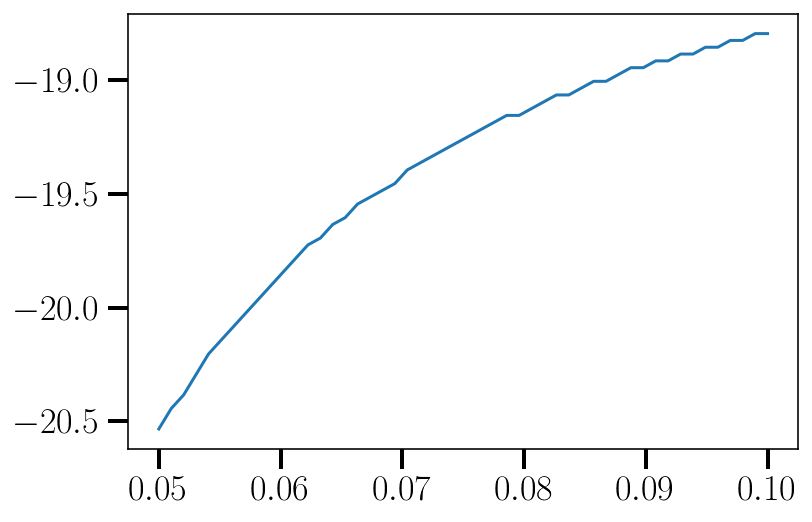

In [23]:
plt.plot(k1,fnl_test,'-')

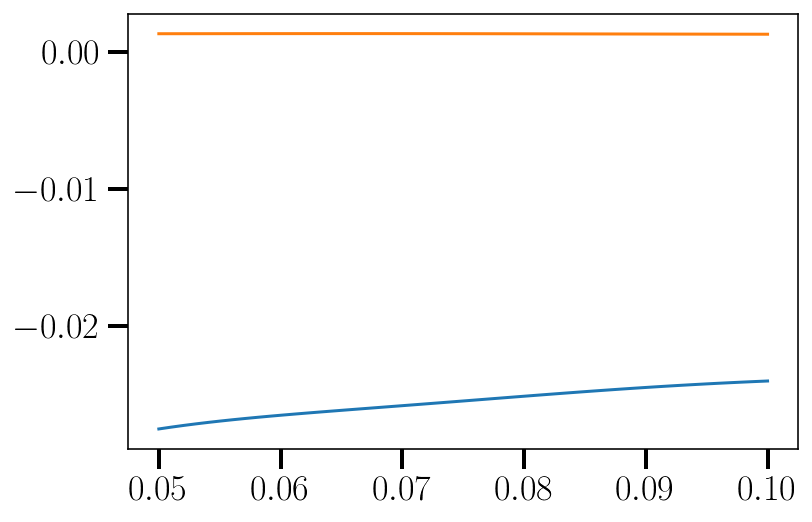

In [24]:
#plt.plot(k1,((WA2.l0(params,r,s)+Der2.l0(params,derivs,r,s))/GR0.l0(params)))
plt.plot(k1,(GR2.l0(params,betas))/GR0.l0(params))
PNGparams = cosmo_functions.get_PNGparams(1,zz,k1,k2,k3)
plt.plot(k1,(GR0PNG.l0(params,PNGparams)-GR0.l0(params))/GR0.l0(params))


In [25]:
#lets plot reduced - so get denominator
def part_reduced(params):
    k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params    
    
    return D1**4 *(b1**2 + 2*b1*f/3 + (f**2)/5)**2 *(Pk1 * Pk2 + Pk1 * Pk3 + Pk2 * Pk3)

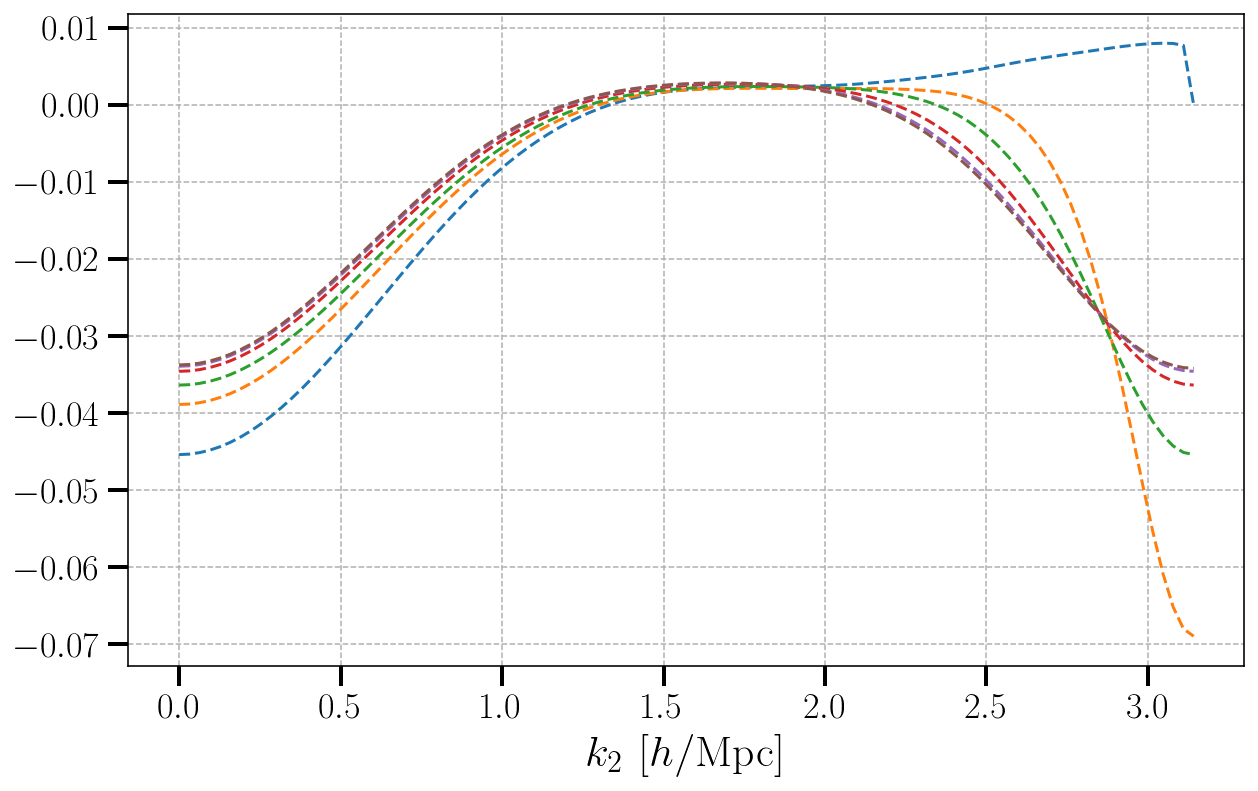

In [56]:
#compare eline
cosmo_functions = CosmologicalFunctions(cosmo_eline)
zz=1
plt.figure(figsize=(10,6))
#k1 = np.linspace(0.01,0.5,1000)
#k3 = k1/26
#k2= k1

#k3 = np.linspace(0.0001,0.5,1000)
#k1 = 0.5001*k3;k2=k1

k1= 0.1/h
for i in [1,1.5,2,3,4,4.5]:
    k2= k1*i
    theta = np.linspace(0,np.pi,100)

    #theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
    #print(theta*180/np.pi)
    k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

    params = cosmo_functions.get_params(k1,k2,theta,zz)
    derivs = cosmo_functions.get_derivs(zz)
    betas = cosmo_functions.get_beta_funcs(zz)

    #plt.plot(theta,3.5*(GR0.l0(params)+GR2.l0(params,betas))/part_reduced(params))
    #plt.plot(theta,np.sqrt((4*np.pi)/5)*(GR0.l2(params)+GR2.l2(params,betas))/part_reduced(params))

    #plt.plot(theta,np.sqrt((4*np.pi)/3)*GR1.l1(params,betas).imag/part_reduced(params),'--')
    #plt.plot(theta,np.sqrt((4*np.pi)/3)*GR1_eline.l1(params,betas).imag/part_reduced(params)/h,'-')
    #plt.plot(theta,np.sqrt((4*np.pi)/7)*GR1_eline.l3(params,betas).imag/part_reduced(params),'-')
    plt.plot(theta,np.sqrt((4*np.pi)/7)*GR1_test.l3(params,betas).imag/part_reduced(params),'--')

plt.xlabel('$ k_2 \,\,[h/\mathrm{Mpc}]$')
#plt.ylabel('$ B_{\ell=0}(k1=2 k_2=2 k_3) \,\,[\mathrm{Mpc}/h]^3$')
#plt.ylim(-0.169,0.019)
#plt.plot(k3,np.zeros_like(k3),'--', color='black')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(ls='--',lw=0.75)
plt.show()

In [52]:
print(h)

0.6766


In [59]:
k1=np.linspace(0.01,0.1)#0.08#
k2=k1
theta = 2*np.pi/3#np.linspace(0,np.pi,200)#np.pi#
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

In [61]:
#for sciccimarro comparison...
zz=0.8
k1=0.04#np.linspace(0.01,0.1)#
k2=k1/2
theta = np.linspace(0,np.pi,200)#2*np.pi/3#np.pi#
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))
params = cosmo_functions.get_params(k1,k2,theta,zz)
k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2 = params
derivs = cosmo_functions.get_derivs(zz)
fd,Dd,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1 = derivs
betas = cosmo_functions.get_beta_funcs(zz)

#D1=1
#K=3/7
#C=3/7

#Dd =0#fd=0
#bd1=0
#bd2=0
#fd=0
#gd2=0
derivs = fd,Dd,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1
params = (k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2)
derivs1 = fd,0,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1
derivs2 = 0,Dd,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1
derivs3 = fd,Dd,0,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1
derivs4 = fd,Dd,gd2,0,bd1,fdd,Ddd,gdd2,bdd2,bdd1
derivs5 = fd,Dd,gd2,bd2,0,fdd,Ddd,gdd2,bdd2,bdd1
gamma2= g2

In [62]:
print(fd/f)
print(Dd/D1)
print(bd1/b1)
print(bd2/b2)
print(gd2/g2)

0.27900017252120984
-0.4617102397652294
0.33160919389691235
-0.11197268077544026
1.7477514633294284


In [55]:
zz=0.5

k1 = np.linspace(0.05,0.1)
k3 = k1
k2= 0.01
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
#k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo,'DESI')#
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(100,zz,k1,k2,k3)


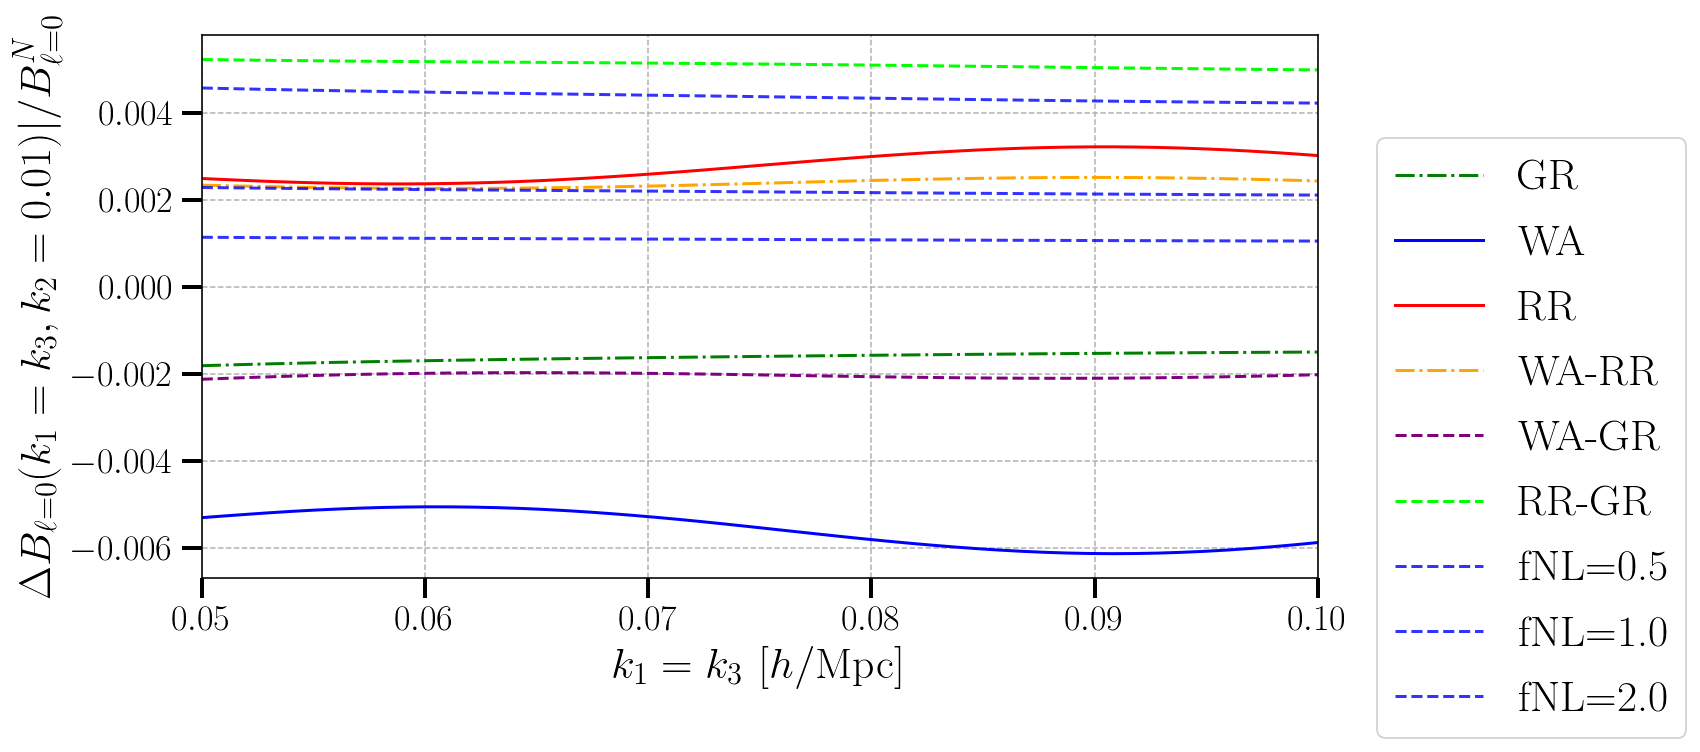

In [57]:
#so lets plot monopole...
plt.figure(figsize=(10,5))
r=0;s=1
#WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)
justwaRR=WA2.l0(params,r,s)+Der2.l0(params,derivs,r,s)+Mix.l0(params,derivs,r,s)
#totalwa = justwaRR+WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)
#total = WA2.l0(params,r,s)+Der2.l0(params,derivs,r,s)+Mix.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)+GR2.l0(params,betas)
plt.plot(k3,GR2.l0(params,betas)/2/GR0.l0(params),'-.',label='GR',color='green')
#plt.plot(k3,GR22.l0(params,betas)/GR0.l0(params),'-',label='GR',color='green')
plt.plot(k3,WA2.l0(params,r,s)/GR0.l0(params),'-',label='WA',color='blue')
plt.plot(k3,Der2.l0(params,derivs,r,s)/GR0.l0(params),'-',label='RR',color='red')
plt.plot(k3,Mix.l0(params,derivs,r,s)/GR0.l0(params),'-.',label='WA-RR',color='orange')

plt.plot(k3,WAGR.l0(params,betas,r,s)/GR0.l0(params),'--',label='WA-GR',color='purple')
plt.plot(k3,DerGR.l0(params,derivs,betas,r,s)/GR0.l0(params),'--',label='RR-GR',color='lime')

for i in [0.5,1.0,2.0]:
    PNGparams = cosmo_functions.get_PNGparams(i,zz,k1,k2,k3)
    plt.plot(k3,(GR0PNG.l0(params,PNGparams)-GR0.l0(params))/GR0.l0(params),'--',color='blue',alpha=0.8,label='fNL=%.1f'%i)#
    #plt.plot(k3,(GR0PNGtest.l0(params,PNGparams)-GR0.l0(params))/GR0.l0(params),'--',color='lime')

#plt.plot(k3,totalwa/GR0.l0(params),'--',color='black',label='RR+WA')
#plt.plot(k3,justwaRR/GR0.l0(params),'-',color='red',label='RR+WA')
#plt.plot(k3,total/GR0.l0(params),label='RR+WA+GR',color='black')
plt.xlabel('$ k_1=k_3 \,\,[h/\mathrm{Mpc}]$')
plt.ylabel(r'$\Delta B_{\ell=0}(k_1=k_3,k_2=0.01)|/B^N_{\ell=0}$')
#plt.plot(k3,np.zeros_like(k3),'--', color='black')
#plt.text(0.1,0.6,r"z=0.4 - DESI-like")
plt.xlim(0.05,0.10)
plt.legend(bbox_to_anchor=(0.85, 0.35, 0.5, 0.5))
plt.grid(ls='--',lw=0.75)
#plt.ylim(0,0.003)
plt.savefig('second_order_lots.png', bbox_inches='tight', dpi=400)
plt.show()

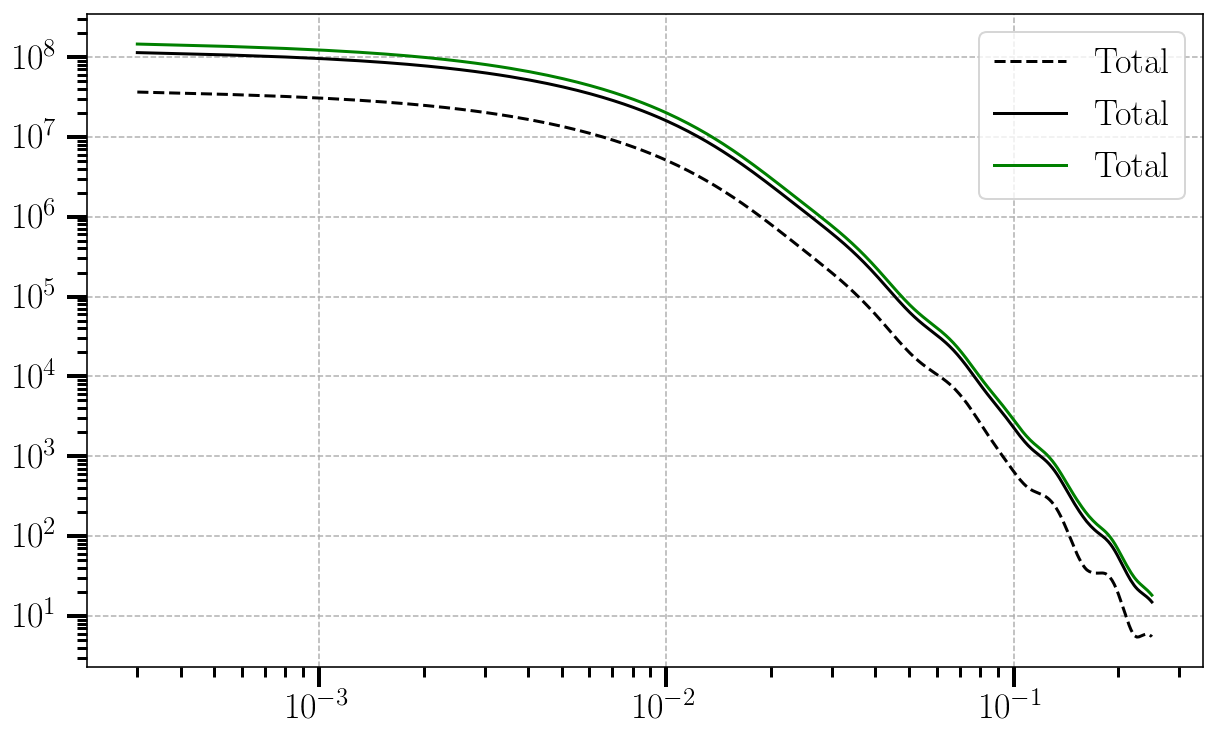

In [256]:
#test GR:
zz=1
k1 = np.linspace(0.0006,0.5,1000)
k3 = k1/2
k2= k1
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
#k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(1,zz)

plt.figure(figsize=(10,6))
r=0;s=0

totalwa = WA2.l0(params,r,s)+Der2.l0(params,derivs,r,s)+Mix.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)
total = totalwa+GR2.l0(params,betas)
total1 = totalwa+GR22.l0(params,betas)

#plt.plot(k3,np.abs(GR2.l0(params,betas)),'-.',label='GR',color='green')
#plt.plot(k3,np.abs(WA2.l0(params,r,s)),'--',label='Wide-angle',color='blue')
#plt.plot(k3,np.abs(Der2.l0(params,derivs,r,s)),'--',label='redshift derivative',color='red')
#plt.plot(k3,np.abs(Mix.l0(params,derivs,r,s)),'-.',label='Mixed',color='orange')
#plt.plot(k3,(GR0PNG.l0(params,PNGparams)-GR0.l0(params)),'--',color='grey')
#plt.plot(k3,np.abs(WAGR.l0(params,betas,r,s)),'--',label='Wide-angle',color='purple')
#plt.plot(k3,np.abs(DerGR.l0(params,derivs,betas,r,s)),'--',label='Wide-angle',color='lime')

plt.plot(k3,np.abs(totalwa),'--',label='Total',color='black')
plt.plot(k3,np.abs(total),label='Total',color='black')
plt.plot(k3,np.abs(total1),label='Total',color='green')

plt.xscale('log')
plt.yscale('log')
plt.grid(ls='--',lw=0.75)
plt.legend()
plt.show()

<Figure size 720x360 with 0 Axes>

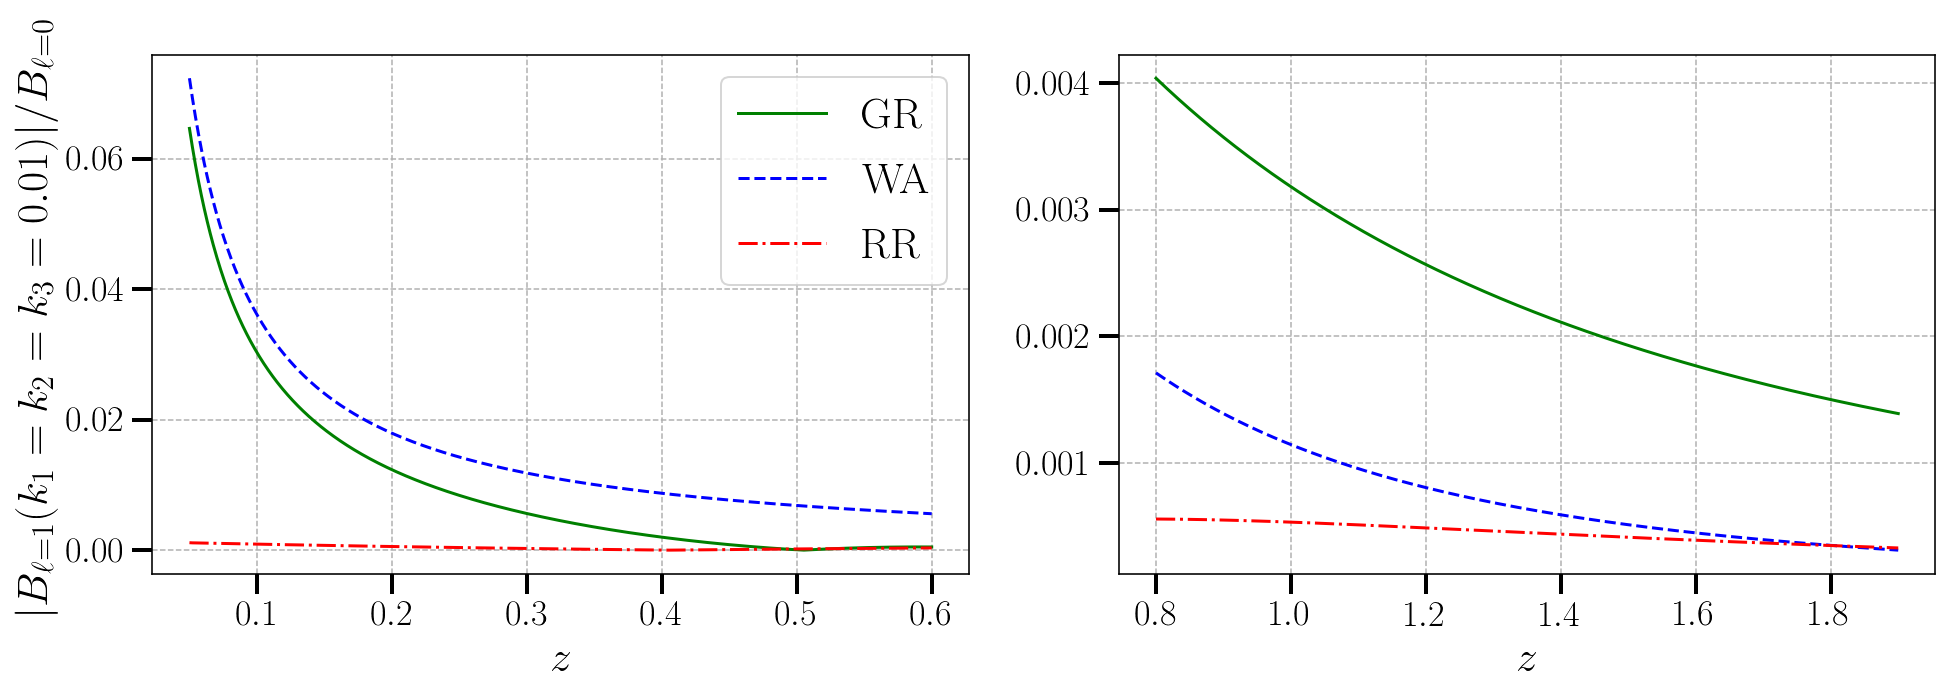

In [40]:
plt.figure(figsize=(10,5))

#plt.xlim(0,1)
z_plot = np.linspace(0.05,0.6,1000)#np.linspace(0.8,1.9,1000)#

k1 = 0.10
k2= k1
k3=0.01
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))

cosmo_functions = CosmologicalFunctions(cosmo,'DESI')#
params = cosmo_functions.get_params(k1,k2,theta,z_plot)
derivs = cosmo_functions.get_derivs(z_plot)
betas = cosmo_functions.get_beta_funcs(z_plot)
PNGparams = cosmo_functions.get_PNGparams(1,z_plot,k1,k2,k3)

r=0;s=0

norm = GR0.l0(params)

if False:
    #totalwa = WA2.l0(params,r,s)+Der2.l0(params,derivs,r,s)+Mix.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)
    #total = WA2.l0(params,r,s)+Der2.l0(params,derivs,r,s)+Mix.l0(params,derivs,r,s)+WAGR.l0(params,betas,r,s)+DerGR.l0(params,derivs,betas,r,s)+GR2.l0(params,betas)

    plt.plot(z_plot,np.abs(totalwa/GR0.l0(params)),'--',label='Total',color='black')
    plt.plot(z_plot,np.abs(total/GR0.l0(params)),label='Total',color='black')
    #plt.plot(z_plot,(GR22.l0(params,betas)/norm),'-.',label='GR',color='green')
    #plt.plot(z_plot,(WA2.l0(params,r,s)/norm),'--',label='Wide-angle',color='blue')
    #plt.plot(z_plot,(Der2.l0(params,derivs,r,s)/norm),'--',label='redshift derivative',color='red')
    #plt.plot(z_plot,(Mix.l0(params,derivs,r,s)/norm),'-.',label='Mixed',color='orange')
    #plt.plot(z_plot,np.abs(GR0PNG.l0(params,PNGparams)-GR0.l0(params))/norm,'--',color='grey')
    #plt.plot(z_plot,(WAGR.l0(params,betas,r,s)/norm),'--',label='',color='purple')
    #plt.plot(z_plot,(DerGR.l0(params,derivs,betas,r,s)/norm),'--',label='',color='lime')
    plt.legend()
    plt.grid(ls='--',lw=0.75)
    plt.xlabel('$z$')
    
else:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
    for i in range(2):
        if i == 0:
            cosmo_functions = CosmologicalFunctions(cosmo,'DESI')
            z_plot = np.linspace(0.05,0.6,1000)
        else:
            cosmo_functions = CosmologicalFunctions(cosmo)
            z_plot = np.linspace(0.8,1.9,1000)#np.linspace(0.05,0.6,1000)
      
        params = cosmo_functions.get_params(k1,k2,theta,z_plot)
        derivs = cosmo_functions.get_derivs(z_plot)
        betas = cosmo_functions.get_beta_funcs(z_plot)

        axs[i].plot(z_plot,np.abs(GR1.l1(params,betas)/norm),'-',label='GR',color='green')
        axs[i].plot(z_plot,np.abs(WA1.l1(params,r,s)/norm),'--',label='WA',color='blue')
        axs[i].plot(z_plot,np.abs(Der1.l1(params,derivs,r,s)/norm),'-.',label='RR',color='red')
        axs[i].set_xlabel('$z$')
        axs[i].grid(ls='--',lw=0.75)
        #axs[i].set_yscale('log')
        
    axs[0].legend()
    axs[0].set_ylabel('$  |B_{\ell=1}(k_1=k_2= k_3=0.01)|/B_{\ell=0}$')
    plt.tight_layout()
    #plt.savefig('redshift_first.png', bbox_inches='tight', dpi=400)
    
#plt.ylabel('$  B_{\ell=1}(k_1=k_2= k_3=0.01)\,\,[\mathrm{Mpc}/h]^6$')

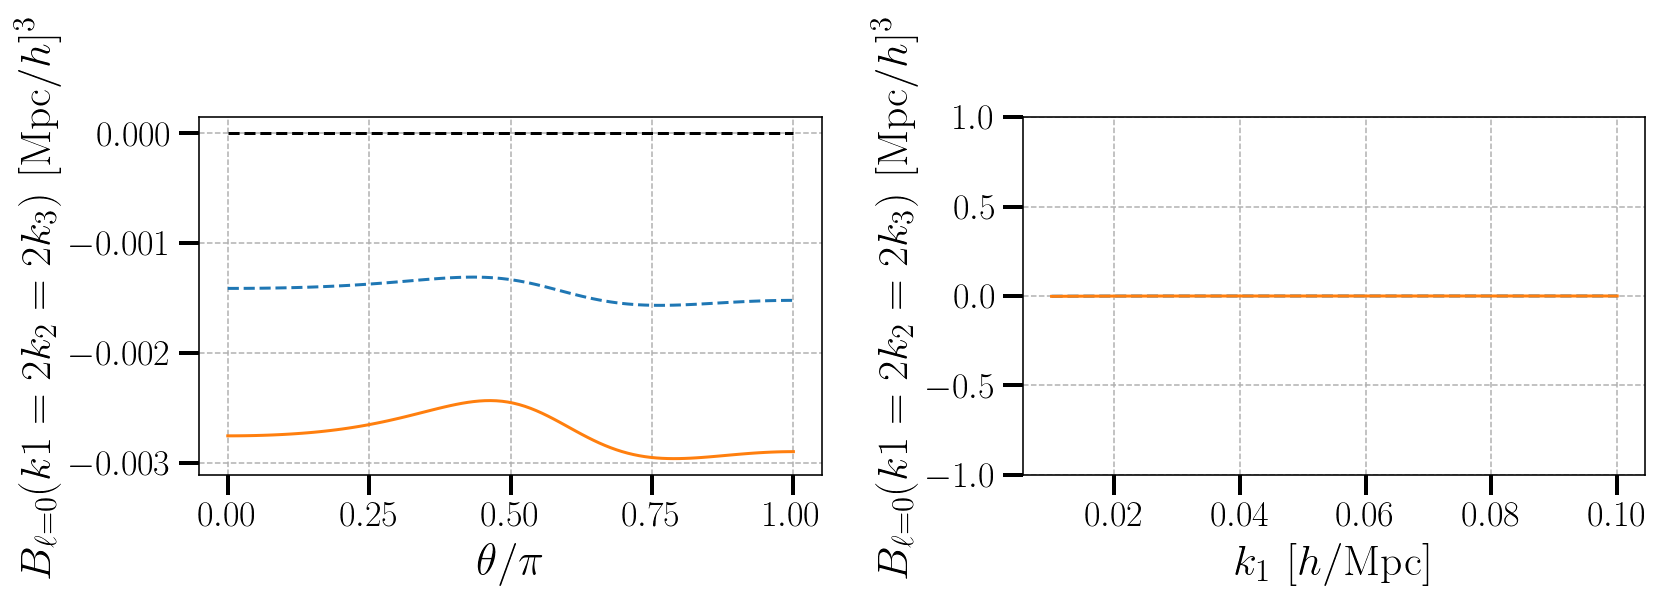

In [56]:
#for quadrupole

# Create a figure and a gridspec
fig = plt.figure(figsize=(12, 4))
gs = GridSpec(1, 2, width_ratios=[4,4])

# Create subplots using the gridspec
ax1 = plt.subplot(gs[0, 0])
ax2 = plt.subplot(gs[0, 1])

zz=0.5;k1=0.04;k2=k1/4
theta = np.linspace(0,np.pi,100)#2*np.pi/3#np.pi#
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo,'DESI')#
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
PNGparams = cosmo_functions.get_PNGparams(1,z_plot,k1,k2,k3)

r=0;s=0
#comb = WA2.l2(params,r,s)+Der2.l2(params,derivs,r,s)+Mix.l2(params,derivs,r,s)

norm = GR0.l0(params)
# Plot on each subplot
#ax1.plot(theta/np.pi,WA2.l2(params,r,s)/norm)
#ax1.plot(theta/np.pi,comb/norm)
ax1.plot(theta/np.pi,GR2.l2(params,betas)/norm,'--')
ax1.plot(theta/np.pi,GR22.l2(params,betas)/norm,'-')
ax1.set_xlabel(r'$ \theta /\pi$')
ax1.set_ylabel('$ B_{\ell=0}(k1=2 k_2=2 k_3) \,\,[\mathrm{Mpc}/h]^3$')
ax1.plot(theta/np.pi,np.zeros_like(theta),'--', color='black')
ax1.grid(ls='--',lw=0.75)


k1=np.linspace(0.01,0.1,100);k2=k1;k3=1*k1
theta = np.arccos((k3**2 - k1**2 - k2**2)/(2*k1*k2))
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)

#r=0;s=0
#comb = WA2.l2(params,r,s)+Der2.l2(params,derivs,r,s)+Mix.l2(params,derivs,r,s)

# Plot on each subplot
#ax2.plot(k1,WA2.l2(params,r,s)/norm)
ax2.plot(k1,GR2.l2(params,betas)/norm,'--')
ax2.plot(k1,GR22.l2(params,betas)/norm,'-')
#ax2.plot(k1,comb/norm)
ax2.set_xlabel(r'$ k_1 \,\, [h/\mathrm{Mpc}]$')
ax2.set_ylabel('$ B_{\ell=0}(k1=2 k_2=2 k_3) \,\,[\mathrm{Mpc}/h]^3$')
#ax2.plot(k1,np.zeros_like(k1),'--', color='black')
ax2.set_ylim(-1,1)
ax2.grid(ls='--',lw=0.75)

plt.tight_layout()
plt.show()

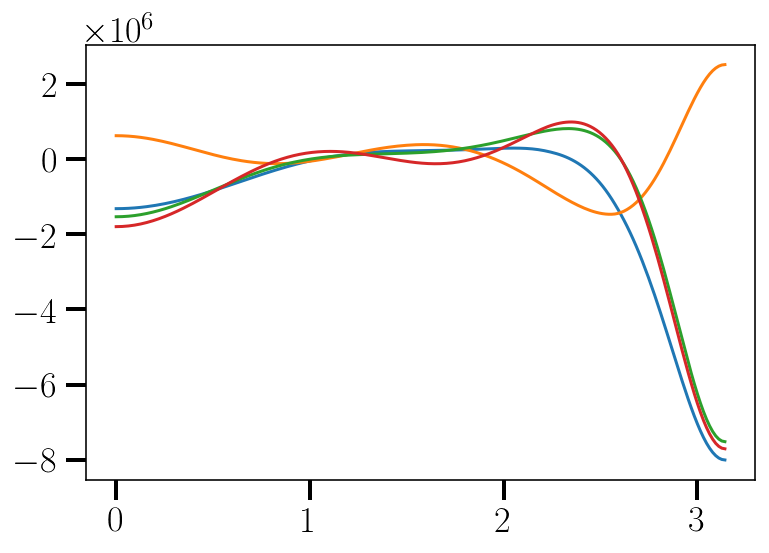

In [833]:
#plt.plot(theta,WA1mid.imag)
#plt.plot(theta,Der1mid.imag)
#plt.plot(theta,WA2.l2(params,1,0))
plt.plot(theta,Der2.l2(params,derivs,0,0))
plt.plot(theta,Der2.l2(params,derivs1,0,0))
plt.plot(theta,Der2.l2(params,derivs2,0,0))
#plt.plot(theta,Der2.l2(params,derivs3,0,0))
#plt.plot(theta,Der2.l2(params,derivs4,0,0))
plt.plot(theta,Der2.l2(params,derivs5,0,0))
#plt.plot(theta,Mix.l2(params,derivs,0,0))
#plt.plot(theta,Der2.l2(params,derivs,1,0)+Mix.l2(params,derivs,1,0)+WA2.l2(params,1,0),'--')
#plt.plot(theta,WA1.l1(params,0,0).imag)
#plt.plot(theta,WA2.l0(params,1,0))
#plt.plot(theta,WA2.l0(params,0,1))
#plt.plot(theta,WA2.l0(params,1/3,1/3),'--')


In [166]:
#for sciccimarro comparison...
zz=1
k1=0.05#np.linspace(0.01,0.1)#
k2=k1/2
theta = np.linspace(0,np.pi,200)#2*np.pi/3#np.pi#
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo)#'DESI'
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)


### In Eds - u= v =1

$$v=\frac{7 K}{3} =\frac{7 F}{3D^2}$$

$$u = \frac{7 C}{3} \equiv \frac{7}{3}\frac{\dot{F}}{2\dot{D}D}$$


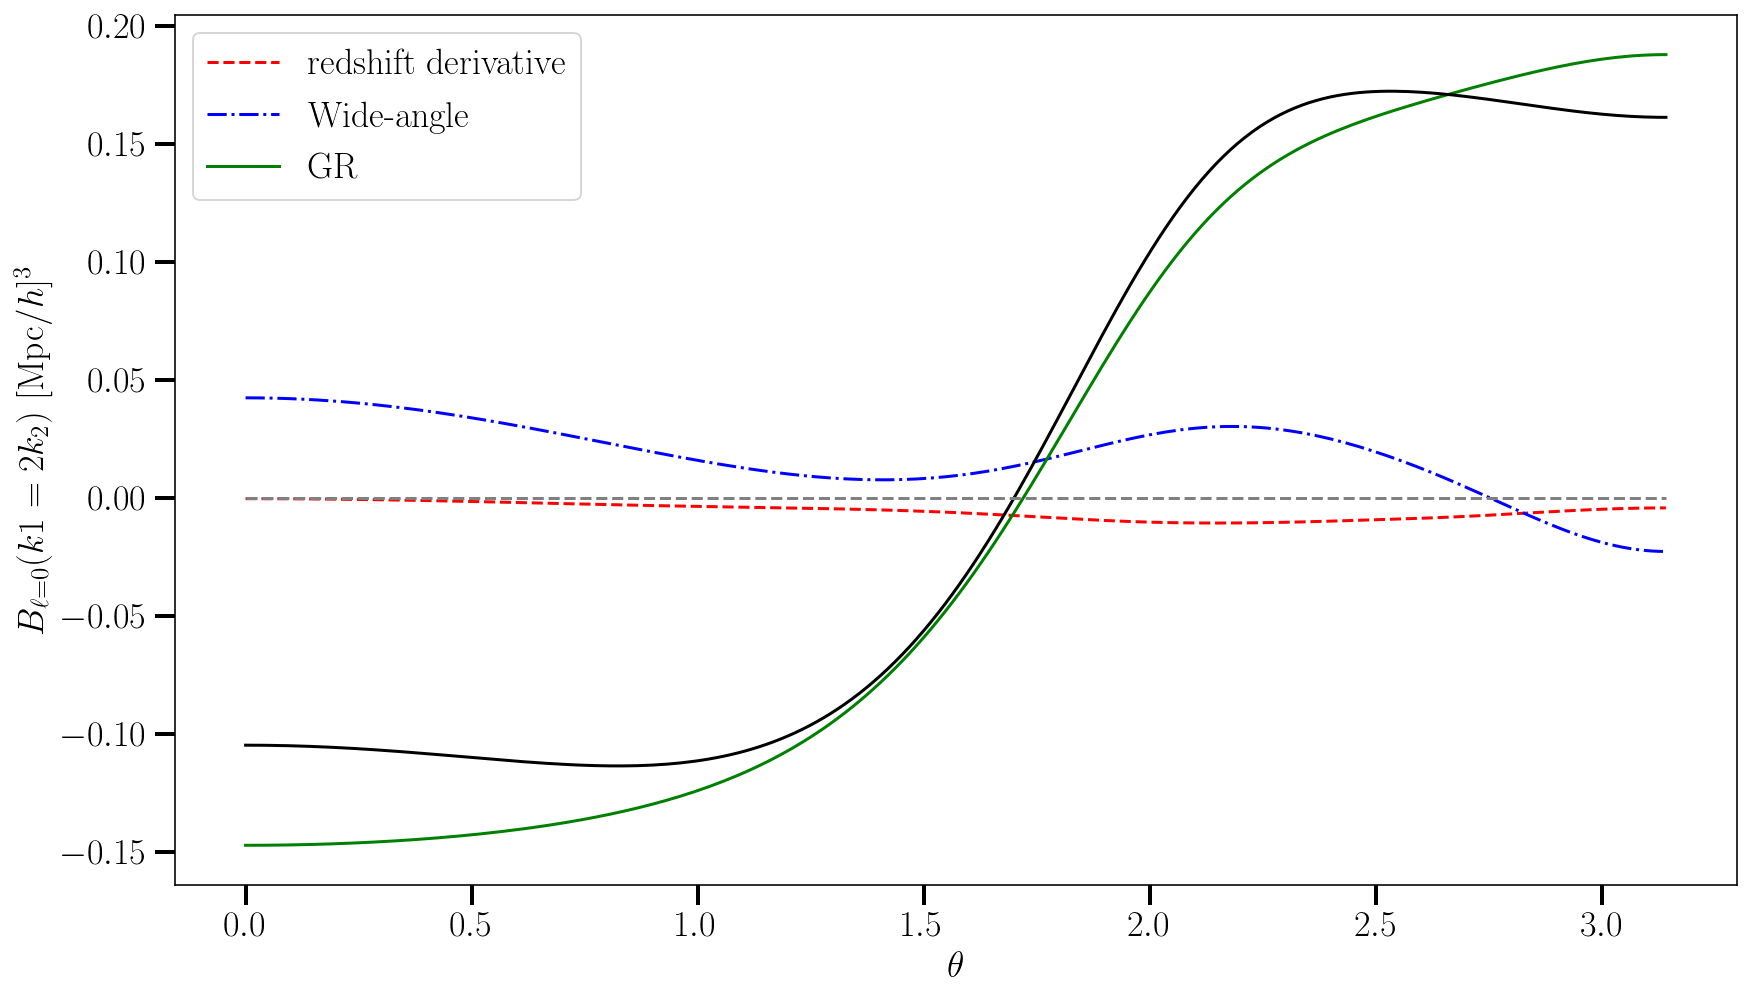

In [167]:
plt.figure(figsize=(14,8))
r=0;s=0
#plt.plot(theta,bk_terms.WA1.l1(params,0,0).imag,alpha=0.4,color='blue')
#plt.plot(theta,bk_terms.Der1.l1(params,derivs,0,0).imag,'-.',alpha=0.4,color='blue')
#plt.plot(theta,WA1.l1(params,1,0).imag,alpha=0.4,color='red')
#plt.plot(theta,Der1.l1(params,derivs,1,0).imag,'-.',alpha=0.4,color='red')
#plt.plot(theta,WA1.l1(params,0,1).imag,alpha=0.4,color='green')
#plt.plot(theta,Der1.l1(params,derivs,0,1).imag,'-.',alpha=0.4,color='green')
#plt.plot(theta,WA1.l1(params,1/3,1/3).imag,color='black')
#plt.plot(theta,Der1.l1(params,derivs,1/3,1/3).imag,'-.',color='black')
#plt.plot(theta,WA1.l1(params,0,1).imag+Der1.l1(params,derivs,1/3,1/3).imag,'--',color='black')

plt.plot(theta,(Der1.l1(params,derivs,r,s).imag)/GR0.l0(params),'--',color='red',label='redshift derivative')
plt.plot(theta,WA1.l1(params,r,s).imag/GR0.l0(params),'-.',color='blue',label='Wide-angle')
#plt.plot(theta,2*GR1.l1(params,betas).imag/GR0.l0(params),'-',color='green',label='GR')
plt.plot(theta,GR11.l1(params,betas).imag/GR0.l0(params),'-',color='green',label='GR')



plt.plot(theta,(WA1.l1(params,r,s).imag+GR11.l1(params,betas).imag+Der1.l1(params,derivs,r,s).imag)/GR0.l0(params),'-',color='black')
plt.plot(theta,np.zeros_like(theta),'--',color='grey')
plt.xlabel(r'$ \theta $')
plt.ylabel('$ B_{\ell=0}(k1= 2 k_2) \,\,[\mathrm{Mpc}/h]^3$')
plt.legend()
#plt.xlim(1.5,2)
#plt.plot(theta,testoldder/d)
#plt.plot(theta,testold.real/(d),'-.',color='black')
#plt.plot(theta,testold.real/(d),'-.',color='grey')

$$\alpha(k,z)= \frac{2 k^2 c^2 D(z) T(k)}{3 H^2_0 \Omega_m}$$

**Ok so we start 1st order wide angle correction to the bispectrum - see bk_wide_angle mathematica\
We will have 18 terms - 3 cycles - 6 per cycle\
each with e1 and e2 parts\  
with each having a d.e and q.e parts**

In [35]:
#ok get some equalateral triangles...

k1_eq = np.geomspace(1e-4,1,1000)
k2_eq = k1_eq
theta_eq = np.arccos(-(k1_eq**2)/(2*k1_eq*k2_eq))


$$\ddot{F}+\mathcal{H} \dot{f}=\frac{3 H_0^2 \Omega_m}{2 a} (F+D^2)$$
$$\mathcal{H}^2(1+z)^2 F''+(\mathcal{H'}\mathcal{H}(1+z)^2) F'=\frac{3 H_0^2 \Omega_{m,0}}{2 a} (F+D^2)$$

No handles with labels found to put in legend.


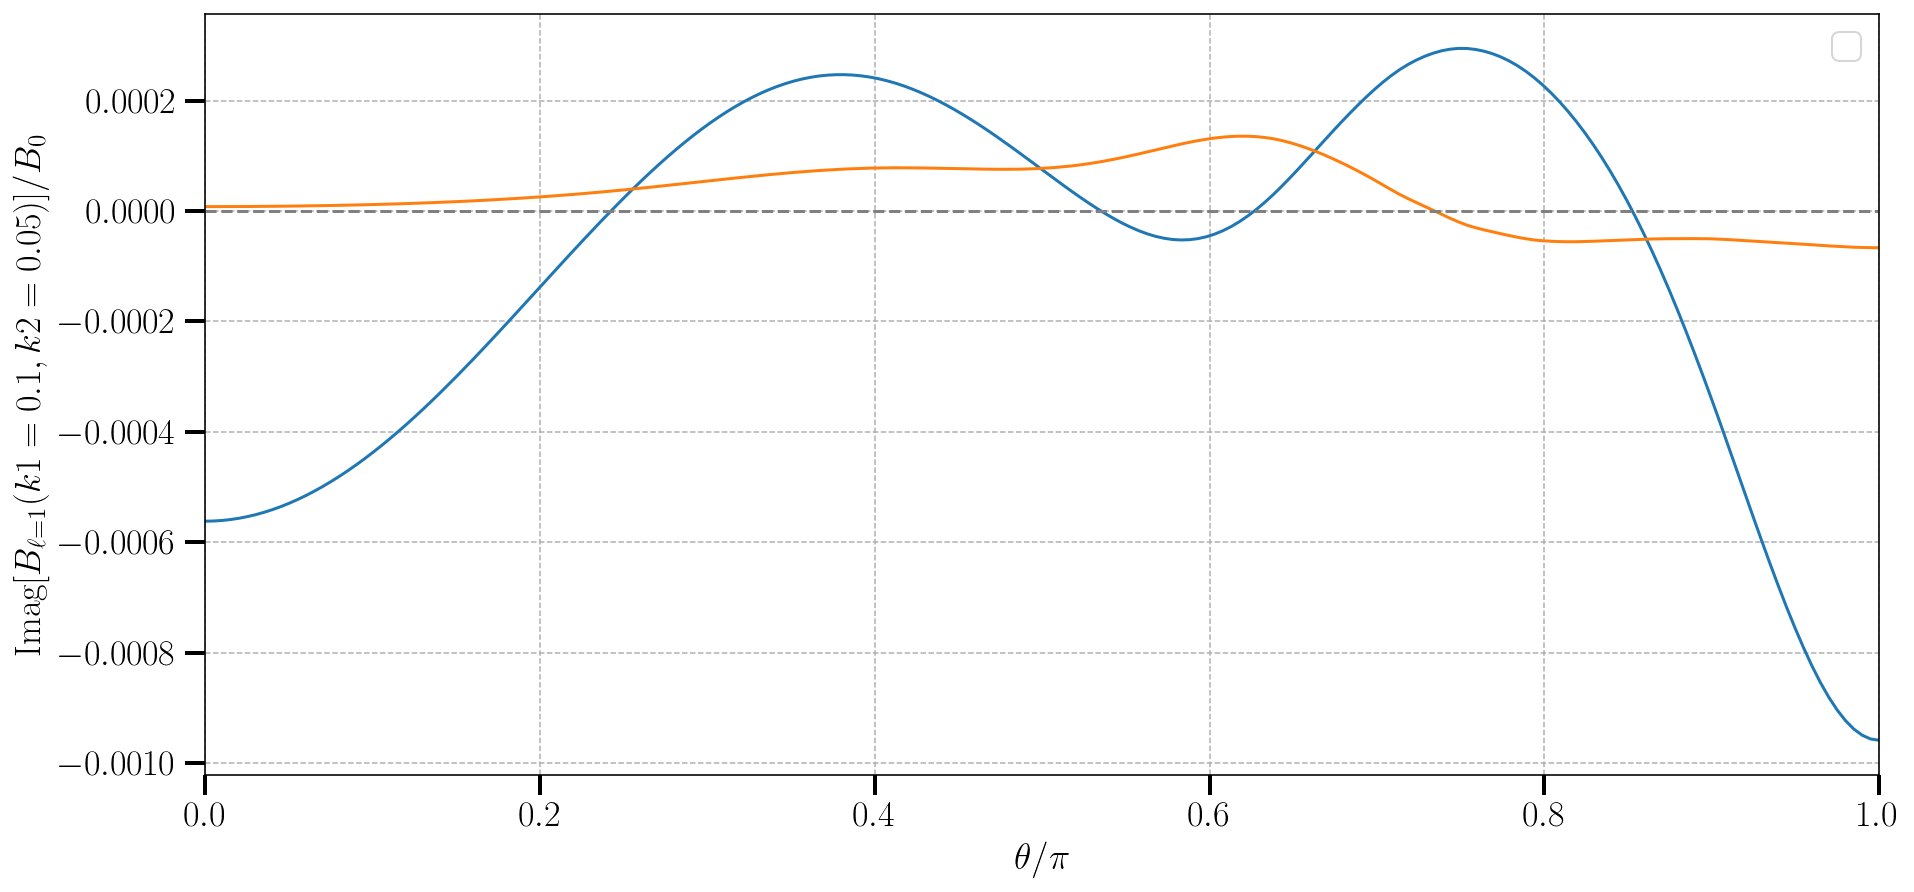

In [408]:
plt.figure(figsize=(15,7))
#plt.ylim(-0.7,0.2)
plt.xlim(0,1)
plt.grid(ls='--',lw=0.75)

#plt.plot(theta/np.pi,Bk_wideangle1/bkmono,'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_1$')
#plt.plot(theta/np.pi,Bk_wideangle2/bkmono,'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_2$')
#plt.plot(theta/np.pi,Bk_wideangle3/bkmono,'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_3$')

plt.plot(theta/np.pi,WA2.l0(params,1/3,1/3)/GR0.l0(params))
plt.plot(theta/np.pi,Der2.l0(params,derivs,1/3,1/3)/GR0.l0(params))
#plt.plot(theta/np.pi,Mix.l0(params,derivs,1/3,1/3)/GR0.l0(params))
plt.plot(theta/np.pi,np.zeros_like(theta),color='grey',linestyle='--')

plt.legend()
plt.xlabel(r'$\theta/ \pi\,$')
plt.ylabel(r'$ \text{Imag}[B_{\ell=1}(k1=0.1,k2=0.05)]/B_0 $')
plt.savefig('wrong_wide_angle_theory.png')

In [204]:
#So we need average (1/d) over redshift bin...
rout = comoving_dist(0.35)#1.2#
rmin = comoving_dist(0.15)#0.8#

d_plot = (3/2)*(rout**2-rmin**2)/(rout**3-rmin**3)
print(1/d_plot)

728.5929127055081


<Figure size 792x360 with 0 Axes>

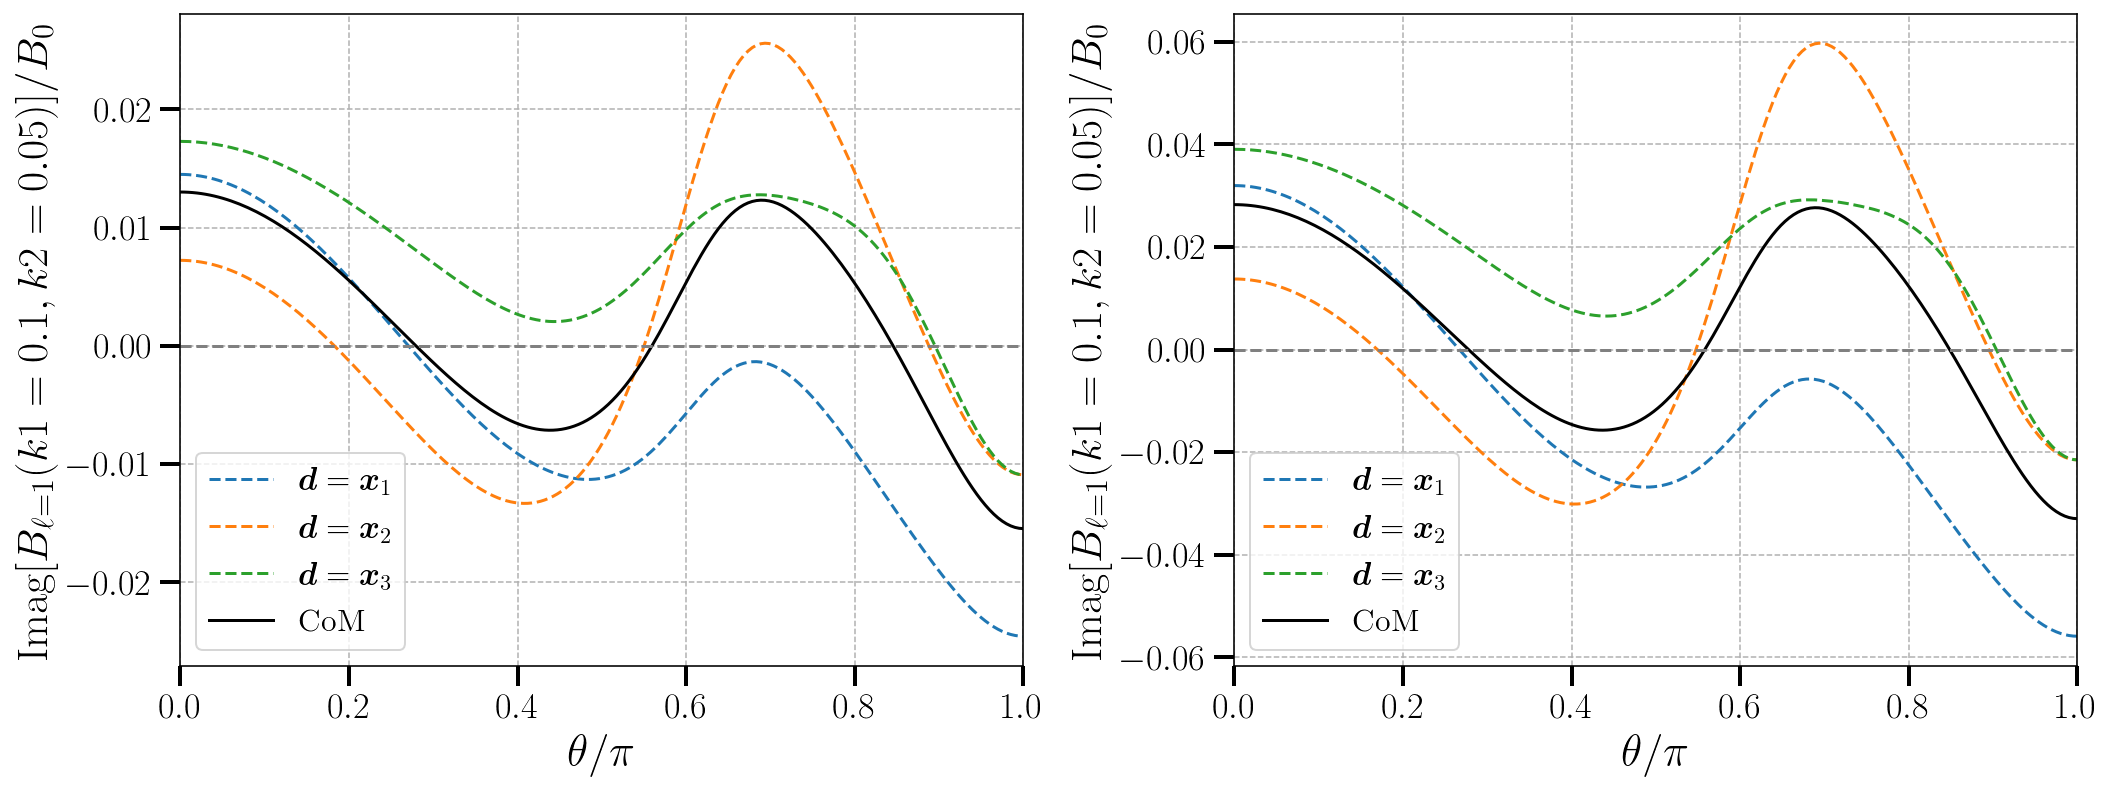

In [796]:
fig = plt.figure(figsize=(11, 5))

# Define gridspec with 4 rows and 3 columns
#gs = GridSpec(1, 2,width_ratios=[3, 3])

# Create subplots with custom aspect ratios
#axs = [fig.add_subplot(gs[0, i], aspect='10') for i in range(2)]  # Subplots in the first row

fig, axs = plt.subplots(1, 2,figsize=(17,6))
fig.subplots_adjust(wspace=0.25)
# Create the colormap plot
#im0 = axs[0].imshow(np.abs(bk0.T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='viridis',norm=mpl.colors.LogNorm(1e-2, vmax=vmax))#,vmin=0,vmax=vmax)#
#im1 = axs[1].imshow(np.abs(bk1.T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='viridis',norm=mpl.colors.LogNorm(1e-2, vmax=vmax))#,vmin=0,vmax=vmax)#
#im2 = axs[2].imshow(np.abs(bk2.T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='viridis',norm=mpl.colors.LogNorm(1e-2, vmax=vmax))#,vmin=0,vmax=vmax)#

axs[0].plot(theta/np.pi,z1x1,'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_1$')
axs[0].plot(theta/np.pi,z1x2,'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_2$')
axs[0].plot(theta/np.pi,z1x3,'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_3$')
axs[0].plot(theta/np.pi,z1xmid,'k',label=r'$\text{CoM}$')
axs[0].plot(theta/np.pi,np.zeros_like(theta),color='grey',linestyle='--')
axs[0].legend(fontsize =16)
axs[0].set_xlim(0,1)
#axs[0].set_ylim(-0.07,0.07)
axs[0].set_xlabel(r'$\theta/ \pi\,$')
axs[0].set_ylabel(r'$ \text{Imag}[B_{\ell=1}(k1=0.1,k2=0.05)]/B_0 $')
axs[0].grid(ls='--',lw=0.75)


axs[1].plot(theta/np.pi,z2x1,'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_1$')
axs[1].plot(theta/np.pi,z2x2,'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_2$')
axs[1].plot(theta/np.pi,z2x3,'--',label=r'$\boldsymbol{d}=\boldsymbol{x}_3$')
axs[1].plot(theta/np.pi,z2xmid,'k',label=r'$\text{CoM}$')
axs[1].plot(theta/np.pi,np.zeros_like(theta),color='grey',linestyle='--')
axs[1].legend(fontsize =16)
axs[1].set_xlim(0,1)
#axs[1].set_ylim(-0.07,0.07)

axs[1].set_xlabel(r'$\theta/ \pi\,$')
axs[1].set_ylabel(r'$ \text{Imag}[B_{\ell=1}(k1=0.1,k2=0.05)]/B_0 $')
axs[1].grid(ls='--',lw=0.75)

plt.savefig('Milad_plot.png', bbox_inches='tight', dpi=400)
#axs[1].yaxis.set_major_locator(plt.NullLocator())


In [168]:
#so data storage format
bk_0 = {}
bk_wa1 = {}
bk_der1 = {}
bk_rad2 = {}

In [178]:
from tqdm import tqdm
# Define the function
#@jit
def triangle_plot(x, y, zz,r=0,s=0):
    """Get array of"""
    bk = np.zeros((len(x),len(y)))
    
    cosmo_functions = CosmologicalFunctions(cosmo)
    derivs = cosmo_functions.get_derivs(zz)
    betas = cosmo_functions.get_beta_funcs(zz)
        
    #so only do select values of bispectrum...
    for i in tqdm(range(len(x))):
        #array version:
        k1 = 0.05
        k2 = y*k1
        k3 = x[i]*k1
        
        which_k2 = np.logical_and((y > 1 - x[i]), (y>x[i]))#restrict to closed triangles
        k2_= k2[which_k2]
        #get theta from triagle condition
        theta = np.arccos((k3**2 -k1**2 - k2_**2)/(2*k1*k2_))
        
        params = cosmo_functions.get_params(k1,k2_,theta,zz)
        
        bk[i][which_k2] = Der1.l1(params,derivs, r, s).imag
        #bk[i][which_k2] = WA1.l1(params, r, s).imag
        #bk[i][which_k2] = GR0.l0(params).real
        
        
        #bk[i][which_k2] = Mix.l0(params,derivs, r, s).imag
        #bk[i][which_k2] = Der2.l0(params,derivs, r, s).real
        
    return bk


xx = np.linspace(0.01, 1, 300)
yy = np.linspace(0.5, 1, 300)

zz=1.0
r=0;s=0

#so lets get key 

r=0;s=0
key = "z=%.2f, r=%d, s=%d"% (zz, r, s)
bk_der1[key] = triangle_plot(xx,yy,zz,r,s)
r=1;s=0
key = "z=%.2f, r=%d, s=%d"% (zz, r, s)
bk_der1[key] = triangle_plot(xx,yy,zz,r,s)
r=0;s=1
key = "z=%.2f, r=%d, s=%d"% (zz, r, s)
bk_der1[key] = triangle_plot(xx,yy,zz,r,s)


mono_key = "z=%.2f"% (zz)
#bk_0[mono_key] = triangle_plot(xx,yy,zz,r,s)

100%|██████████| 300/300 [00:47<00:00,  6.33it/s]


In [2191]:
print(bk_der1.keys())
print(bk_wa1.keys())
print(bk_0.keys())

dict_keys(['z=0.10, r=0, s=0', 'z=1.00, r=0, s=0', 'z=1.00, r=1, s=0', 'z=1.00, r=0, s=1', 'z=0.20, r=0, s=0', 'z=0.20, r=1, s=0', 'z=0.20, r=0, s=1', 'z=0.60, r=0, s=0', 'z=0.60, r=1, s=0', 'z=0.60, r=0, s=1'])
dict_keys(['z=0.10, r=0, s=0', 'z=1.00, r=0, s=0', 'z=1.00, r=1, s=0', 'z=1.00, r=0, s=1', 'z=0.60, r=0, s=0', 'z=0.60, r=1, s=0', 'z=0.60, r=0, s=1'])
dict_keys(['z=0.10, r=0, s=0', 'z=1.00, r=0, s=0', 'z=0.60, r=0, s=1', 'z=0.60, r=0, s=0', 'z=0.60', 'z=1.00', 'z=2.00', 'z=0.50'])


In [382]:
def plot_triangle(bk,vmax,vmin=1): #plot triangle with mask!
    plt.figure(figsize=(8,3.5))
    # Create the colormap plot
    im = plt.imshow(np.abs(bk.T), extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(vmin, vmax=vmax))#,vmin=0,vmax=vmax)#
    #im = plt.imshow((bk.T), extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#
    
    cbar = plt.colorbar(im)#format='%.0e'
    cbar.set_label(r"$B_{\ell=1}(k_1=0.1,k_2,k_3)$")#P_{HI}(k1=0.05, \mu_1)P_{HI}(k2, \mu_2)P_{HI}(k3, \mu_3)B_{\text{Gravitational}(k1=0.05)}

    # Add labels and title
    plt.xlabel('$k_3/k_1$')
    plt.ylabel('$k_2/k_1$')

    #so masking 
    # Create a mask for the triangular region
    size = int(1e+3)
    x = np.linspace(0.0, 1, size,dtype=np.float32)
    y = np.linspace(0.5, 1,  size,dtype=np.float32)
    xx,yy = np.meshgrid(x,y)
    mask = np.where(np.logical_and((yy > 1 - xx), (yy>xx)),np.nan,1)
    im = plt.imshow(mask, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='binary')
    
    plt.grid(ls='--',lw=0.75,color='k',alpha=0.1)
    
    x_bound = [0,0.4965,1]
    y_bound = [1,0.50,1]#
    plt.text(0.06,0.55,'$r=s=1/3$')
    plt.plot(x_bound,y_bound,'k',linewidth=3)
    # Show the plot
    plt.savefig('B_var60.png', bbox_inches='tight', dpi=400)
    plt.show()

<ipython-input-2291-23375cfc3999>:2: RuntimeWarning: invalid value encountered in divide
  plot_triangle(bk_wa1['z=1.00, r=0, s=0']/bk_0['z=1.00'],1,1e-3)#d = x1


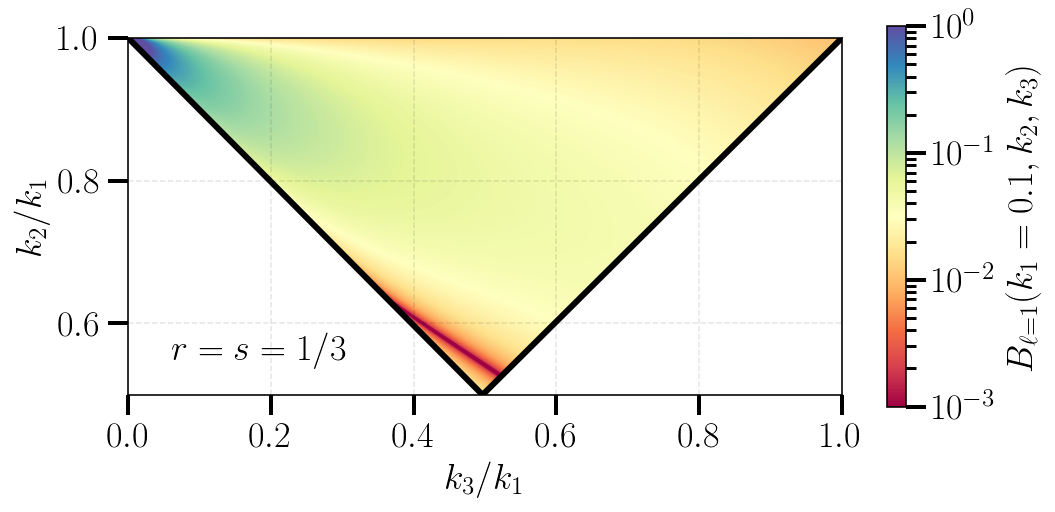

<ipython-input-2291-23375cfc3999>:3: RuntimeWarning: invalid value encountered in divide
  plot_triangle(bk_der1['z=1.00, r=0, s=0']/bk_0['z=1.00'],1,1e-3)


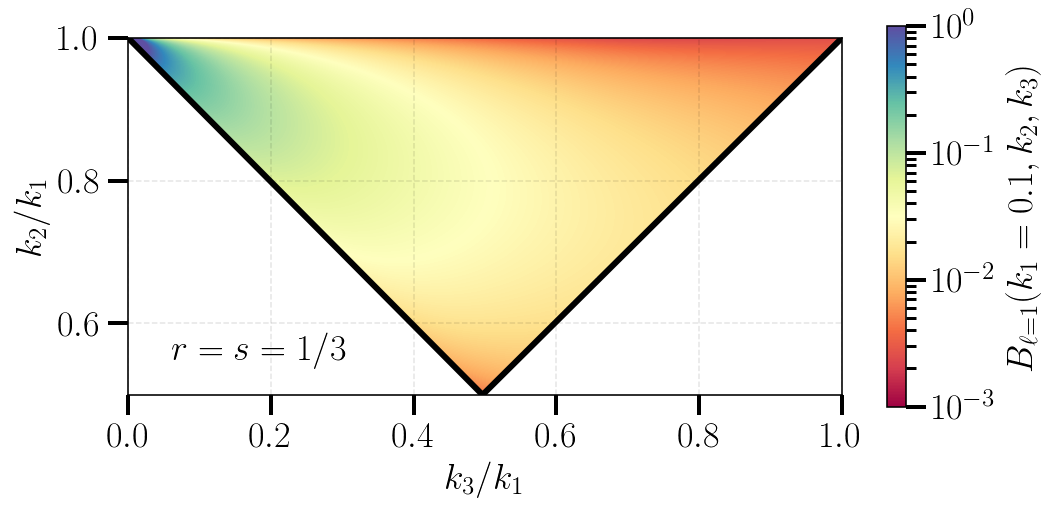

In [2291]:
#plot_triangle(bk_0['z=1.00, r=0, s=0'],1e+10,1e+8)
plot_triangle(bk_wa1['z=1.00, r=0, s=0']/bk_0['z=1.00'],1,1e-3)#d = x1
plot_triangle(bk_der1['z=1.00, r=0, s=0']/bk_0['z=1.00'],1,1e-3)

In [183]:
def plot_triangle_multi(bk0,bk1,bk2,vmax): #plot triangle with mask!   
        
    fig = plt.figure(figsize=(12, 5))

    # Define gridspec with 1 rows and 3 columns
    gs = GridSpec(1, 3, width_ratios=[3, 3, 3])

    # Create subplots with custom aspect ratios
    axs = [fig.add_subplot(gs[0, i], aspect='10') for i in range(3)]  # Subplots in the first row

    #fig, axs = plt.subplots(1, 3,figsize=(14,5),sharey=True)
    fig.subplots_adjust(wspace=0)
    # Create the colormap plot
    im0 = axs[0].imshow(np.abs((bk0).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(1e-2, vmax=vmax))#,vmin=0,vmax=vmax)#
    im1 = axs[1].imshow(np.abs((bk1).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(1e-2, vmax=vmax))#,vmin=0,vmax=vmax)#
    im2 = axs[2].imshow(np.abs((bk2).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='Spectral',norm=mpl.colors.LogNorm(1e-2, vmax=vmax))#,vmin=0,vmax=vmax)#

    #im0 = axs[0].imshow(((bk0).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im1 = axs[1].imshow(((bk1).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#
    #im2 = axs[2].imshow(((bk2).T),aspect=1.5, extent=[0, 1, 0.5, 1], interpolation='bilinear', origin='lower', cmap='RdBu',vmin=-vmax,vmax=vmax)#,vmin=0,vmax=vmax)#

    #divider = make_axes_locatable(axs[2])
    #colorbar_ax = divider.append_axes("right", size="5%", pad=0.05)
    #cbar = plt.colorbar(im2, cax=colorbar_ax)
    #
    
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.81, 0.3, 0.01, 0.4])
    cbar = fig.colorbar(im2, cax=cbar_ax,ticks=[0.01, 0.1, 1])
    #cbar.set_label(r"$ |B^{\rm wa}_{\ell=1}(k_1=0.05)|/B^{\rm pp}_{\ell=0}$")#"$ |B_{\ell=1}(k_1=0.05)|/B_0 $"
    cbar.set_label(r"$ |B^{\rm RR}_{\ell=1}(k_1=0.05)|/B^{\rm wa}_{\ell=0}$")#"$ |B_{\ell=1}(k_1=0.05)|/B_0 $"
    x_bound = [0,0.4965,1]
    y_bound = [1,0.50,1]#
    #so masking 
    # Create a mask for the triangular region
    for i in range(3):
        #axs[i].set_aspect(10)  # Adjust aspect ratio manually
        if i ==0:
            #axs[i].set_yticks(np.arange(0, 0.5, 0.1))
            axs[i].set_ylabel('$k_2/k_1$')
        #size = int(1e+3)
        #x = np.linspace(0.0, 1, size,dtype=np.float32)
        #y = np.linspace(0.5, 1,  size,dtype=np.float32)
        #xx,yy = np.meshgrid(x,y)
        #mask = np.where(np.logical_and((yy > 1 - xx), (yy>xx)),np.nan,1)
        #axs[i].imshow(mask, aspect=1.5, interpolation='bilinear', origin='lower', cmap='binary')
        axs[i].plot(x_bound,y_bound,'k',linewidth=3)
        axs[i].text(0.08,0.55,r'$\boldsymbol{d}=\boldsymbol{x}_%d$'%(i+1),fontsize=20)
        axs[i].set_xlabel('$k_3/k_1$')
        axs[i].set_xticks(np.arange(0.1, 0.91, 0.2))
        #axs[i].set_box_aspect(aspect=0.8)
        #axs[i].set_xlim(0,1)
        #axs[i].set_ylim(0.5,1)
        #axs[i].grid(ls='--',lw=0.75,color='k',alpha=0.1)
        
        if i!=0:
            axs[i].yaxis.set_major_locator(plt.NullLocator())
    
    # Show the plot
    plt.savefig('endpoint_traingles.png', bbox_inches='tight', dpi=400)
    plt.show()

<ipython-input-182-17e6a40c8381>:1: RuntimeWarning: invalid value encountered in divide
  plot_triangle_multi(bk_wa1['z=1.00, r=0, s=0']/bk_0['z=1.00'],bk_wa1['z=1.00, r=1, s=0']/bk_0['z=1.00'],bk_wa1['z=1.00, r=0, s=1']/bk_0['z=1.00'],0.25)


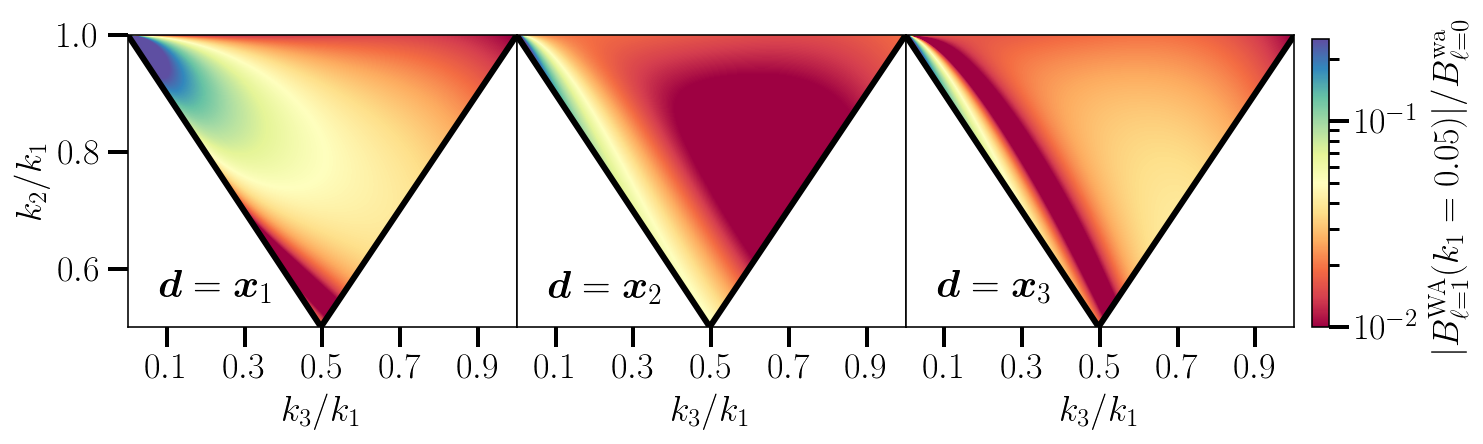

In [182]:
plot_triangle_multi(bk_wa1['z=1.00, r=0, s=0']/bk_0['z=1.00'],bk_wa1['z=1.00, r=1, s=0']/bk_0['z=1.00'],bk_wa1['z=1.00, r=0, s=1']/bk_0['z=1.00'],0.25)

<ipython-input-252-21821a36bdc0>:1: RuntimeWarning: invalid value encountered in divide
  plot_triangle_multi(bk_der1['z=1.00, r=0, s=0']/bk_0['z=1.00'],bk_der1['z=1.00, r=1, s=0']/bk_0['z=1.00'],bk_der1['z=1.00, r=0, s=1']/bk_0['z=1.00'],0.25)


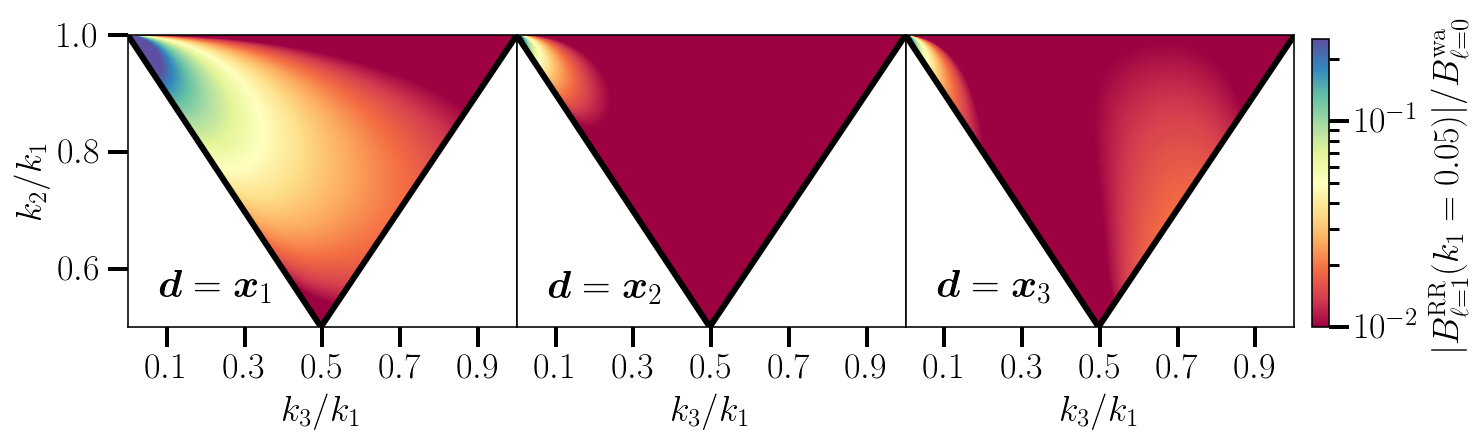

In [252]:
plot_triangle_multi(bk_der1['z=1.00, r=0, s=0']/bk_0['z=1.00'],bk_der1['z=1.00, r=1, s=0']/bk_0['z=1.00'],bk_der1['z=1.00, r=0, s=1']/bk_0['z=1.00'],0.25)

<ipython-input-2315-ba182e99cd10>:1: RuntimeWarning: invalid value encountered in divide
  plot_triangle_multi(bk_wa1['z=0.50, r=0, s=0']/bk_0['z=0.50'],bk_wa1['z=0.50, r=1, s=0']/bk_0['z=0.50'],bk_wa1['z=0.50, r=0, s=1']/bk_0['z=0.50'],0.25)


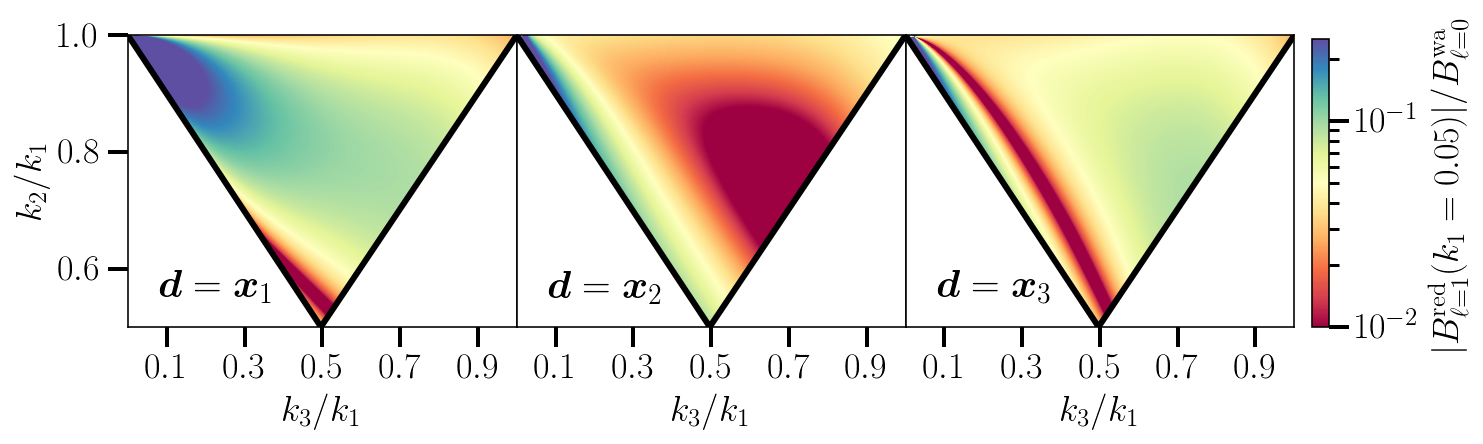

<ipython-input-2315-ba182e99cd10>:2: RuntimeWarning: invalid value encountered in divide
  plot_triangle_multi(bk_der1['z=0.50, r=0, s=0']/bk_0['z=0.50'],bk_der1['z=0.50, r=1, s=0']/bk_0['z=0.50'],bk_der1['z=0.50, r=0, s=1']/bk_0['z=0.50'],0.25)


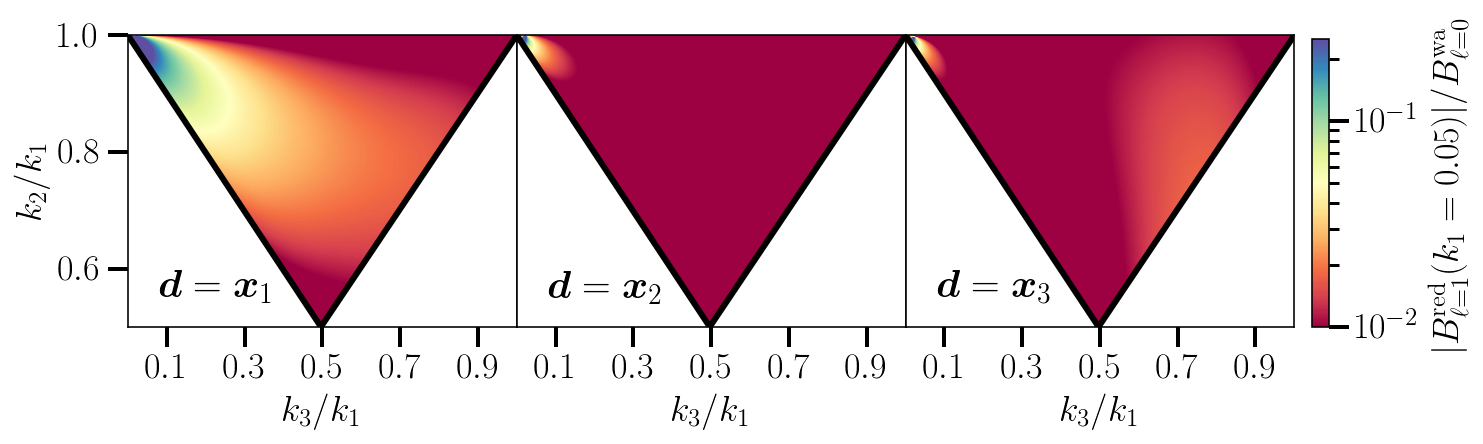

In [2315]:
plot_triangle_multi(bk_wa1['z=0.50, r=0, s=0']/bk_0['z=0.50'],bk_wa1['z=0.50, r=1, s=0']/bk_0['z=0.50'],bk_wa1['z=0.50, r=0, s=1']/bk_0['z=0.50'],0.25)
plot_triangle_multi(bk_der1['z=0.50, r=0, s=0']/bk_0['z=0.50'],bk_der1['z=0.50, r=1, s=0']/bk_0['z=0.50'],bk_der1['z=0.50, r=0, s=1']/bk_0['z=0.50'],0.25)

In [ ]:
plot_triangle_multi(bk_der2['z=0.50, r=0, s=0']/bk_0['z=0.50'],bk_der2['z=0.50, r=1, s=0']/bk_0['z=0.50'],bk_der2['z=0.50, r=0, s=1']/bk_0['z=0.50'],0.25)

In [1318]:
def add_dict(dict1,dict2,key):
    new_dict = {}
    new_dict[key] = dict1[key]+dict2[key]
    return new_dict
def minus_dict(dict1,dict2,key):
    new_dict = {}
    new_dict[key] = dict1[key]+dict2[key]
    return new_dict

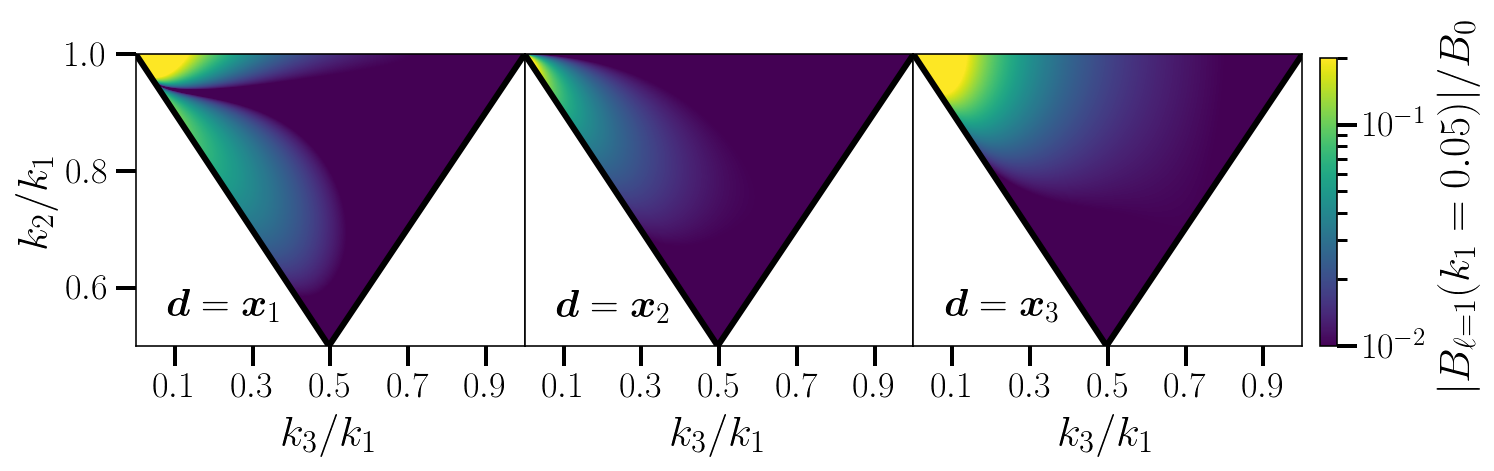

In [1332]:
plot_triangle_multi(bk1_deriv['0.1']/bk_mono['0.1'],bk2_deriv['0.1']/bk_mono['0.1'],bk3_deriv['0.1']/bk_mono['0.1'],0.2)

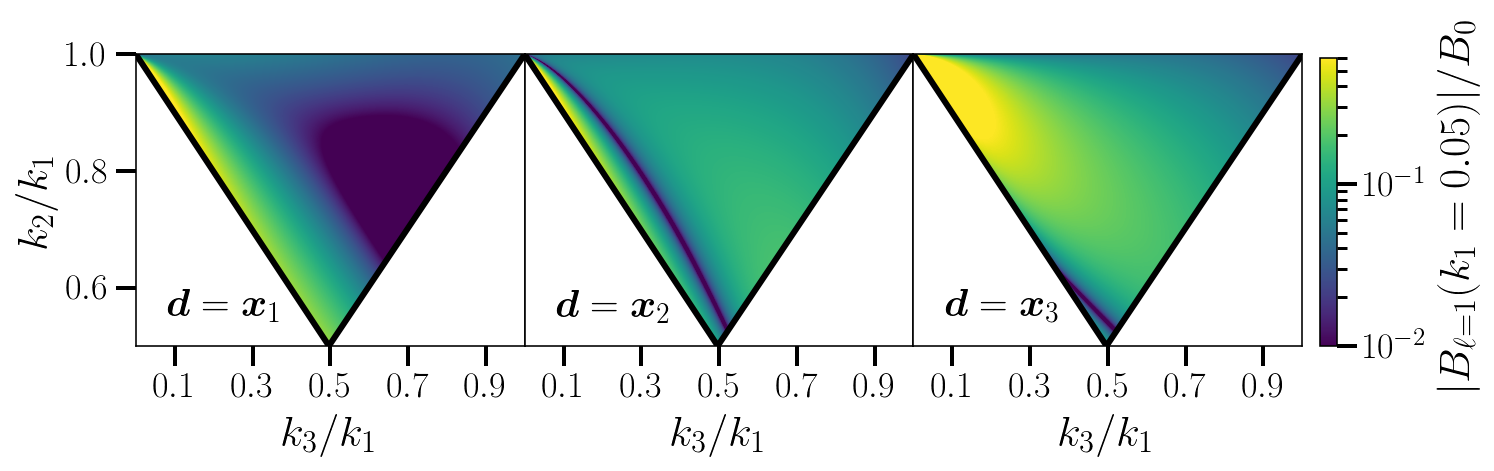

In [1304]:
plot_triangle_multi(bk1,bk2,bk3,0.6)

In [24]:
z = np.linspace(0.1,2)
b1= 0.9 + 0.4 * z
b_1 = np.sqrt(1+z)
b11 = 1.34/cosmo_functions.D_intp(z)

g2 = -(2/7)*(b1-1) #
g21 = 0.524-0.547*b1+0.046*b1**2 # excursion set pardede

b2 =0.412 - 2.143*b1 +0.929*b1**2 + 0.008*b1**3 + 4/3 * g2
b21= -0.741-0.125*z+0.123*z**2+0.00637*z**3

plt.plot(z,b_1)
plt.plot(z,b1)
plt.plot(z,b11)

plt.plot(z,g2)
plt.plot(z,g21)
plt.show()
plt.plot(z,b2)
plt.plot(z,b21)
plt.show()